In [3]:
import os, sys, importlib, pathlib
import pandas as pd
from pathlib import Path
sys.path.append (os.path.abspath(".."))
# my utils
from utils import fa
from utils import modeling
from utils import preprocess_listings

In [1]:
# 标准版存档V0：
LABELS_EN=[
            'open to different cultures', 'cosmopolitan','international view', 'cultural exchange',
            'personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life',
            'meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction',
            'thoughtful service', 'attentive to needs', 'willing to help', 'responsive',
            'fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb'
        ]
DICT_FACTOR_ITEMS={"ouverture":['open to different cultures', 'cosmopolitan','international view', 'cultural exchange'],
                   "authenticité":['personal life', 'life experiences', 'divers interests', 'hobbies', 'enjoy life'],
                   "sociabilité":['meet new people', 'welcoming', 'friendly', 'sociable', 'interpersonal interaction'],
                   "auto_promotion":['thoughtful service', 'attentive to needs', 'willing to help', 'responsive'],
                   "exemplarité":['fan of Airbnb', 'Airbnb community','love Airbnb', 'travel with Airbnb']}


## fa: all

In [4]:
# df_zsc=pd.read_csv("../data_processed\listings-paris_london-2306_2406.csv")
# print(df_zsc.shape)
path_df=r"../data_processed\listings_tactics_bio_vis-paris_london-2306_2312_2406-1.csv"
df_zsc=pd.read_csv(path_df)


C:\Users\yeliu\AppData\Local\Temp\ipykernel_30040\3911179908.py:4: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_zsc=pd.read_csv(path_df)


In [5]:
print(df_zsc.shape)
df_zsc.columns.to_list()

(266852, 129)


['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [4]:
DATA_DIR="../data_processed"
groups=[   
    'london_2306', "london_2312",'london_2406',
    'paris_2306',"paris_2312","paris_2406"
]
list_df=[]
for g in groups:
    path_df=os.path.join(DATA_DIR, g, f"listings_zsc_{g}.csv")
    print(f"{g}".center(100,'-'))
    print(path_df,os.path.exists(path_df))
    
    df=pd.read_csv(path_df)
    print(df.shape)
    time=g.split("_")[1]
    in_paris="1" if g.split('_')[0]=="paris" else 0
    df["group"]=g
    df['time']=str(time)
    df['post'] = df["time"].apply(lambda x : 1 if x=="2406" else 0)
    df['in_paris']=in_paris

    # check
    if "len" in df:
        df.rename(columns={'len':"text_length"},inplace=True)

    # double check
    df['has_text']=df['lang'].apply(lambda x : 0 if x=="no_text" else 1)
    df['lang_fr']=df['lang'].apply(lambda x : 1 if x=="fr" else 0)
    df['lang_en']=df['lang'].apply(lambda x : 1 if x=="en" else 0)       
        
    list_df.append(df)
df_all=pd.concat(list_df, axis=0)
print(df_all.shape)



--------------------------------------------london_2306---------------------------------------------
../data_processed\london_2306\listings_zsc_london_2306.csv True
(42356, 108)
--------------------------------------------london_2312---------------------------------------------
../data_processed\london_2312\listings_zsc_london_2312.csv True
(43172, 112)
--------------------------------------------london_2406---------------------------------------------
../data_processed\london_2406\listings_zsc_london_2406.csv True
(49856, 108)
---------------------------------------------paris_2306---------------------------------------------
../data_processed\paris_2306\listings_zsc_paris_2306.csv True


C:\Users\yeliu\AppData\Local\Temp\ipykernel_17384\2972875042.py:12: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df)


(32901, 108)
---------------------------------------------paris_2312---------------------------------------------
../data_processed\paris_2312\listings_zsc_paris_2312.csv True
(35829, 114)
---------------------------------------------paris_2406---------------------------------------------
../data_processed\paris_2406\listings_zsc_paris_2406.csv True
(62738, 107)
(266852, 116)


In [8]:
df_all=df_zsc.copy()
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [9]:
## time, in_paris
print(df_all[["time","in_paris"]].value_counts(dropna=False))
print(df_all.group.value_counts(dropna=False))

time  in_paris
2406  1           62738
      0           49856
2312  0           43172
2306  0           42356
2312  1           35829
2306  1           32901
Name: count, dtype: int64
group
paris_2406     62738
london_2406    49856
london_2312    43172
london_2306    42356
paris_2312     35829
paris_2306     32901
Name: count, dtype: int64


In [10]:
print(df_all[['lang',"has_text", "lang_en","lang_fr"]].value_counts(dropna=False))
print(df_all.text_length.isna().value_counts())
print(df_all.text_length.describe())

lang         has_text  lang_en  lang_fr
no_text      0         0        0          133912
en           1         1        0           96667
fr           1         0        1           33676
other_langs  1         0        0            2597
Name: count, dtype: int64
text_length
False    266852
Name: count, dtype: int64
count    266852.000000
mean         31.178567
std          58.485530
min           0.000000
25%           0.000000
50%           0.000000
75%          43.000000
max        1040.000000
Name: text_length, dtype: float64


In [ ]:
items=LABELS_EN
df_dropna=df_zsc.dropna(subset=['host_about']).drop_duplicates(subset=['host_about'])
df_dropna=df_dropna.dropna(subset=items).drop_duplicates(subset=items)
print(df_dropna.shape)

(36700, 129)


## 20260510-EN

In [18]:
import pandas as pd
import os, sys, importlib
import time
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## fa
from factor_analyzer.factor_analyzer import calculate_kmo
from factor_analyzer import FactorAnalyzer
from pingouin import cronbach_alpha
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

## my utils
from utils.io import save_csv_as_latex

def run_fa(
        # path_df_items, 
        df_zsc, items, output_folder="../output_fa",#fallback!
        output_folder_data="../data_processed",filename="listings_tactics.csv",
        # for df_scores(tactics)
        
        n_factors=5, rotation="oblimin", 
        fa_names=None,
        dict_factor_items=None,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4):
    # no suffix!
    # 英语提示，但是图片标题用法语！
    ## fa DROPNA!
    # if path_df_items :
    #     df=pd.read_csv(path_df_items)
    #     print(f"[INFO] df_items : {len(df)} rows!\n")
    
    df=df_zsc.copy()
        
    # if not df_zsc.empty:
    #     df=df_zsc.copy()
        # df=df.dropna(subset=items).drop_duplicates(subset=items)
        # print(f"[info] df_zsc: {len(df_zsc)} rows; df_items:{len(df)} rows!\n")
        
        
    #output
    os.makedirs(output_folder, exist_ok=True)
    print(f"[INFO] all output saved to '{output_folder}'!\n"
          f"df with fa scores saved to '{output_folder_data}' !\n"
          f"[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!")

    print(f"\n============================RUN FA=================================")
    #-------------------------- check data -----------------------------
    missing_labels = [col for col in items if col not in df.columns]
    if missing_labels:
        print(f"[WARNING] These items are missing in df: {missing_labels}\n")

    else :        
        # df_dropna=df.dropna(subset=items).drop_duplicates(subset=items)
        df_dropna=df_zsc.dropna(subset=['host_about']).drop_duplicates(subset=['host_about'])
        df_dropna=df_dropna.dropna(subset=items).drop_duplicates(subset=items)

        # df[df[items].sum(axis=1)!=0]
        data=df_dropna[items]
        print(f"[info] df_zsc: {len(df_zsc)} rows; df_items:{len(df_dropna)} rows!\n")

        # print(f"[INFO] len scores in df notna:{len(data)}\n")
    
    # ---------------------------kmo-----------------------------------
    kmo_all, kmo_model = calculate_kmo(data)
    print(f"[INFO] kmo_model score (> 0.7) :{kmo_model}\n")


    # ---------------------------fa fit -------------------------------
    if rotation =="oblimin":
        print(f"[INFO] oblimin allows cross-loadings!\n")        
    fa = FactorAnalyzer(n_factors=n_factors, rotation=rotation, method='minres')
    fa.fit(data)
    ### output impo :fa, data


    print("---------------------------heatmap of items-------------------------------")
    if get_items_heatmap==True: 
        loadings = fa.loadings_
        print(f"[INFO] good loadings > 0.5")
        
        if fa_names :
            print(f"Rename loadings df with fa_names in proper order !")
            loadings_df=pd.DataFrame(loadings, index=data.columns, columns=fa_names)
        else :
            loadings_df=pd.DataFrame(loadings, index=data.columns)  
    
        plt.figure(figsize=(10,8))
        sns.heatmap(loadings_df, annot=True, cmap='coolwarm')
        plt.title('Factor Loadings of Items')
        # plt.xticks(rotation=45)
        plt.tight_layout()
        outpath_heatmap=os.path.join(output_folder, 'heatmap_fa_items.jpeg')
        plt.savefig(outpath_heatmap, dpi=300)
        plt.show()
        print(f"✅ [SAVE] heatmap of items saved to {outpath_heatmap}!\n")
    
    
    
    print(f'organise input FA_ITEMS_DICT as latex table'.center(100, '-'))
    if dict_factor_items:# dict to csv
        fa_items_str_dict = {
            k: ", ".join(v)
            for k, v in dict_factor_items.items()
        }

        fa_items_df=pd.DataFrame.from_dict(fa_items_str_dict, orient='index',columns=['items'])
        fa_items_df.reset_index(names='Tactique', inplace=True)
        display(fa_items_df)
               
        outpath_fa_items=os.path.join(output_folder, "latex","fa_items_table.tex")
        save_csv_as_latex(table_csv=fa_items_df, 
                          output_path=outpath_fa_items, 
                          caption="Bilan des items des tactiques de la présentation de soi", 
                          label="tab:fa_items_table", 
                          ndigits= ndigits,escape=True, index=False)
        
    
    if get_items_table==True:#***
        print("# ------------------------------------tab items fa------------------------------------")
        loadings = fa.loadings_
        communalities = fa.get_communalities()
        uniqueness = fa.get_uniquenesses()
        def item_complexity(loadings):
            """
            loadings: (n_items × n_factors)
            """
            p = loadings**2
            p = p / np.sum(p, axis=1, keepdims=True)
            complexity = 1 / np.sum(p**2, axis=1)
            return complexity

        complexities = item_complexity(loadings)

        # gamma 和 sigma
        abs_loadings = np.abs(loadings)
        gamma = abs_loadings.max(axis=1)                   # 最大因子载荷 !
        sigma = np.sort(abs_loadings, axis=1)[:, -2]       # 第二大因子载荷!

        # get DataFrame
        desired_order = None  # 先定义，保证一定存在
        if fa_names:
            fa_names_in_tab=fa_names
            ##如有fa输入按照这个整理!
            # desired_order=['gamma','sigma','ouverture','authenticité','sociabilité',"auto_promotion","exemplarité",'communalité','spécificité']
            # desired_order=['ouverture','authenticité','sociabilité',"auto_promotion","exemplarité",'communalité','spécificité']
            desired_order=['openness', "authenticity",'sociability',"self-promotion",'exemplification',"communality","uniqueness","complexity"]
        else :
            #没有fa_names，则无法按照上面的顺序整理！
            fa_names_in_tab=[f"Factor{i+1}" for i in range(0, loadings.shape[1])]
            
        columns = ['gamma', 'sigma'] + \
                fa_names_in_tab + \
                ["communality","uniqueness","complexity"]

        df_fa = pd.DataFrame(
            np.column_stack([gamma, sigma, loadings, communalities, uniqueness, complexities]),
            index=data.columns,
            columns=columns
        )
        df_fa.round(ndigits)
        
        # reorder 
        # desired_order=['gamma','sigma','ouverture','authenticité','sociabilité',"auto_promotion","exemplarité",'communalité','spécificité']
        if desired_order:
            df_fa=df_fa[desired_order]
        
        if dict_factor_items and fa_names:
            df_fa_num = df_fa.copy()# round的是时候不能有'-'
            factor_cols = fa_names #选取因子列
            
            # 先把所有因子列设为 "-"
            df_fa.loc[:, factor_cols] = '-'

            # 再逐个因子填回“所属 item”的 loading
            for factor, items in dict_factor_items.items():
                for item in items:
                    if item in df_fa.index and factor in df_fa.columns:
                        df_fa.loc[item, factor] = round(
                            float(df_fa_num.loc[item, factor]), ndigits
                        )
                        df_fa.loc[item]
        display(df_fa)
    
            
        #info
        print(f"[INFO] mean COMM (> 0.6):{communalities.mean()}\n"
                    f"[INFO] mean UNIQ : {uniqueness.mean()}\n")
        low_comm_t=0.5
        low_comm_items = df_fa[df_fa['communality'] <low_comm_t ]
        print(f"[WARNING] {len(low_comm_items)}/{len(df_fa)} low communality items (< {low_comm_t}):\n{';'.join(low_comm_items.index)}\n")

        # save as csv
        outpath_items_fa_csv=os.path.join(output_folder, 'items_fa_en.csv')
        df_fa.to_csv(outpath_items_fa_csv, index=True)##index!!!
        print(f"✅ [SAVE] items fa CSV saved to {outpath_items_fa_csv}!\n")
        
        # save as latex               
        outpath_items_fa_latex=os.path.join(output_folder, 'latex','items_fa_en.tex')        
        save_csv_as_latex(table_csv=df_fa, output_path=outpath_items_fa_latex, 
                          caption="Tableau de l'analyse factorielle des items", 
                          label="tab:items_fa", 
                          ndigits=ndigits,
                          escape=True,
                          index=True)
        
        ## ps.
        print(f"[CHECK] remember to RENAME factors by heatmap of zsc data!!!")            
    

    print("get fa scores(tactics)".center(100,"="))
    # 从原始 df 中筛选非空行 (df_dropna) 做 FA
    # 得到 FA scores (df_scores) (无id索引)！
    # 拼接回 df_dropna → 得到 df_tactics
    # 按 "host_about" 去重 → df_bio_tactics
    # 最后再 merge 回原始 df → listings_tactics
    
    # init，空的df不会拼接上
    df_scores_mean=pd.DataFrame()
    df_scores_weighted=pd.DataFrame()
    
    # desired_order_tactics=['ouverture','authenticité','sociabilité',"auto_promotion","exemplarité"]   
    desired_order_tactics=['openness', "authenticity",'sociability',"self-promotion",'exemplification']


    # reorder for heatmap!
    
    if get_factor_scores_by  in ["mean","both"]:
        print(f"[INFO] calulate factor score by taking the average of its corresponding items, ref to a pre-defined map.\n")
        
        # fa_items_dict={
        #     "ouverture":['open to different cultures','cosmopolitan','international view','cultural exchange'],
        #     "authenticité":['personal life','life experiences','divers interests','hobbies','enjoy life'],
        #     'sociabilité':['meet new people', 'welcoming', 'friendly','sociable', 'interpersonal interaction'],
        #     'auto_promotion':['thoughtful service', 'attentive to needs','willing to help','responsive'],
        #     'exemplarité':["fan of Airbnb","Airbnb community",'love Airbnb', 'travel with Airbnb']
        # }
        
        if dict_factor_items:            
            fa_scores_mean = pd.DataFrame(index=data.index)
            for f, items in dict_factor_items.items():
                fa_scores_mean[f] = data[items].mean(axis=1)
            df_scores_mean=pd.DataFrame(fa_scores_mean).reset_index(drop=True)
            
            mean_order=[tac for tac in desired_order_tactics]
            print(f"MEAN ORDER:{mean_order}")
            df_scores_mean=df_scores_mean[mean_order]
        else : 
            print(f"[CHECK] need FA_ITEMS_DICT!!")
            

    if get_factor_scores_by in ["weighted","both"]:
        fa_scores_weighted = fa.transform(data)#用和items fa相同的fa transforme data就可以得到加权weighted!的scores==tactics!
        df_scores_weighted=pd.DataFrame(fa_scores_weighted).reset_index(drop=True)
       
        if fa_names:
            df_scores_weighted.columns=[col for col in fa_names]
            #reorder:
            weighted_order=[tac for tac in desired_order_tactics]
            print(f"WEIGHTED ORDER:{weighted_order}")
            df_scores_weighted=df_scores_weighted[weighted_order]


    if get_factor_scores_by not in ['mean','weighted', 'both']:
        print(f"[WARNING] choose from 'mean' or 'weighted' or 'both'!!")
    
    
    # include mean AND/OR weighted 
    df_scores=pd.concat([df_scores_mean, df_scores_weighted],axis=1)       
    print(f'[INFO] shape df scores = 5*len(get_factor_scores_by):{df_scores.shape}')
    

    print("---------------------------------run fa on scores(must do)--------------------------------------")
    
    # plot
    def run_scores_fa(df_scores, run_fa_on_scores, get_scores_heatmap=get_scores_heatmap, 
                    output_folder=output_folder):
        title_map={'mean':'moyens',
                   'weighted':'pondérés'}
        
        # init fa & fit 
        fa_scores = FactorAnalyzer(n_factors=2, rotation=rotation, method='minres') 
        fa_scores.fit(df_scores)
        
        # data
        loadings_scores = fa_scores.loadings_
        loadings_scores_df=pd.DataFrame(loadings_scores, index=df_scores.columns)
        loadings_scores_df.columns=["Dimension 1","Dimension 2"]
        display(loadings_scores_df)
        # save as csv
        
        outpath_scores_df=os.path.join(output_folder, 'scores_fa_en.csv')
        loadings_scores_df.to_csv(outpath_scores_df, index=True)
        print(f"✅[SAVE] scores df saved to {outpath_scores_df}!")
        
        
        # save as latex
        outpath_scores_fa_latex=os.path.join(output_folder, "latex",f"scores_{run_fa_on_scores}_fa.tex")        
        save_csv_as_latex(table_csv=loadings_scores_df, output_path=outpath_scores_fa_latex,
                          caption="Tableau de l'analyse factorielle des tactiques",
                          label="tab: tactics_fa",
                          ndigits=ndigits, escape=True, index=True)       
        # plot
        if get_scores_heatmap:      
            sns.heatmap(loadings_scores_df, annot=True, cmap='coolwarm')
            
            plt.title(f'Charge factorielles des tactiques (scores {title_map.get(run_fa_on_scores,None)})')
            plt.tight_layout()
            
            outpath_scores_heatmap=os.path.join(output_folder,f'heatmap_fa_scores_{run_fa_on_scores}.jpg')
            plt.savefig(outpath_scores_heatmap,dpi=300)
            
            plt.show()
            print(f"✅ [SAVE] heatmap of {title_map.get(run_fa_on_scores,None)} scores saved to {outpath_scores_heatmap}!\n")
        
        return
    
    if run_fa_on_scores in ['mean', "both"] and not df_scores_mean.empty:   
        run_scores_fa(df_scores=df_scores_mean, run_fa_on_scores='mean', output_folder=output_folder)
    
    if run_fa_on_scores in ['weighted', "both"] and not df_scores_weighted.empty:
        run_scores_fa(df_scores=df_scores_weighted, run_fa_on_scores="weighted", output_folder=output_folder)
    
    if run_fa_on_scores not in ["mean",'weighted', "both"] :
        print(f"[INFO] choisir between 'mean','weighted','both' to run fa on tactics' scores!\n")




    print("----------------------------merge data to listings(keeping nan)---------------------------------")
    df_dropna = df_dropna.reset_index(drop=True)
    df_scores=df_scores.reset_index(drop=True)
    df_tactics=pd.concat([df_dropna, df_scores], axis=1)# horizontal
    
    df_bio_tactics=df_tactics.drop_duplicates(subset="host_about")
    
    cols_tosave=["host_about"]+df_scores.columns.tolist()
    df_bio_tactics=df_bio_tactics[cols_tosave]
    
    
    listings_tactics=df.merge(df_bio_tactics, left_on='host_about', right_on='host_about', how="left")
    
    #数据放在和OUTPUT_FOLDER同级文件夹: data_processed
        
    os.makedirs(output_folder_data, exist_ok=True)

    # filename=os.path.basename(path_df_items).replace("_items", "_scores")

    outpath_listings_tactics=os.path.join(output_folder_data,filename)
    
    listings_tactics.to_csv(outpath_listings_tactics, index=False)
    display(listings_tactics.head())
    
    print(f"[INFO] scores shape (len(data), 1/2*n_factors) :{df_scores.shape}\n"
            f"len(df_dropna) should == len(df_scores)==len(df_tactics): {len(df_dropna)}, {len(df_scores)}, {len(df_tactics)}\n"
            f"len(DF)==len(listings_tactics):{len(df)},{len(listings_tactics)}\n")
    print(f"✅ [SAVE] {len(listings_tactics)} listings with tactics scores by '{get_factor_scores_by}' way saved to {outpath_listings_tactics}!!\n")
            

    # print("----------------------------merge tactics to df with nan and duplicates---------------------------------")
    # listings_tactics


    
    print("###====================================CHECK=======================================###")   

    if get_cronbachs_a==True and dict_factor_items:
        print("---------------------------cronbach's alpha-------------------------------")
        print(f"[INFO] good alpha > 0.7\n")
        print(f"Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !\n")
        
        # predifine mapping dict
        # items2tac={
        #     "openness":['open to different cultures','cosmopolitan','international view','cultural exchange'],
        #     "authenticity":['personal life','life experiences','divers interests','hobbies','enjoy life'],
        #     'sociability':['meet new people', 'welcoming', 'friendly','sociable', 'interpersonal interaction'],
        #     'self_promotion':['thoughtful service', 'attentive to needs','willing to help','responsive'],
        #     'exemplification':["fan of Airbnb","Airbnb community",'love Airbnb', 'travel with Airbnb']
        # }
        
        dict_alpha={}
        for tactic, items in dict_factor_items.items():
            alpha, _ = cronbach_alpha(data[items])
            # print(f"- {tactic}: {alpha}")          
            dict_alpha[tactic]=alpha
        dict_alpha_df = pd.Series(dict_alpha, name='cronbach_alpha').reset_index()
        dict_alpha_df.columns = ['tactique', 'cronbach_alpha']
        display(dict_alpha_df)
        
        outpath_alpha=os.path.join(output_folder, "cronbachs_alpha.csv")
        dict_alpha_df.to_csv(outpath_alpha, index=False)
        print(f"✅ [SAVE] cronbach's alpha on items saved to {outpath_alpha}!\n")
    
    elif get_cronbachs_a and not dict_factor_items:
        print(f"[CHECK] get cronbach's alpha need dict_factor_items!!")   

        
        
    if get_barplot==True:        
        print(f"\n-----------------------------barplot comm&uniq-------------------------------")
        communalities = fa.get_communalities()
        uniqueness = fa.get_uniquenesses()
        print(f"[info] good communality (h²) : > 0.3; specificity=1-communality")
        print(f"[INFO] mean COMM (> 0.6):{communalities.mean()}\n"
            f"[INFO] mean UNIQ : {uniqueness.mean()}\n")
        
        print(f"[info] good item:gamma > 0.5 + sigma < 0.3")
        
        comm_df = pd.DataFrame({
            'Communalities': communalities,
            'Uniquenesses': uniqueness
        }, index=data.columns)
        comm_df = comm_df.sort_values("Communalité")

        plt.figure(figsize=(10,6))
        colors = sns.color_palette("tab20", n_colors=2)  # "viridis", 两个指标

        comm_df.plot(kind='bar', stacked=False, color=colors)# edgecolor='black'
        plt.title("Communalités et spécificités des items", fontsize=14)
        plt.ylabel("Proportion de la variance expliquée")
        plt.xlabel("Items")

        plt.xticks(rotation=45, ha='right')
        # plt.axhline(y=0.5, linestyle='--',color="red")
        

        plt.legend(title='Metric')
        plt.tight_layout()
        outpath_barplot=os.path.join(output_folder,"comm_uniq_barplot.jpg")
        plt.savefig(outpath_barplot, dpi=300)
        plt.show()
        print(f"✅ [SAVE] barplot saved to {outpath_barplot}!\n")

    
    if get_pca3d==True:
        print("# -----------------------------3D PCA-------------------------------")
        pca_3d=PCA(n_components=3)
        loadings_3d=pca_3d.fit_transform(loadings)
        fig = plt.figure(figsize=(15,15))
        ax = fig.add_subplot(111, projection='3d')
        
        # 缩放向量
        norms = np.linalg.norm(loadings_3d, axis=1)
        loadings_3d_scaled = loadings_3d / norms[:, np.newaxis] #0.8
        print("[INFO] Explained variance ratios 3D (>0.6):", pca_3d.explained_variance_ratio_.sum())

        # 画箭头
        for i, var in enumerate(data.columns):
            ax.quiver(0, 0, 0,
                    loadings_3d_scaled[i, 0],
                    loadings_3d_scaled[i, 1],
                    loadings_3d_scaled[i, 2],
                    color='red', arrow_length_ratio=0.1)

            ax.text(loadings_3d_scaled[i, 0]*1.1,
                    loadings_3d_scaled[i, 1]*1.1,
                    loadings_3d_scaled[i, 2]*1.1,
                    var, fontsize=10)

        # 坐标轴限制
        ax.set_xlim(-1, 1)
        ax.set_ylim(-1, 1)
        ax.set_zlim(-1, 1)
        ax.set_xlabel('PC1')
        ax.set_ylabel('PC2')
        ax.set_zlabel('PC3')

        plt.title('3D PCA Correlation Circle (Scaled)')
        plt.tight_layout()
        outpath_pca=os.path.join(output_folder, 'pca_3d.jpg')
        plt.savefig(outpath_pca,dpi=300)
        plt.show()
        print(f"✅ [SAVE] PCA 3D saved to {outpath_pca}!\n")
    
        
    return listings_tactics

[INFO] all output saved to '..\output_fa_all_20260510_en'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:36700 rows!

[INFO] kmo_model score (> 0.7) :0.8759562519516204

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


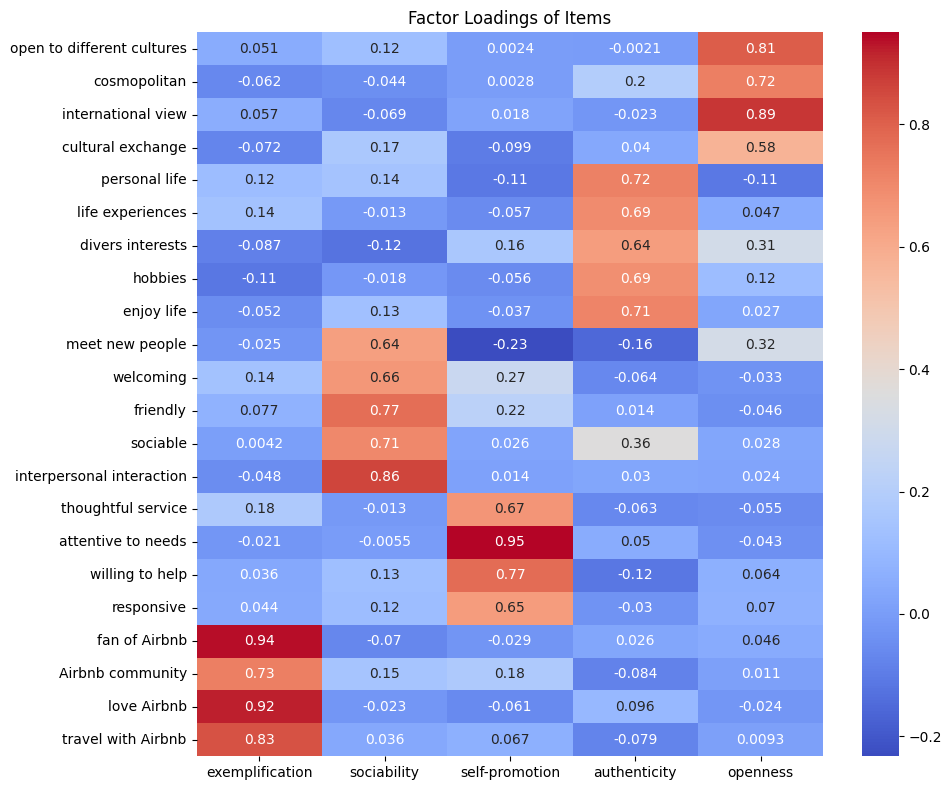

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260510_en\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260510_en\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
C:\Users\yeliu\AppData\Local\Temp\ipykernel_30040\2861216926.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
C:\Users\yeliu\AppData\Local\Temp\ipykernel_30040\2861216926.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
C:\Users\yeliu\AppData\Local\Temp\ipykernel_30040\2861216926.py:183: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype inco

,openness,authenticity,sociability,self-promotion,exemplification,communality,uniqueness,complexity
open to different cultures,-,-,-,-,-,0.672819,0.327181,1.055448
cosmopolitan,-,-,-,-,-,0.569474,0.430526,1.168729
international view,-,-,-,-,-,0.799620,0.200380,1.022465
cultural exchange,-,-,-,-,-,0.374518,0.625482,1.272626
personal life,-,-,-,-,-,0.579565,0.420435,1.231071
life experiences,-,-,-,-,-,0.506664,0.493336,1.106622
divers interests,-,-,-,-,-,0.561562,0.438438,1.729143
hobbies,-,-,-,-,-,0.500349,0.499651,1.131919
enjoy life,-,-,-,-,-,0.532629,0.467371,1.086324
meet new people,-,-,-,-,-,0.584983,0.415017,1.916098


[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all_20260510_en\items_fa_en.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260510_en\latex\items_fa_en.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['openness', 'authenticity', 'sociability', 'self-promotion', 'exemplification']
[INFO] shape df scores = 5*len(get_factor_scores_by):(36700, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
openness,-0.059958,0.727570
authenticity,-0.130081,0.570689
sociability,0.490203,0.448626
self-promotion,0.993586,-0.055894
exemplification,0.514652,0.001579


✅[SAVE] scores df saved to ..\output_fa_all_20260510_en\scores_fa_en.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260510_en\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


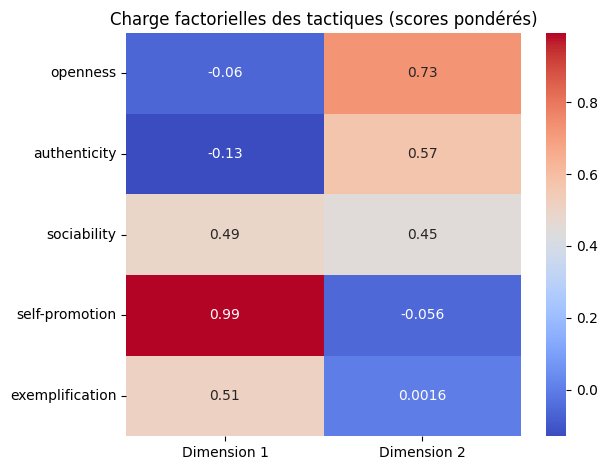

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all_20260510_en\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_picture_type,is_portrait,is_lifestyle,no_person,is_new_host,openness,authenticity,sociability,self-promotion,exemplification
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,life_style,0,1,0,0,0.170693,-0.666779,0.999759,1.346659,0.183619
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,pro_style,1,0,0,0,0.954586,0.425442,-1.290718,-0.949909,-0.727067
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,life_style,0,1,0,0,1.038566,1.205873,-0.656903,-0.552615,1.321069
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,pro_style,1,0,0,0,-0.096404,1.375039,-0.243634,-0.924116,-0.637411
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,pro_style,1,0,0,0,0.172977,-0.604943,0.912437,1.716898,0.619460


[INFO] scores shape (len(data), 1/2*n_factors) :(36700, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 36700, 36700, 36700
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406_mean.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.857254
1,authenticité,0.848983
2,sociabilité,0.874202
3,auto_promotion,0.878216
4,exemplarité,0.923024


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260510_en\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[info] good item:gamma > 0.5 + sigma < 0.3


KeyError: 'Communalité'

In [19]:

OUTPUT_FOLDER=Path("../output_fa_all_20260510_en")
OUTPUT_FOLDER_DATA=Path("../data_processed")

df=df_zsc.drop(columns=['ouverture','authenticité','sociabilité','auto_promotion','exemplarité'])

listings_tactics=run_fa(df_zsc=df, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406_mean.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplification","sociability","self-promotion","authenticity","openness"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## 20260510

[INFO] all output saved to '..\output_fa_all_20260510'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:36700 rows!

[INFO] kmo_model score (> 0.7) :0.8759562519516204

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


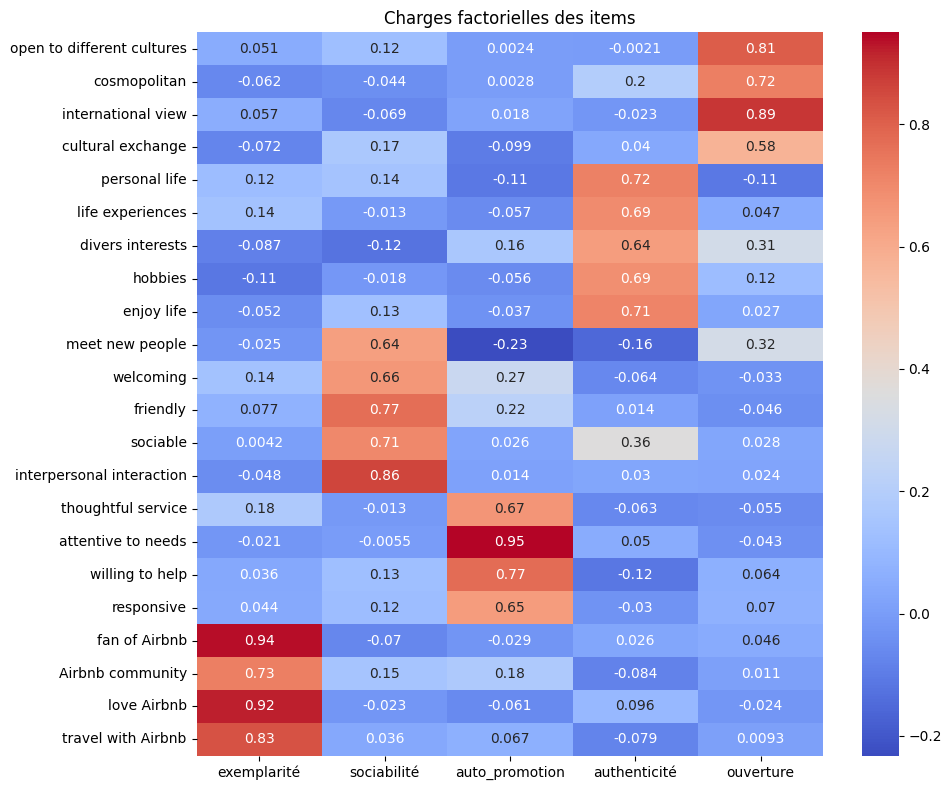

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260510\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260510\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:186: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:186: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:186: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,unicité,complexité
open to different cultures,0.8091,-,-,-,-,0.672819,0.327181,1.055448
cosmopolitan,0.7248,-,-,-,-,0.569474,0.430526,1.168729
international view,0.8893,-,-,-,-,0.799620,0.200380,1.022465
cultural exchange,0.575,-,-,-,-,0.374518,0.625482,1.272626
personal life,-,0.7221,-,-,-,0.579565,0.420435,1.231071
life experiences,-,0.6937,-,-,-,0.506664,0.493336,1.106622
divers interests,-,0.6439,-,-,-,0.561562,0.438438,1.729143
hobbies,-,0.6855,-,-,-,0.500349,0.499651,1.131919
enjoy life,-,0.7147,-,-,-,0.532629,0.467371,1.086324
meet new people,-,-,0.6375,-,-,0.584983,0.415017,1.916098


...

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_picture_type,is_portrait,is_lifestyle,no_person,is_new_host,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,life_style,0,1,0,0,0.576422,0.344197,0.917259,0.878749,0.312029
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,pro_style,1,0,0,0,0.743883,0.629986,0.214340,0.176119,0.001333
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,life_style,0,1,0,0,0.869468,0.920503,0.392340,0.334614,0.587533
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,pro_style,1,0,0,0,0.457183,0.933508,0.487034,0.188880,0.009070
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,pro_style,1,0,0,0,0.580777,0.283743,0.805511,0.919985,0.446615


[INFO] scores shape (len(data), 1/2*n_factors) :(36700, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 36700, 36700, 36700
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'mean' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406_mean.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.857254
1,authenticité,0.848983
2,sociabilité,0.874202
3,auto_promotion,0.878216
4,exemplarité,0.923024


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260510\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

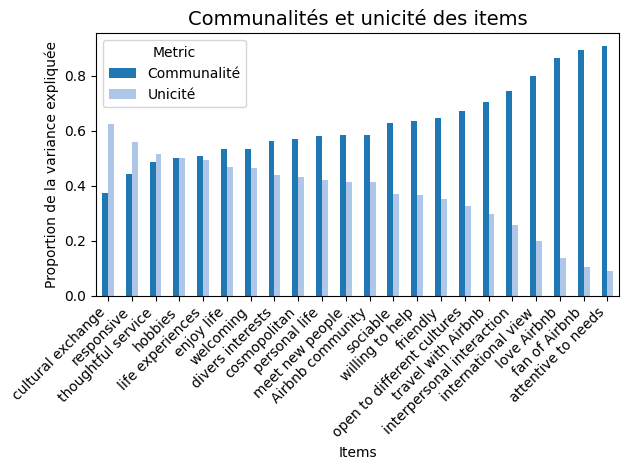

✅ [SAVE] barplot saved to ..\output_fa_all_20260510\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7825925470844366


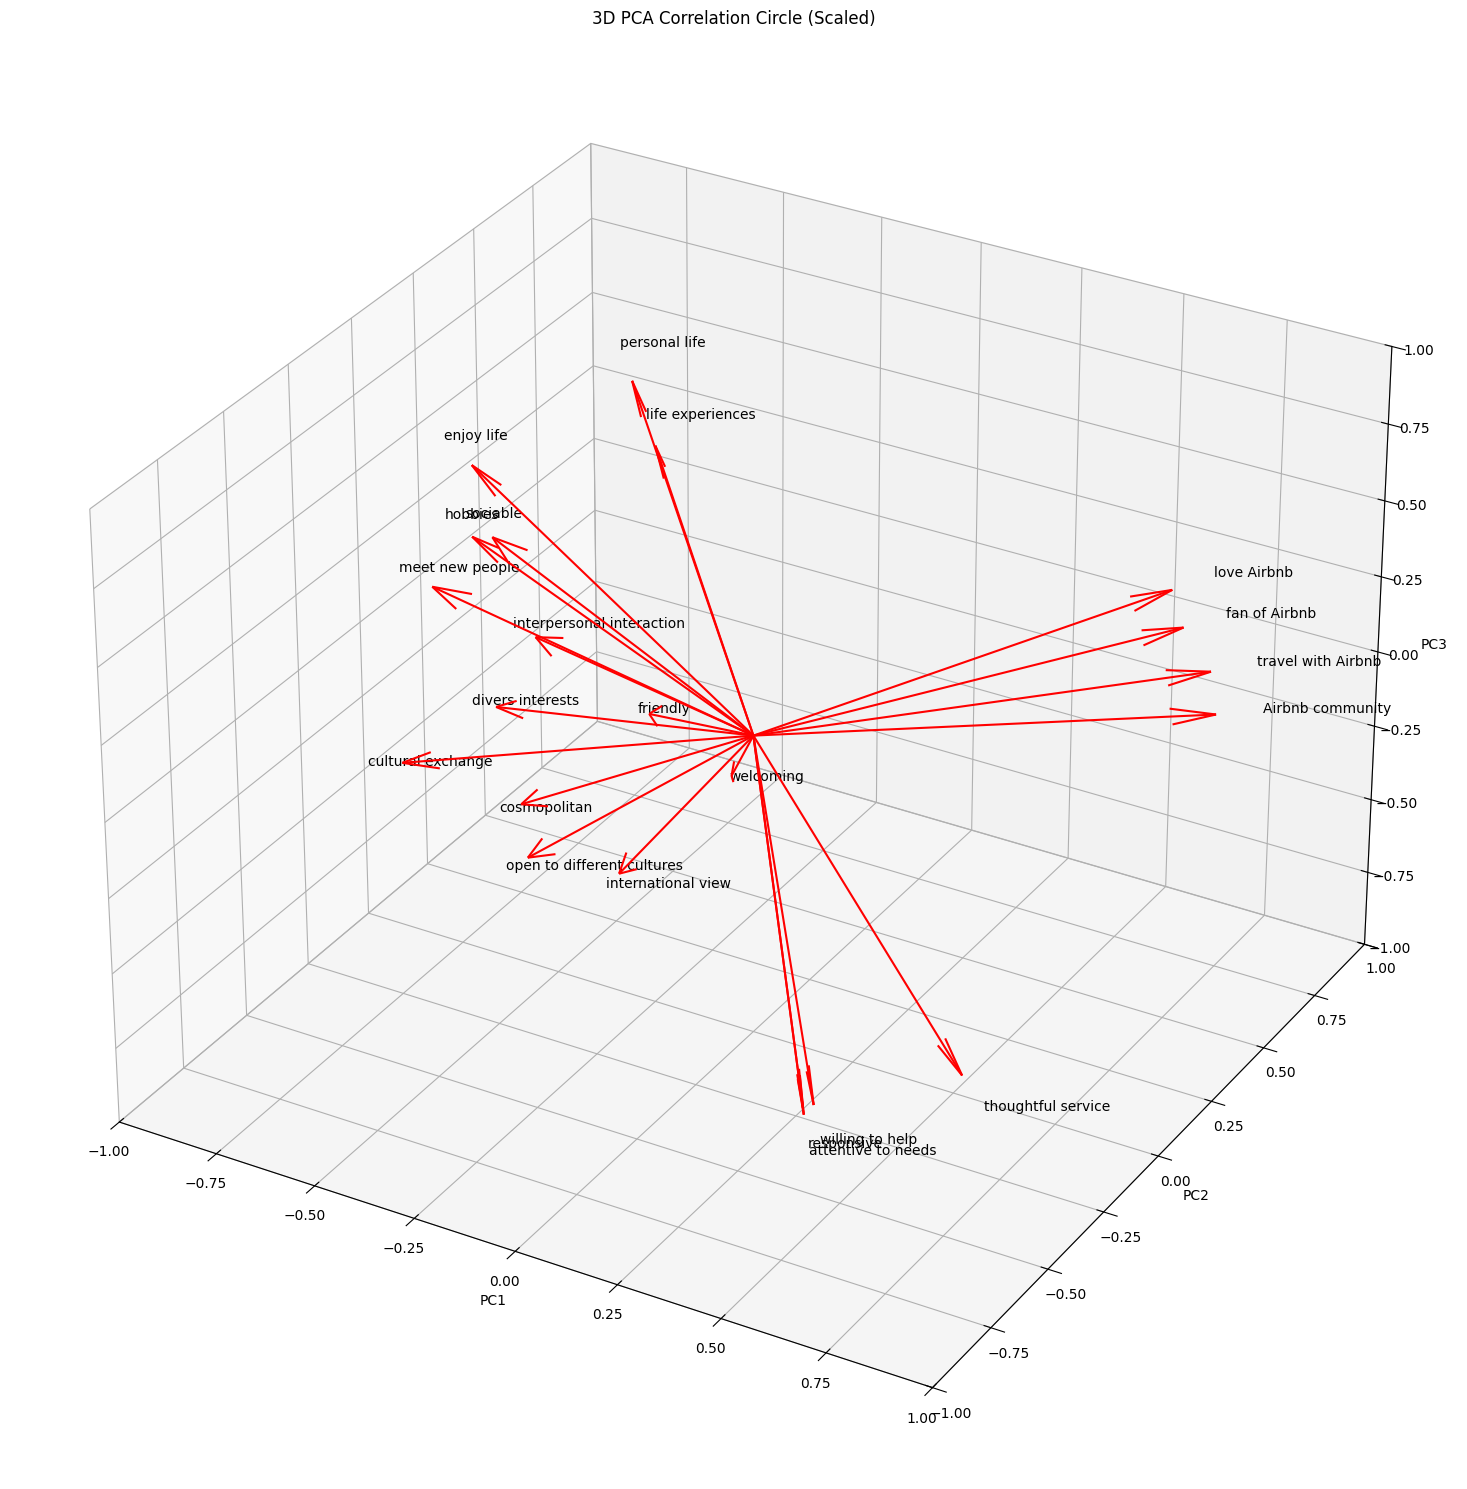

✅ [SAVE] PCA 3D saved to ..\output_fa_all_20260510\pca_3d.jpg!



In [13]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_20260510")
OUTPUT_FOLDER_DATA=Path("../data_processed")

df=df_zsc.drop(columns=['ouverture','authenticité','sociabilité','auto_promotion','exemplarité'])
listings_tactics=run_fa(df_zsc=df, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406_mean.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","auto_promotion","authenticité","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='mean',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## 20260505


In [16]:
df=df_zsc.drop(columns=['ouverture','authenticité','sociabilité','auto_promotion','exemplarité'])
df.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

[INFO] all output saved to '..\output_fa_all_20260505'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:36700 rows!

[INFO] kmo_model score (> 0.7) :0.8759562519516204

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


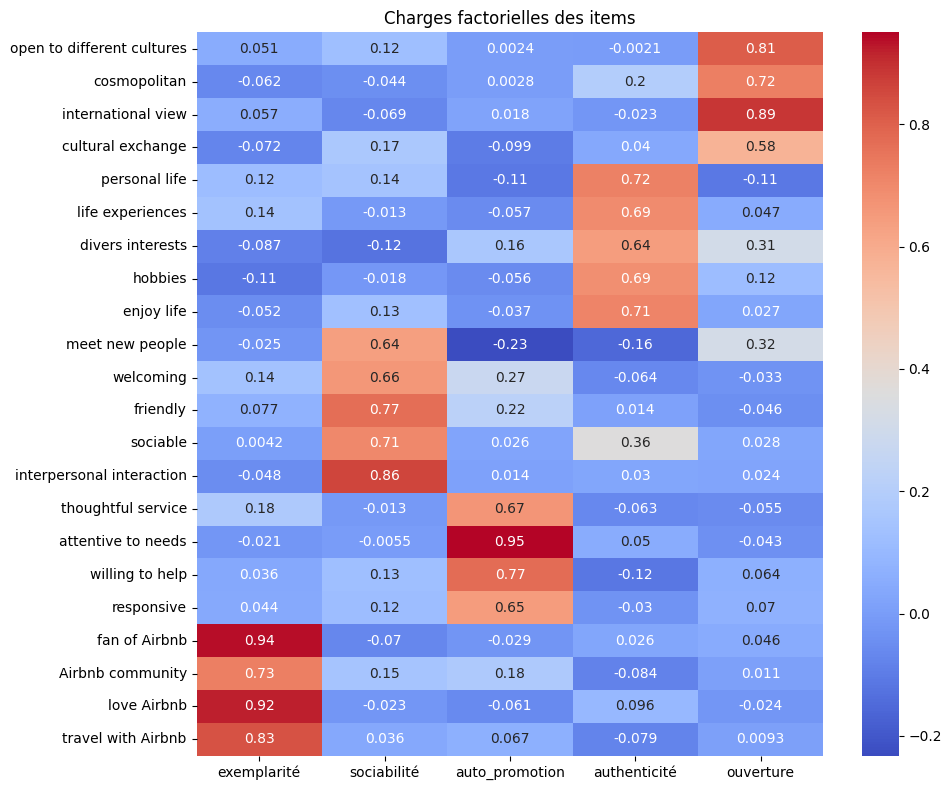

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260505\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260505\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.8091,-,-,-,-,0.672819,0.327181
cosmopolitan,0.7248,-,-,-,-,0.569474,0.430526
international view,0.8893,-,-,-,-,0.799620,0.200380
cultural exchange,0.575,-,-,-,-,0.374518,0.625482
personal life,-,0.7221,-,-,-,0.579565,0.420435
life experiences,-,0.6937,-,-,-,0.506664,0.493336
divers interests,-,0.6439,-,-,-,0.561562,0.438438
hobbies,-,0.6855,-,-,-,0.500349,0.499651
enjoy life,-,0.7147,-,-,-,0.532629,0.467371
meet new people,-,-,0.6375,-,-,0.584983,0.415017


...

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,host_picture_type,is_portrait,is_lifestyle,no_person,is_new_host,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,life_style,0,1,0,0,0.576422,0.344197,0.917259,0.878749,0.312029
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,pro_style,1,0,0,0,0.743883,0.629986,0.214340,0.176119,0.001333
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,life_style,0,1,0,0,0.869468,0.920503,0.392340,0.334614,0.587533
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,pro_style,1,0,0,0,0.457183,0.933508,0.487034,0.188880,0.009070
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,pro_style,1,0,0,0,0.580777,0.283743,0.805511,0.919985,0.446615


[INFO] scores shape (len(data), 1/2*n_factors) :(36700, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 36700, 36700, 36700
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'mean' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406_mean.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.857254
1,authenticité,0.848983
2,sociabilité,0.874202
3,auto_promotion,0.878216
4,exemplarité,0.923024


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260505\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

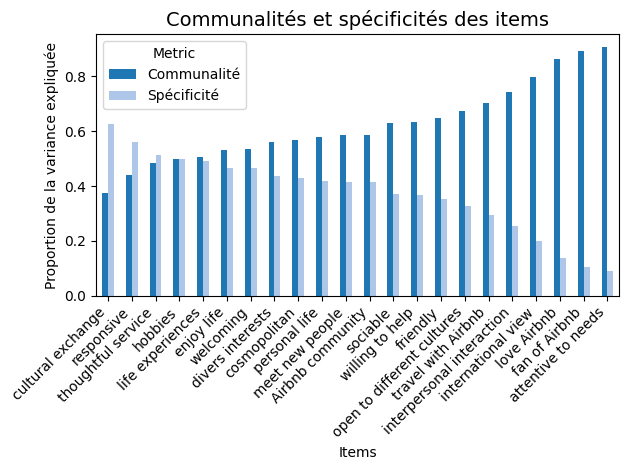

✅ [SAVE] barplot saved to ..\output_fa_all_20260505\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7825925470844366


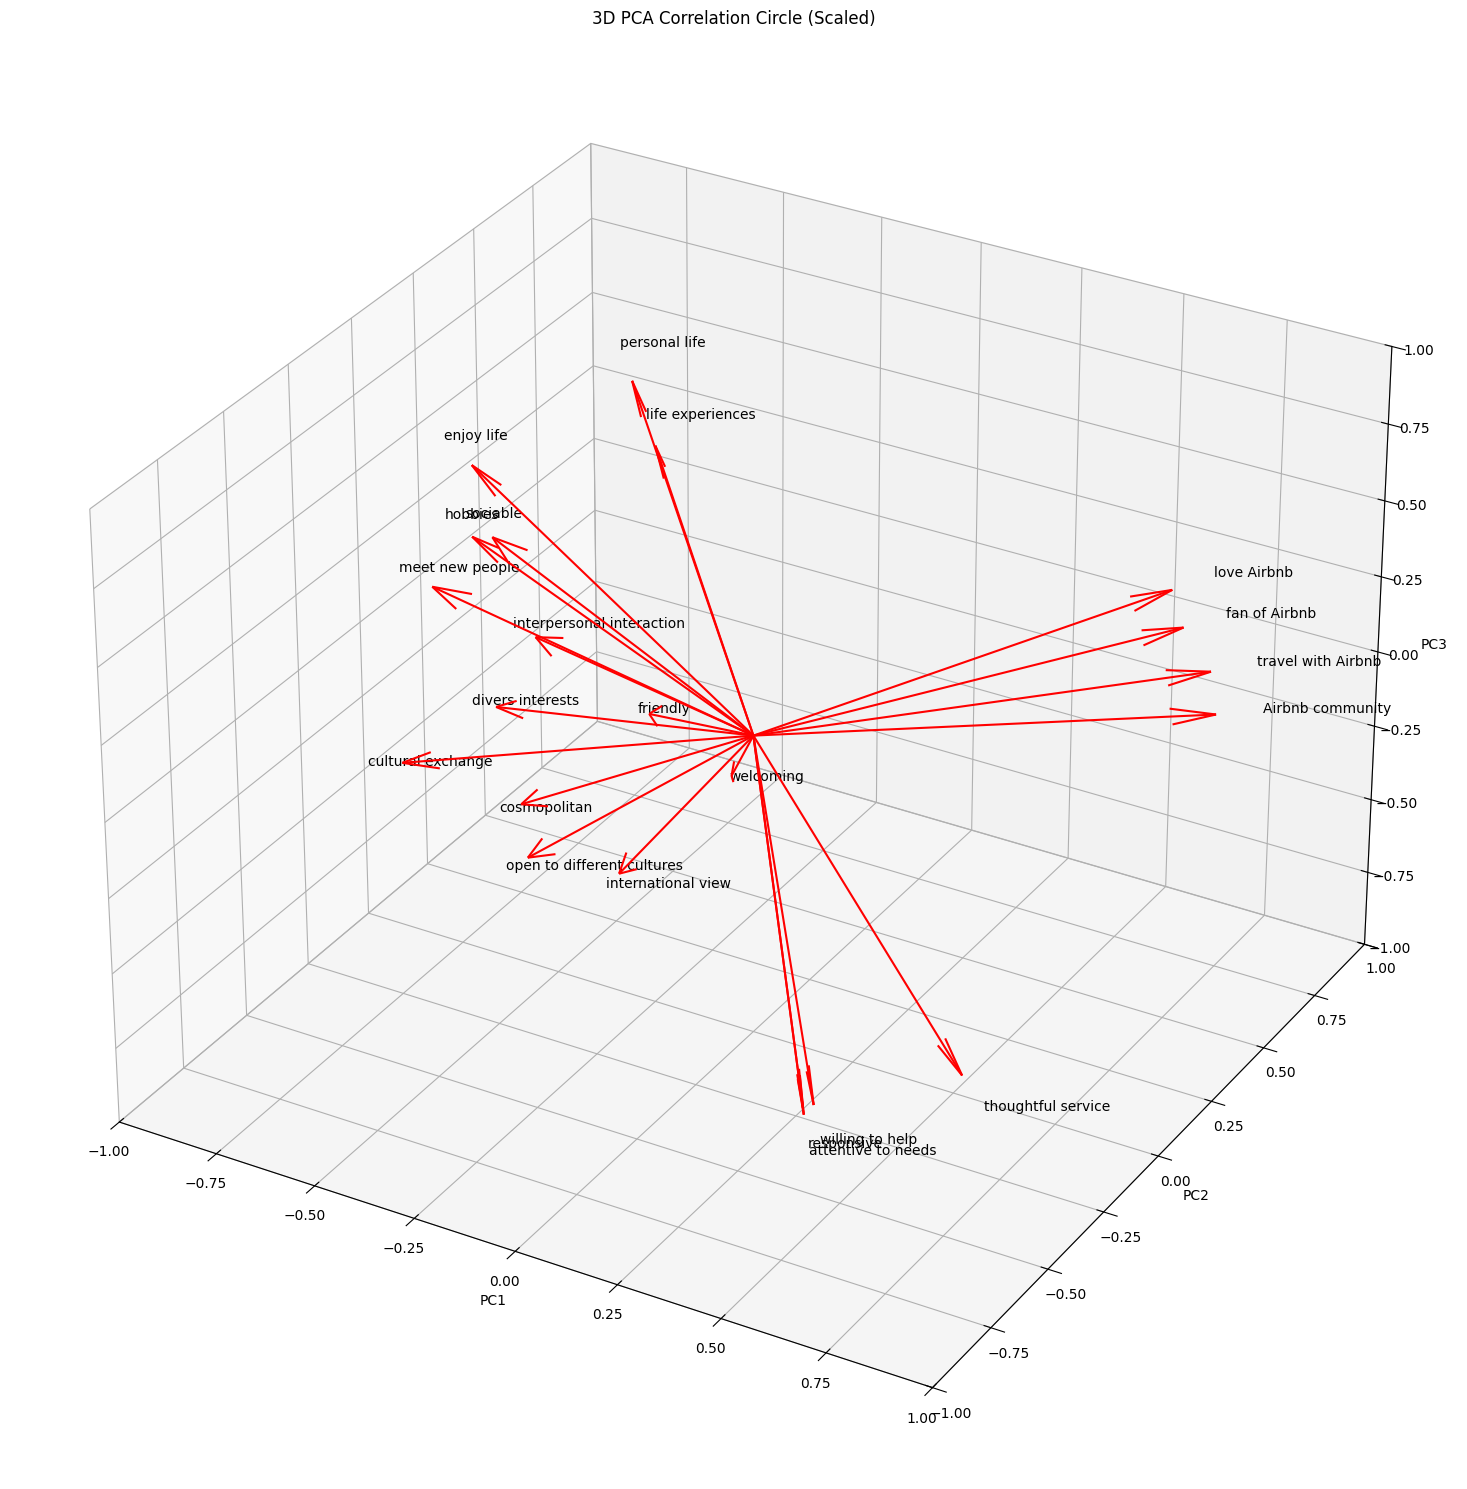

✅ [SAVE] PCA 3D saved to ..\output_fa_all_20260505\pca_3d.jpg!



In [18]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_20260505")
OUTPUT_FOLDER_DATA=Path("../data_processed")

df=df_zsc.drop(columns=['ouverture','authenticité','sociabilité','auto_promotion','exemplarité'])
listings_tactics=run_fa(df_zsc=df, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406_mean.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","auto_promotion","authenticité","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='mean',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

In [50]:
df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2312_2406_mean.csv")


C:\Users\yeliu\AppData\Local\Temp\ipykernel_46124\3052215484.py:1: DtypeWarning: Columns (6,68,115) have mixed types. Specify dtype option on import or set low_memory=False.
  df_all=pd.read_csv("../data_processed\listings_tactics-paris_london-2306_2312_2406_mean.csv")


In [51]:
df_all.columns.to_list()

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_name',
 'host_since',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'minimum_nights',
 'maximum_nights',
 'minimum_minimum_nights',
 'maximum_minimum_nights',
 'minimum_maximum_nights',
 'maximum_maximum_nights',
 'minimum_nights_avg_ntm',
 'maximum_nights_avg_ntm',
 'calendar_updated',
 'has_availability',
 'availability_30

In [37]:
var_map={
    'is_portrait':"portrait",
    "is_lifestyle":'photo de vie',
    "no_person":'sans personne'
}

tactics_bio = [
    "ouverture",
    "authenticité",
    "sociabilité",
    "auto_promotion",
    "exemplarité",
]
tactics_pic_dummies=['is_portrait','is_lifestyle','no_person']
def p_to_sig(p):
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    elif p < 0.1: return '.'
    else: return ''


df_all[tactics_bio].describe()

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
count,126329.000000,126329.000000,126329.000000,126329.000000,126329.000000
mean,0.425670,0.401271,0.548709,0.540869,0.222865
std,0.274884,0.320251,0.283459,0.275817,0.285966
min,0.000391,0.000301,0.000463,0.005064,0.000277
25%,0.186018,0.082024,0.296924,0.278018,0.009404
50%,0.391109,0.355921,0.586106,0.580706,0.062159
75%,0.640953,0.699512,0.785460,0.784633,0.370310
max,0.993145,0.990512,0.997654,0.993326,0.998530


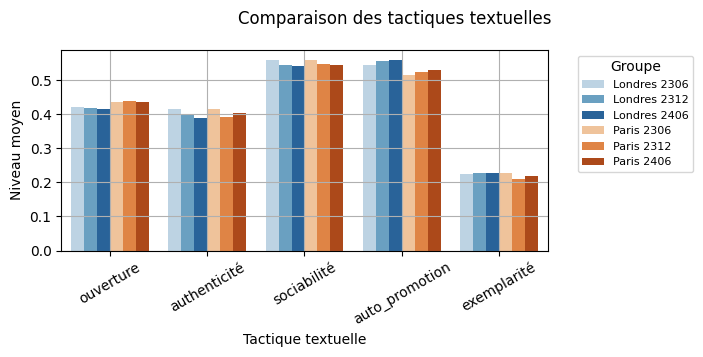

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=df_all.copy()

agg=df.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris', 'time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long['group']=agg_long.apply(lambda row: f"{'Paris' if row['in_paris']==1 else 'Londres'} {row['time']}", axis=1)
agg_long


tactics=tactics_bio
df_plot=agg_long[agg_long['variable'].isin(tactics)].copy()
groups=df_plot['group'].unique()

# ---colors----
blue_cmap = plt.cm.Blues
orange_cmap = plt.cm.Oranges
n = 3  # 每组数量
london_colors = blue_cmap(np.linspace(0.3, 0.8, n))
paris_colors  = orange_cmap(np.linspace(0.3, 0.8, n))

colors = (
    list(london_colors) +
    list(paris_colors)
)
palette={k: v for k, v in zip (groups, colors)}


# vis
fig, ax=plt.subplots(figsize=(8,4))

sns.barplot(
    data=df_plot,   
    x="variable",
    y="mean",
    hue="group",
    palette=palette,
    order=tactics_bio,#***
    # errorbar="sd"
    ax=ax
)
ax.tick_params(axis="x", rotation=30)
ax.set_ylabel("Niveau moyen")
ax.set_xlabel("Tactique textuelle")
ax.grid()

plt.suptitle("Comparaison des tactiques textuelles",fontsize=12)

handles, labels=ax.get_legend_handles_labels()
plt.legend(handles, labels, title="Groupe", loc="upper left", bbox_to_anchor=(1.05, 1), fontsize=8)
plt.tight_layout(rect=[0,0.1, 0.9,1])

plt.show()

In [41]:
def get_event_study_data(model, var):
    params = model.params
    bse = model.bse
    pvalues=model.pvalues
    
    # 提取 interaction terms
    data = pd.DataFrame({
        "coef": params,
        "se": bse,
        'pval':pvalues
    }).reset_index()

    data.columns = ["variable", "coef", "se", "pval"]

    # 只保留 in_paris × time
    data = data[data["variable"].str.contains("in_paris:C\\(time\\)")]    
    
    # 提取时间点
    data["time"] = data["variable"].str.extract(r"T\.(\d+)")

    # 排序
    data = data.sort_values("time")

    # 置信区间
    data["ci_low"] = data["coef"] - 1.96 * data["se"]
    data["ci_high"] = data["coef"] + 1.96 * data["se"]
    
    # baseline（2306 = 0）
    baseline = pd.DataFrame({
        "time": ["2306"],
        "coef": [0],
        "ci_low": [0],
        "ci_high": [0]
    })

    data = pd.concat([baseline, data], ignore_index=True)

    data = data.sort_values("time")
    data['variable']=var
    data['sig']=data['pval'].apply(p_to_sig)        
    # data['label']=data['time']+' '+data['sig']        
    
    return data

results=[]
tactics=tactics_bio+tactics_pic_dummies
for var in tactics:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df).fit()
    # print(model_tactic.summary())    
    res=get_event_study_data(model_tactic, var)
    results.append(res)

results_did_evolution=pd.concat(results, axis=0)
display(results_did_evolution)


,time,coef,ci_low,ci_high,variable,se,pval,sig
0,2306,0.000000,0.000000,0.000000,ouverture,NaN,NaN,
1,2312,-0.004409,-0.012019,0.003200,ouverture,0.003882,2.560888e-01,
2,2406,0.009240,0.002278,0.016202,ouverture,0.003552,9.287524e-03,**
0,2306,0.000000,0.000000,0.000000,authenticité,NaN,NaN,
1,2312,0.010843,0.002370,0.019315,authenticité,0.004323,1.213288e-02,*
2,2406,0.026437,0.018685,0.034188,authenticité,0.003955,2.326989e-11,***
0,2306,0.000000,0.000000,0.000000,sociabilité,NaN,NaN,
1,2312,0.007770,-0.000390,0.015929,sociabilité,0.004163,6.199149e-02,.
2,2406,0.020452,0.012987,0.027917,sociabilité,0.003809,7.900139e-08,***
0,2306,0.000000,0.000000,0.000000,auto_promotion,NaN,NaN,


C:\Users\yeliu\AppData\Local\Temp\ipykernel_46124\1571964676.py:68: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1,1])


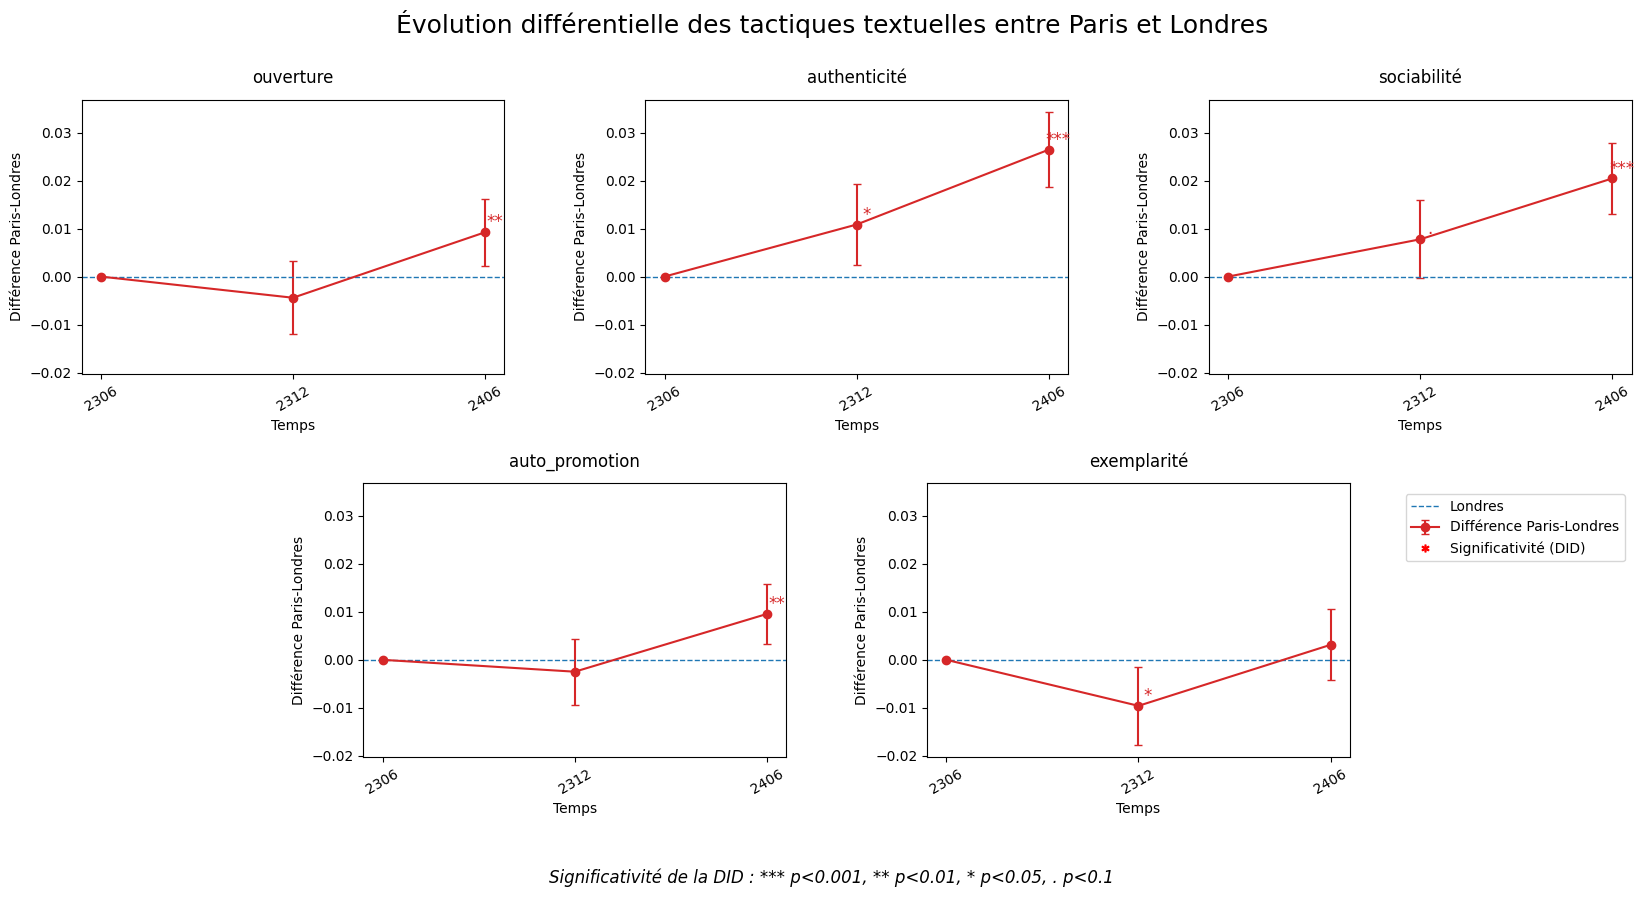

In [42]:
from utils import modeling_did
importlib.reload(modeling_did)
from utils.modeling_did import plot_one_did

# ---layout---
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4], sharey=ax1)
ax3 = fig.add_subplot(gs[0, 4:6], sharey=ax1)
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3], sharey=ax1)
ax5 = fig.add_subplot(gs[1, 3:5], sharey=ax1)
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


tactics=tactics_bio
df_plot=results_did_evolution.copy()#[results_did_evolution['variable'].isin(tactics)].copy()

for i, var in enumerate(tactics):
    plot_one_did(data=df_plot, axes=axes, i=i, var=var, title=None)
    
# --------------------legend------------------------
fig.suptitle(
        "Évolution différentielle des tactiques textuelles entre Paris et Londres",
        fontsize=18,
        y=0.98 #大标题到子图的距离, 越大越远
    )

from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='red', markersize=5,
           label='Significativité (DID)')
)
labels = labels + [
    "Significativité (DID)"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.9,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 1,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

## différentiel de did
specs=[
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]  
    """
]

df=df_all.copy()
results=[]
for var in tactics_bio+tactics_pic_dummies:
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )
    model_tactic=smf.ols(formula, data=df).fit(cov_type="HC1")

    for i, term in enumerate(specs):
        test = model_tactic.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map else var}"
        })
        results.append(res)

results_did_diff=pd.concat(results, axis=0)
display(results_did_diff)

,variable,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,0.013649,0.003636,1.744411e-04,***,0.006522,0.020776,ouverture
0,authenticité,0.015594,0.004031,1.096223e-04,***,0.007693,0.023495,authenticité
0,sociabilité,0.012682,0.003917,1.203676e-03,**,0.005006,0.020358,sociabilité
0,auto_promotion,0.012037,0.003216,1.817845e-04,***,0.005734,0.018339,auto_promotion
0,exemplarité,0.012713,0.003865,1.005188e-03,**,0.005137,0.020289,exemplarité
0,is_portrait,0.017154,0.004329,7.429062e-05,***,0.008668,0.025639,portrait
0,is_lifestyle,0.014838,0.004186,3.924580e-04,***,0.006635,0.023042,photo de vie
0,no_person,-0.031992,0.003941,4.778351e-16,***,-0.039717,-0.024267,sans personne


In [ ]:
var="sociabilité"
specs=[
    """    
    in_paris:C(time)[T.2406]
    -in_paris:C(time)[T.2312]  
    """
]

    
formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                "number_of_reviews_ltm + "
                "C(host_is_superhost) +"
                "years_since_host + professional_host + "
                "host_response_rate +  C(host_response_time)+"
                "has_text + lang_en + lang_fr + text_length+"
                "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                "C(time) + in_paris * C(time)"
        )

model_tactic=smf.ols(formula, data=df_all).fit(cov_type="HC1")
print(model_tactic.summary())

for i, term in enumerate(specs):
    test = model_tactic.t_test(term)
    sig=p_to_sig(test.pvalue)
    res= pd.DataFrame({
        'variable':var,
        "coef": test.effect[0],
        "se": test.sd[0],
        "pval": test.pvalue,
        "sig":sig,
        "ci_low": test.conf_int()[0][0],
        "ci_high": test.conf_int()[0][1],
        'label':f"{var_map.get(var,'') if var in var_map else var}"
    })
# results.append(res)

                            OLS Regression Results                            
Dep. Variable:            sociabilité   R-squared:                       0.041
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     853.3
Date:                Tue, 05 May 2026   Prob (F-statistic):               0.00
Time:                        12:54:12   Log-Likelihood:                -17373.
No. Observations:              126329   AIC:                         3.480e+04
Df Residuals:                  126301   BIC:                         3.508e+04
Df Model:                          27                                         
Covariance Type:                  HC1                                         
                                                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------

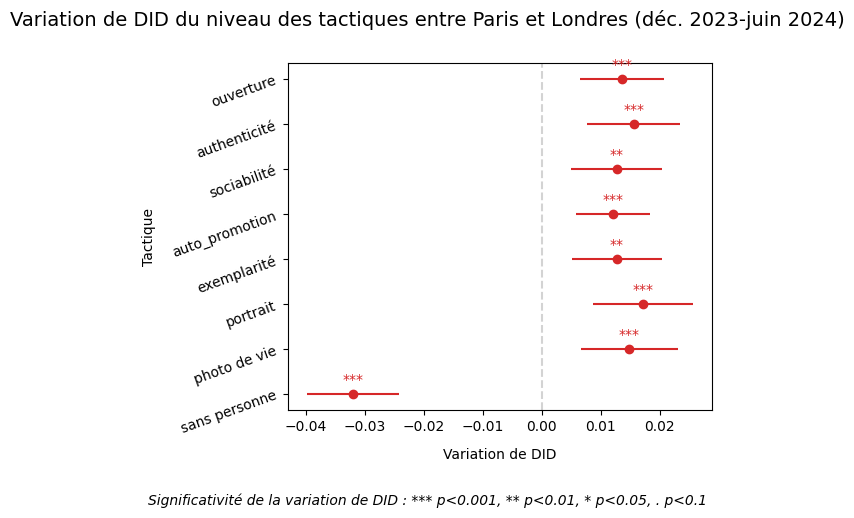

In [21]:
import matplotlib.pyplot as plt

##+fit(cov_type="HC1")
fig, ax=plt.subplots(figsize=(6,5))
change_colors='tab:red'
sub=results_did_diff.copy()

tactics=tactics_bio+['portrait','photo de vie','sans personne']
order=tactics[::-1]
sub=sub.set_index('label').loc[order].reset_index()


# ---plot---
ax.errorbar(
    x=sub["coef"],
    y=sub["label"],
    # y=y,
    xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
    fmt='o', 
    color=change_colors,
    # linestyle='-' if new==1 else '--'
)
# ---sig---
for _, row in sub.iterrows():
    ax.annotate(
        row["sig"],
        xy=(row["coef"], row["label"]),
        xytext=(0, 10),         
        textcoords='offset points',
        ha='center',
        va='center',
        fontsize=10,
        color=change_colors
)    
        
ax.axvline(0, linestyle='--', color="lightgray", label="Changement de Londres")    
ax.set_xlabel(f"Variation de DID", labelpad=10)
ax.set_ylabel('Tactique', labelpad=10)
ax.tick_params(axis='y', rotation=20)
# ax.set_title()

fig.suptitle(
    "Variation de DID du niveau des tactiques entre Paris et Londres (déc. 2023-juin 2024)",
    # "Evolution de l'écart des niveaux de tactiques entre Paris et Londres (déc. 2023 - juin 2024)", 
    fontsize=14,
    y=1
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

In [62]:
# real+cf effet 

def get_cf_data(df, model, var):
    """
    不改变时间，不改变地点，仅减去jo（交互项之差）
    """    
    import numpy as np
    
    
    df["y_hat"] = model.predict(df)
    term = ('''
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
    '''
        #- C(time)[T.2406]
        # + C(time)[T.2312]
    )
    #jo shock，没有2406-2312则是paris shock
    #将2312作为了变化的基准，所以不用考虑2306-2312的不平行
    
    test = model.t_test(term)
    adjustment=test.effect[0]
    pval=test.pvalue
    sig=p_to_sig(pval)
               
    print(f'ddd of {var}: {adjustment} {sig}')
    
    df["y_cf"] = df["y_hat"]
    df.loc[
        (df["in_paris"]==1) & (df["time"]=="2406"),
        "y_cf"
    ] -= adjustment#==去掉2406交互项，再加一次2312交互项
    
    agg=df.groupby(['in_paris','time'])[['y_hat','y_cf']].mean().reset_index()
    agg['variable']=var
    
    var_map={
        'is_portrait':"portrait",
        "is_lifestyle":'photo de vie',
        "no_person":'sans personne'
    }
    agg['label']=agg['variable'].apply(lambda x: var_map.get(x,'') if x in var_map.keys() else x)
    
    # +pval +sig
    agg["pval"] = np.nan 
    agg["sig"] = np.nan 
    
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'pval'
            ]=pval
    agg.loc[
        (agg['in_paris']==1)&(agg['time']=="2406"),
        'sig'
            ]=sig
    
    return agg 


var="sociabilité"
formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
model_tactic=smf.ols(formula, data=df_all).fit()
agg=get_cf_data(df=df_all, model=model_tactic, var=var)
agg

ddd of sociabilité: 0.01268201426453712 **


C:\Users\yeliu\AppData\Local\Temp\ipykernel_46124\1363790565.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '**' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  agg.loc[


,in_paris,time,y_hat,y_cf,variable,label,pval,sig
0,0,2306,0.335110,0.335110,sociabilité,sociabilité,NaN,NaN
1,0,2312,0.310858,0.310858,sociabilité,sociabilité,NaN,NaN
2,0,2406,0.305740,0.305740,sociabilité,sociabilité,NaN,NaN
3,1,2306,0.296186,0.296186,sociabilité,sociabilité,NaN,NaN
4,1,2312,0.274388,0.274388,sociabilité,sociabilité,NaN,NaN
5,1,2406,0.259619,0.259619,sociabilité,sociabilité,NaN,NaN


In [ ]:

aggs=[]
for var in tactics_bio+tactics_pic_dummies:
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
                    "number_of_reviews_ltm + "
                    "C(host_is_superhost) +"
                    "years_since_host + professional_host + "
                    "host_response_rate +  C(host_response_time)+"
                    "has_text + lang_en + lang_fr + text_length+"
                    "price  + availability_90 + C(room_type) + C(instant_bookable) + "
                    "C(time) + in_paris * C(time)"
            )
    model_tactic=smf.ols(formula, data=df).fit()
    agg=get_cf_data(df=df_all, model=model_tactic, var=var)
    aggs.append(agg)
    # break
cf_data=pd.concat(aggs,axis=0)
# cf_data


In [25]:
cf_data

,in_paris,time,y_hat,y_cf,variable,label,pval,sig
0,0,2306,0.200788,0.200788,ouverture,ouverture,NaN,NaN
1,0,2312,0.189724,0.189724,ouverture,ouverture,NaN,NaN
2,0,2406,0.183817,0.183817,ouverture,ouverture,NaN,NaN
3,1,2306,0.223971,0.223971,ouverture,ouverture,NaN,NaN
4,1,2312,0.207377,0.207377,ouverture,ouverture,NaN,NaN
5,1,2406,0.201465,0.201465,ouverture,ouverture,NaN,NaN
0,0,2306,0.210111,0.210111,authenticité,authenticité,NaN,NaN
1,0,2312,0.183954,0.183954,authenticité,authenticité,NaN,NaN
2,0,2406,0.175814,0.175814,authenticité,authenticité,NaN,NaN
3,1,2306,0.154326,0.154326,authenticité,authenticité,NaN,NaN


In [57]:
cf_data[cf_data['variable']=='sociabilité']

,in_paris,time,y_hat,y_cf,variable,label,pval,sig
0,0,2306,0.335110,0.335110,sociabilité,sociabilité,NaN,NaN
1,0,2312,0.310858,0.310858,sociabilité,sociabilité,NaN,NaN
2,0,2406,0.305740,0.305740,sociabilité,sociabilité,NaN,NaN
3,1,2306,0.296186,0.296186,sociabilité,sociabilité,NaN,NaN
4,1,2312,0.274388,0.274388,sociabilité,sociabilité,NaN,NaN
5,1,2406,0.259619,0.259619,sociabilité,sociabilité,NaN,NaN


In [63]:
agg=df_all.groupby(['in_paris','time'])[tactics_bio+tactics_pic_dummies].mean().reset_index()
agg_long=agg.melt(
    id_vars=['in_paris','time'],
    value_vars=tactics_bio+tactics_pic_dummies,
    var_name='variable',
    value_name='mean'
)
agg_long[agg_long['variable']=='sociabilité']

,in_paris,time,variable,mean
12,0,2306,sociabilité,0.560047
13,0,2312,sociabilité,0.545036
14,0,2406,sociabilité,0.541756
15,1,2306,sociabilité,0.557724
16,1,2312,sociabilité,0.545868
17,1,2406,sociabilité,0.544560


## 20260505


tactics:  ['ouverture' 'authenticité' 'sociabilité' 'auto_promotion' 'exemplarité']


C:\Users\yeliu\AppData\Local\Temp\ipykernel_46124\2092979402.py:143: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 0.88,1])


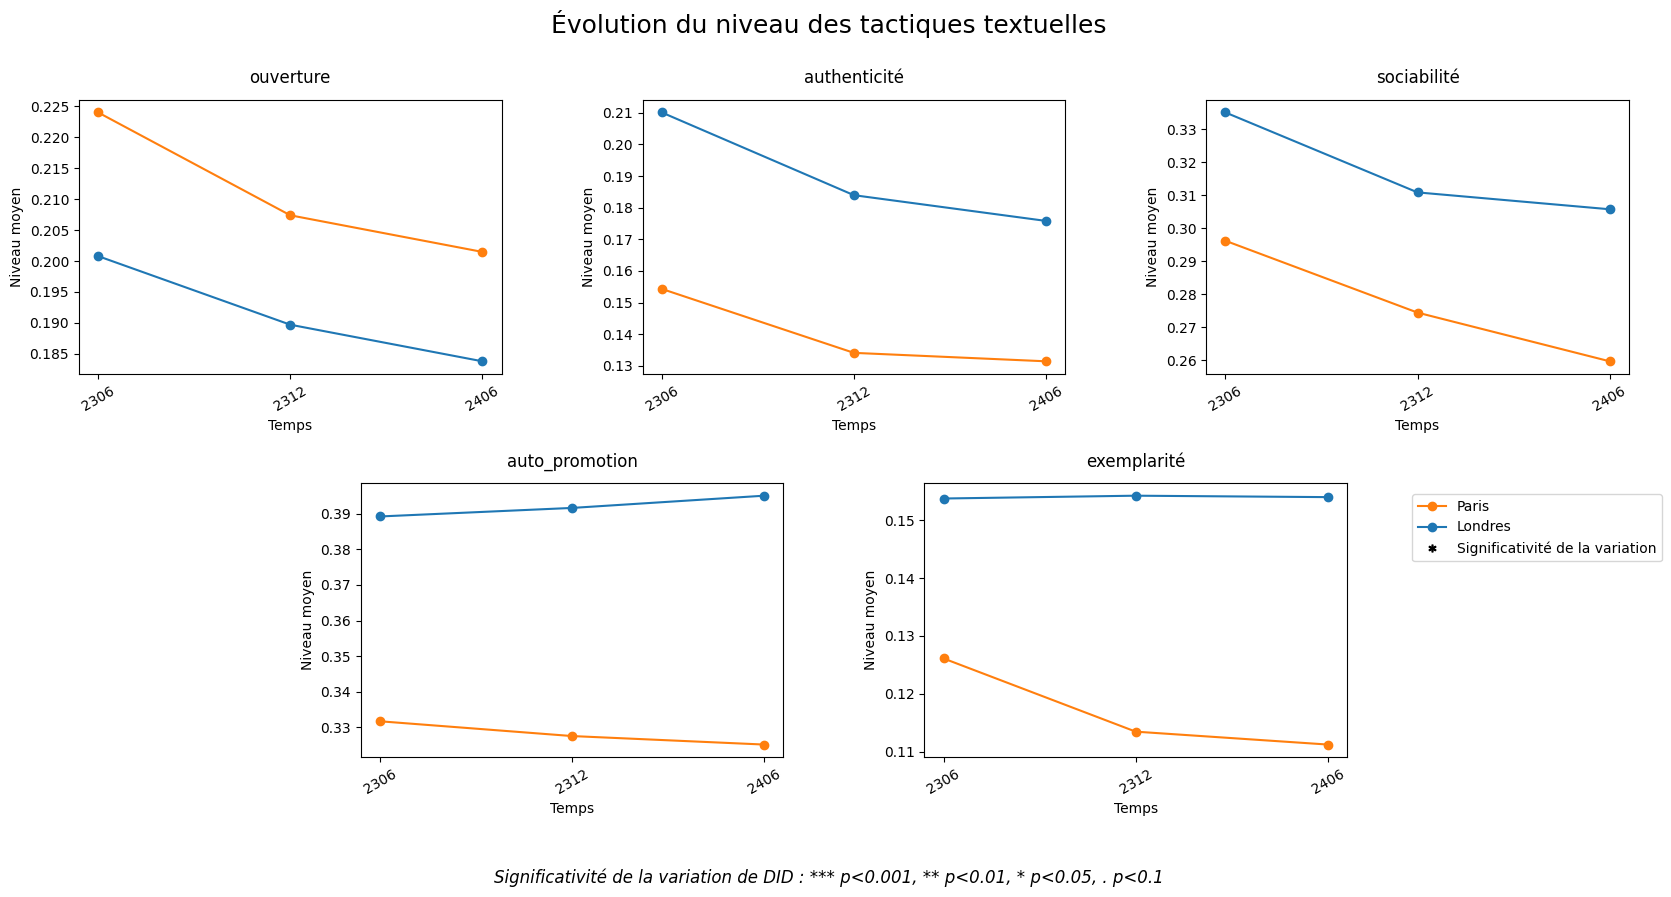

In [40]:
def plot_one_cf(cf_data, axes=None, i=0,  var="authenticité", title=None, ylabel=None, cf=False):
    if not axes:
        fig, ax=plt.subplots(figsize=(6,4))
    else :
        ax=axes[i]
    cf_data['time']=cf_data['time'].astype(str)
    
    sub=cf_data[cf_data['label']==var]
    # display(sub)
    
    # x=list(range(len(sub['time'].unique())))
    # print("axis x :", x)
    
    ## plt
    paris = sub[sub["in_paris"] == 1]    
    # ---paris obs---
    ax.plot(
        paris['time'],# x
        # paris["time"],#.map(time_map),        
        paris["y_hat"],
        marker="o",
        label="Paris",
        # label="Observé (Paris)",
        color='tab:orange'
    )    
    
    if cf==True:
        # ---paris cf---
        ax.plot(
            x,
            # paris["time"],#.map(time_map),
            paris["y_cf"],
            marker="o",
            linestyle="--",
            label="Contrefactuel(Paris)",
            color='tab:orange'
        )
        # # + sig
        # ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]
        # xi,yi, sig=2, paris[paris["time"]=="2406"]['y_cf'].iloc[0],ddd_sig
        # ax.text(xi, yi + 0.002, sig, ha='center', 
        #     color='tab:orange', fontsize=12)
    
    
    # ---london obs---
    control = sub[sub["in_paris"] == 0]
    ax.plot(
        control["time"],#.map(time_map),
        control["y_hat"],
        marker="o",
        # alpha=0.4,
        label="Londres",
        # label="Observé (Londres)",
        color='tab:blue'
    )
    
    # ax.set_xticks()
    # ax.set_xticklabels(sub['time'].unique())
    ax.tick_params(axis='x', rotation=30)
    
    ylabel="Niveau moyen" if ylabel is None else ylabel
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Temps")

    title=var if title==None else title
    # ddd_sig=sub[(sub['in_paris']==1)&(sub['time']=="2406")]['sig'].iloc[0]

    # ax.set_title(f"{title} {ddd_sig}", pad=12)
    ax.set_title(f"{title}", pad=12)
    
    if not axes:
        ax.legend(fontsize=10)
        
    return 


# ---layout---
import matplotlib.gridspec as gridspec

# 使用更细的列分辨率（2 行 × 6 列），方便把第二行两个图放在中间列
fig = plt.figure(figsize=(20,9))# sharey=True
gs = gridspec.GridSpec(2, 6, figure=fig, hspace=0.4, wspace=1)

axes = []
# 第一行三个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[0, 4:6])
axes.extend([ax1, ax2, ax3])

# 第二行两个：让它们居中，分别占中间的两列 (1:3 和 3:5)
ax4 = fig.add_subplot(gs[1, 1:3])
ax5 = fig.add_subplot(gs[1, 3:5])
axes.extend([ax4, ax5])

# 确保 tactics_vars 长度为 5（或小于等于 len(axes)）
# n_to_plot = min(len(tactics), len(axes))


## plot:
tactics=tactics_bio
df_plot=cf_data[cf_data['label'].isin(tactics)].copy()
print('tactics: ',df_plot.variable.unique())

for i, var in enumerate(tactics):
    plot_one_cf(cf_data=df_plot, axes=axes, i=i,  var=var, title=None, ylabel=None)


# layout:
fig.suptitle(
        "Évolution du niveau des tactiques textuelles",
        fontsize=18,
        y=0.98
    )

# --------------------legend------------------------
from matplotlib.lines import Line2D
handles, labels = axes[0].get_legend_handles_labels()
# --- add custom legend :sig note ---
handles.append(
    Line2D([0], [0], marker='$*$', linestyle='None', color='black', markersize=5,
           label='Significativité de la variation')
)
labels = labels + [
    "Significativité de la variation"
]

fig.legend(
    handles,
    labels,
    loc="upper right",
    bbox_to_anchor=(0.92,0.45) # legend (x, y)，x>1则在图外, y=0在底线
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=12,
    style="italic"   
)

plt.tight_layout(rect=[0, 0.1, 0.88,1])
plt.subplots_adjust(bottom=0.15)#控制子图到底的距离，给text留出空间
plt.show()

# authen，auto，exem上升，ouv不显著变化，socio下降
# 但是jo都有提升效果！


In [38]:

specs=[
    # constants: time=2312-2406, in_paris: paris-london, 
    # is_new_host, terms 
    (1, """
        in_paris:C(time)[T.2406] + in_paris:C(time)[T.2406]:is_new_host 
        - in_paris:C(time)[T.2312] - in_paris:C(time)[T.2312]:is_new_host
        """), 
    # - C(time)[T.2406]:is_new_host
    # + C(time)[T.2312]:is_new_host
        
    (0, """
        in_paris:C(time)[T.2406]
        - in_paris:C(time)[T.2312]
        """) 
#       - C(time)[T.2406]
#         + C(time)[T.2312]
]

df=df_all.copy()
results=[]

for var in tactics_bio+tactics_pic_dummies:
    print(var)
    formula= (f"{var} ~ C(host_identity_verified)  + review_scores_rating + has_rating +"
            "number_of_reviews_ltm + "
            "C(host_is_superhost) +"
            "years_since_host + professional_host + "
            "host_response_rate +  C(host_response_time)+"
            "has_text + lang_en + lang_fr + text_length+"
            "price  + availability_90 + C(room_type) + C(instant_bookable) + "
            "C(time) + in_paris * C(time)*is_new_host"
    )
    model_new=smf.ols(formula, data=df).fit()

    for i, (new, term) in enumerate(specs):
        test = model_new.t_test(term)
        sig=p_to_sig(test.pvalue)
        res= pd.DataFrame({
            'variable':var,
            "is_new_host":new,
            "coef": test.effect[0],
            "se": test.sd[0],
            "pval": test.pvalue,
            "sig":sig,
            "ci_low": test.conf_int()[0][0],
            "ci_high": test.conf_int()[0][1],
            'label':f"{var_map.get(var,'') if var in var_map.keys() else var}"
        })
        results.append(res)
    # break

results_ddd_new=pd.concat(results, axis=0)
display(results_ddd_new)  


ouverture
authenticité
sociabilité
auto_promotion
exemplarité
is_portrait
is_lifestyle
no_person


,variable,is_new_host,coef,se,pval,sig,ci_low,ci_high,label
0,ouverture,1,-0.009059,0.008818,3.042956e-01,,-0.026343,0.008225,ouverture
0,ouverture,0,0.008134,0.004104,4.746576e-02,*,0.000091,0.016178,ouverture
0,authenticité,1,0.042862,0.009812,1.252880e-05,***,0.023631,0.062093,authenticité
0,authenticité,0,-0.003870,0.004566,3.966785e-01,,-0.012820,0.005079,authenticité
0,sociabilité,1,0.056653,0.009457,2.093739e-09,***,0.038118,0.075188,sociabilité
0,sociabilité,0,-0.006370,0.004401,1.478031e-01,,-0.014995,0.002256,sociabilité
0,auto_promotion,1,-0.004282,0.007924,5.889051e-01,,-0.019812,0.011248,auto_promotion
0,auto_promotion,0,0.016555,0.003687,7.143000e-06,***,0.009328,0.023782,auto_promotion
0,exemplarité,1,0.057263,0.009349,9.089261e-10,***,0.038939,0.075587,exemplarité
0,exemplarité,0,-0.006429,0.004351,1.395075e-01,,-0.014956,0.002099,exemplarité


is_new_host=1
is_new_host=0


C:\Users\yeliu\AppData\Local\Temp\ipykernel_46124\2676869112.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]


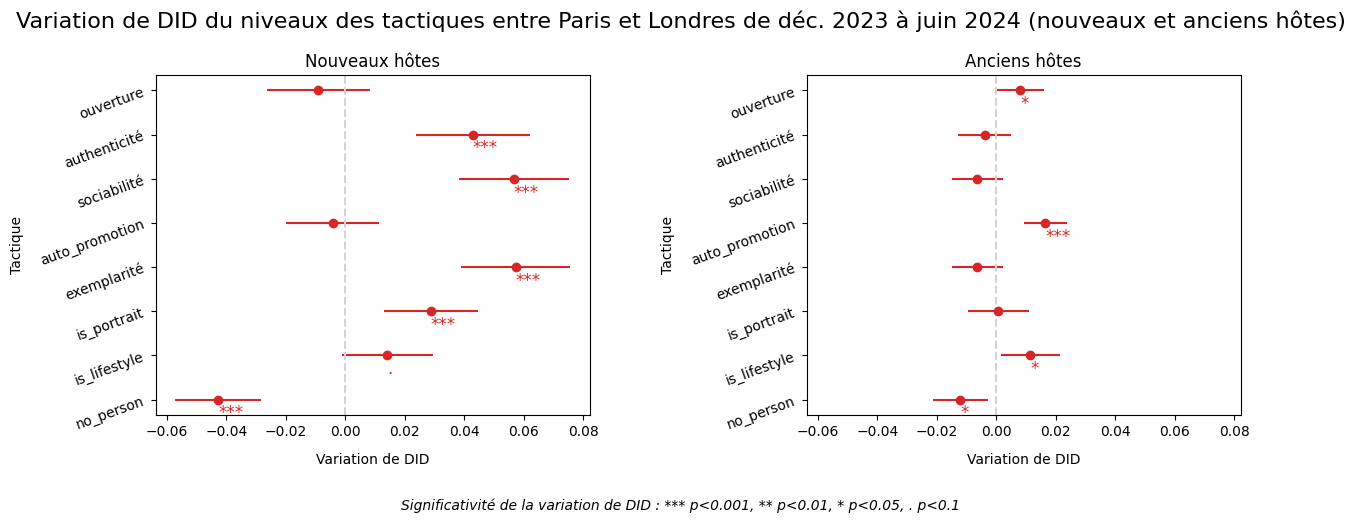

In [39]:
## ---layout 2facets----
import matplotlib.gridspec as gridspec
fig = plt.figure(figsize=(14, 5)) 
gs = gridspec.GridSpec(1, 2, figure=fig, hspace=0.5, wspace=0.5)# 1行2列

axes = []
# 第一行两个：分别占两列宽 (0:2, 2:4, 4:6)
ax1 = fig.add_subplot(gs[0, 0:1])
ax2 = fig.add_subplot(gs[0, 1:2], sharex=ax1)#**
axes.extend([ax1, ax2])



change_colors='tab:red'
#
tactics=tactics_bio+tactics_pic_dummies

df_plot=results_ddd_new[results_ddd_new['variable'].isin(tactics)].copy()#***

subplot_col="is_new_host"

for i, new in enumerate(df_plot[subplot_col].unique()):
    print(f"{subplot_col}={new}")
    
    sub=df_plot[df_plot[subplot_col]==new].copy()
    order=tactics[::-1]
    sub = sub.set_index("variable").loc[order].reset_index()
    # display(sub)

    ax=axes[i]
    ax.errorbar(
        x=sub["coef"],
        y=sub["variable"],
        # y=y,
        xerr=[sub["coef"] - sub["ci_low"], sub["ci_high"] - sub["coef"]],
        fmt='o', 
        color=change_colors,
        # linestyle='-' if new==1 else '--'
    )
    # ---sig---
    for _, row in sub.iterrows():
        ax.annotate(
            row["sig"],
            xy=(row["coef"], row["variable"]),
            xytext=(0, -10),         
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=12,
            color=change_colors
    )    
            
    ax.axvline(0, linestyle='--', color="lightgray", label="Variation de Londres")    
    ax.set_xlabel(f"Variation de DID", labelpad=10)
    ax.set_ylabel('Tactique', labelpad=10)
    ax.tick_params(axis='y', rotation=20)
    ax.set_title(f"{'Nouveaux hôtes' if new==1 else 'Anciens hôtes'}")
    
    

## ---legend 2facets----
fig.suptitle(
    "Variation de DID du niveaux des tactiques entre Paris et Londres de déc. 2023 à juin 2024 (nouveaux et anciens hôtes)", 
    fontsize=16,
    y=1.01
)

plt.figtext(
    0.5, 0.01,
    "Significativité de la variation de DID : *** p<0.001, ** p<0.01, * p<0.05, . p<0.1",
    ha="center",
    fontsize=10,
    style="italic",   
)
plt.tight_layout(rect=[0, 0.1, 1, 1])# [left, bottom, right, top]
plt.subplots_adjust(bottom=0.2)#控制子图到底的距离，给text留出空间
plt.show()

## 20260501

[INFO] all output saved to '..\output_fa_all_20260501'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:36700 rows!

[INFO] kmo_model score (> 0.7) :0.8759562519516204

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


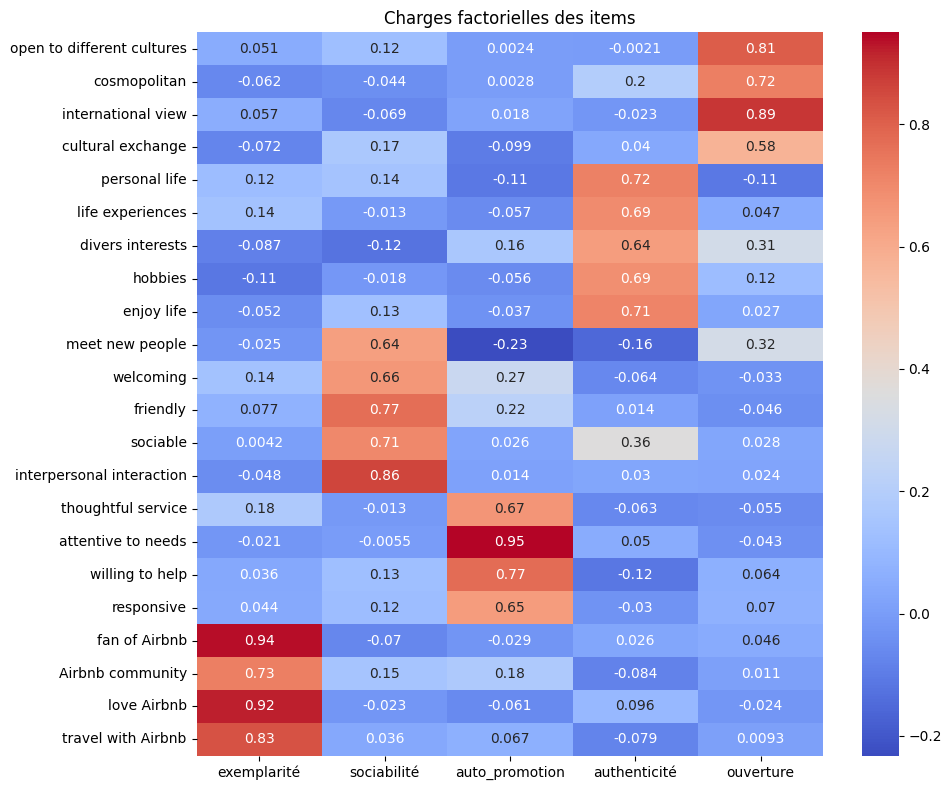

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260501\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260501\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:175: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.8091,-,-,-,-,0.672819,0.327181
cosmopolitan,0.7248,-,-,-,-,0.569474,0.430526
international view,0.8893,-,-,-,-,0.799620,0.200380
cultural exchange,0.575,-,-,-,-,0.374518,0.625482
personal life,-,0.7221,-,-,-,0.579565,0.420435
life experiences,-,0.6937,-,-,-,0.506664,0.493336
divers interests,-,0.6439,-,-,-,0.561562,0.438438
hobbies,-,0.6855,-,-,-,0.500349,0.499651
enjoy life,-,0.7147,-,-,-,0.532629,0.467371
meet new people,-,-,0.6375,-,-,0.584983,0.415017


[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all_20260501\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260501\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(36700, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.059958,0.727570
authenticité,-0.130081,0.570689
sociabilité,0.490203,0.448626
auto_promotion,0.993586,-0.055894
exemplarité,0.514652,0.001579


✅[SAVE] scores df saved to ..\output_fa_all_20260501\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260501\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


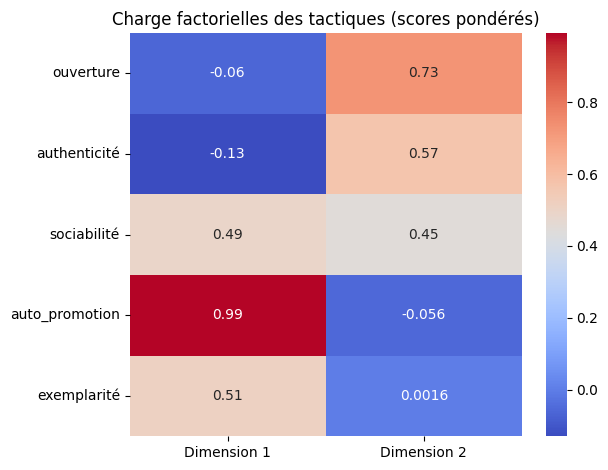

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all_20260501\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,ouverture_y,ouverture_y,authenticité_y,authenticité_y,sociabilité_y,sociabilité_y,auto_promotion_y,auto_promotion_y,exemplarité_y,exemplarité_y
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,0.161147,0.170693,-0.665889,-0.666779,0.980910,0.999759,1.339927,1.346659,0.203598,0.183619
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0.930145,0.954586,0.438044,0.425442,-1.296640,-1.290718,-0.974180,-0.949909,-0.723171,-0.727067
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,1.023326,1.038566,1.203827,1.205873,-0.668133,-0.656903,-0.568512,-0.552615,1.350431,1.321069
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,-0.125047,-0.096404,1.364940,1.375039,-0.258796,-0.243634,-0.936774,-0.924116,-0.637748,-0.637411
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,0.158115,0.172977,-0.610320,-0.604943,0.902967,0.912437,1.719308,1.716898,0.633420,0.619460


[INFO] scores shape (len(data), 1/2*n_factors) :(36700, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 36700, 36700, 36700
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.857254
1,authenticité,0.848983
2,sociabilité,0.874202
3,auto_promotion,0.878216
4,exemplarité,0.923024


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260501\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6251583372727505
[INFO] mean UNIQ : 0.37484166272724956

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

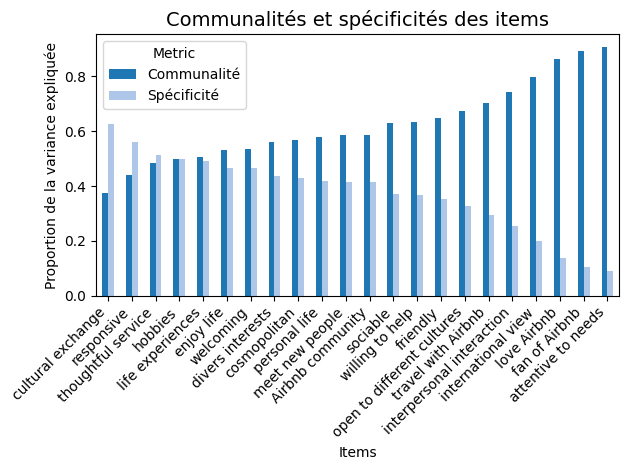

✅ [SAVE] barplot saved to ..\output_fa_all_20260501\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7825925470844366


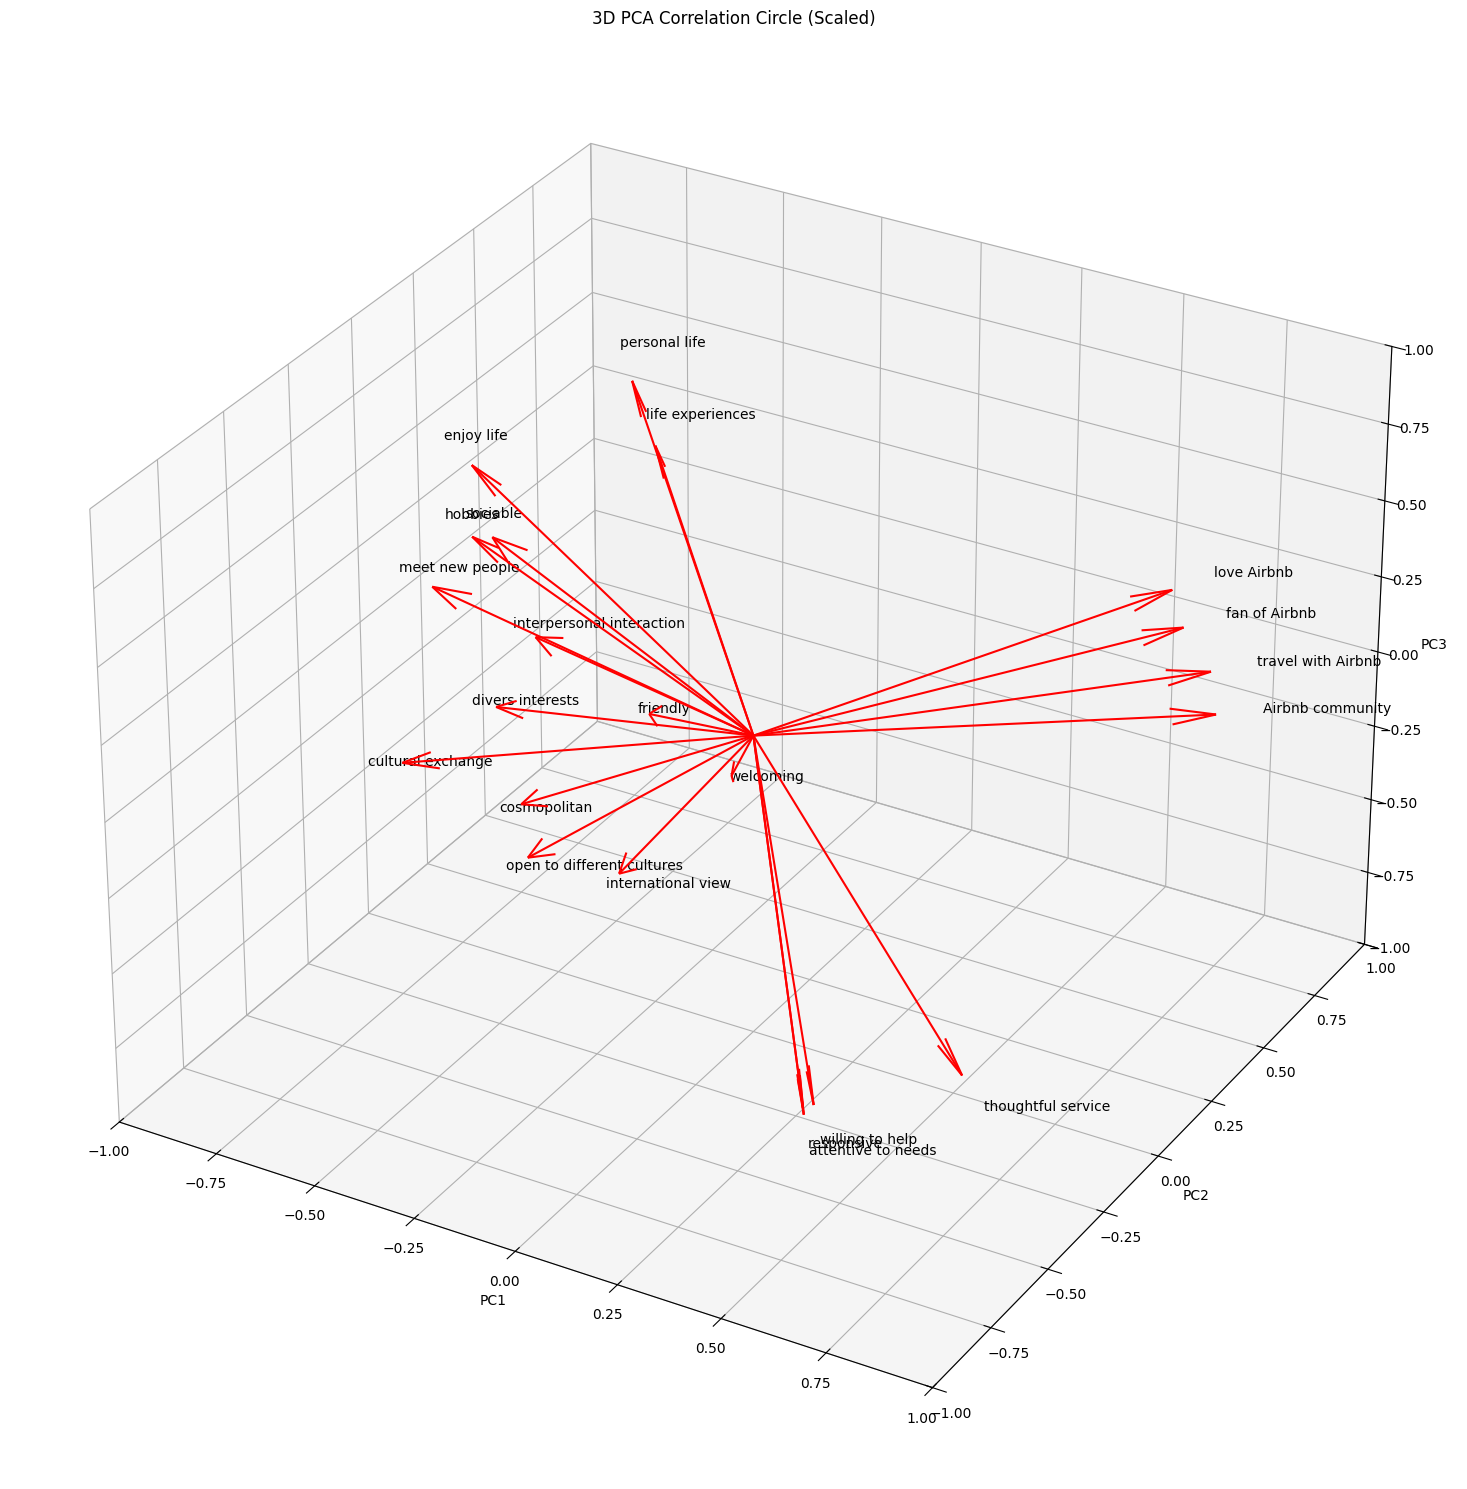

✅ [SAVE] PCA 3D saved to ..\output_fa_all_20260501\pca_3d.jpg!



In [4]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_20260501")
OUTPUT_FOLDER_DATA=Path("../data_processed")

df_zsc=df_zsc.copy()
listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","auto_promotion","authenticité","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## 2026-04-30

[INFO] all output saved to '..\output_fa_all_20260430'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:63085 rows!

[INFO] kmo_model score (> 0.7) :0.8753547002171318

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


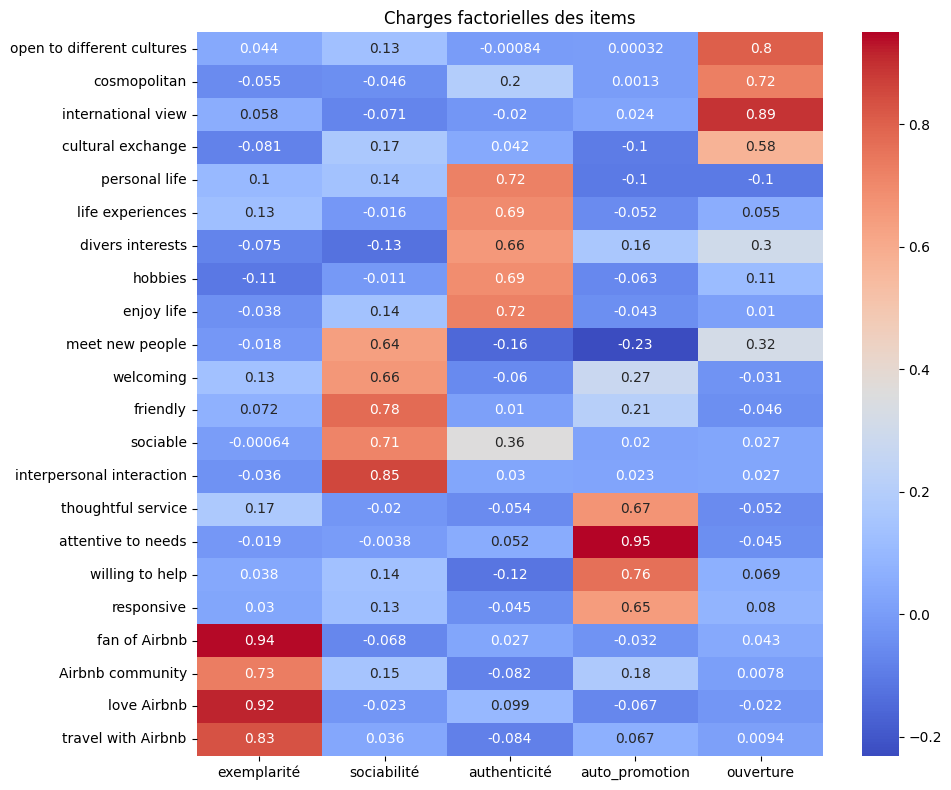

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260430\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260430\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.8026,-,-,-,-,0.663206,0.336794
cosmopolitan,0.7241,-,-,-,-,0.567967,0.432033
international view,0.8901,-,-,-,-,0.801756,0.198244
cultural exchange,0.5752,-,-,-,-,0.376675,0.623325
personal life,-,0.7233,-,-,-,0.574894,0.425106
life experiences,-,0.6946,-,-,-,0.504694,0.495306
divers interests,-,0.6582,-,-,-,0.574083,0.425917
hobbies,-,0.6877,-,-,-,0.501230,0.498770
enjoy life,-,0.7221,-,-,-,0.544256,0.455744
meet new people,-,-,0.6382,-,-,0.586083,0.413917


[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all_20260430\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260430\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(63085, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.052861,0.726418
authenticité,-0.142240,0.572374
sociabilité,0.490147,0.449752
auto_promotion,0.993477,-0.057141
exemplarité,0.501839,0.018273


✅[SAVE] scores df saved to ..\output_fa_all_20260430\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260430\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


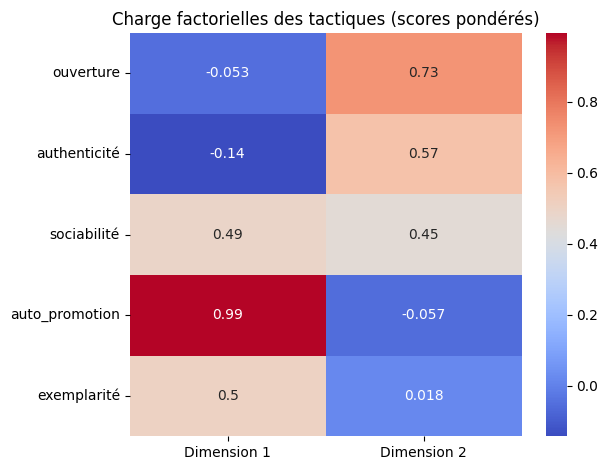

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all_20260430\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,ouverture_y,ouverture_y,authenticité_y,authenticité_y,sociabilité_y,sociabilité_y,auto_promotion_y,auto_promotion_y,exemplarité_y,exemplarité_y
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,0.161147,0.161147,-0.665889,-0.665889,0.980910,0.980910,1.339927,1.339927,0.203598,0.203598
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0.930145,0.930145,0.438044,0.438044,-1.296640,-1.296640,-0.974180,-0.974180,-0.723171,-0.723171
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,1.023326,1.023326,1.203827,1.203827,-0.668133,-0.668133,-0.568512,-0.568512,1.350431,1.350431
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,-0.125047,-0.125047,1.364940,1.364940,-0.258796,-0.258796,-0.936774,-0.936774,-0.637748,-0.637748
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,0.158115,0.158115,-0.610320,-0.610320,0.902967,0.902967,1.719308,1.719308,0.633420,0.633420


[INFO] scores shape (len(data), 1/2*n_factors) :(63085, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 63085, 63085, 63085
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.856336
1,authenticité,0.852067
2,sociabilité,0.876415
3,auto_promotion,0.875476
4,exemplarité,0.920562


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260430\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

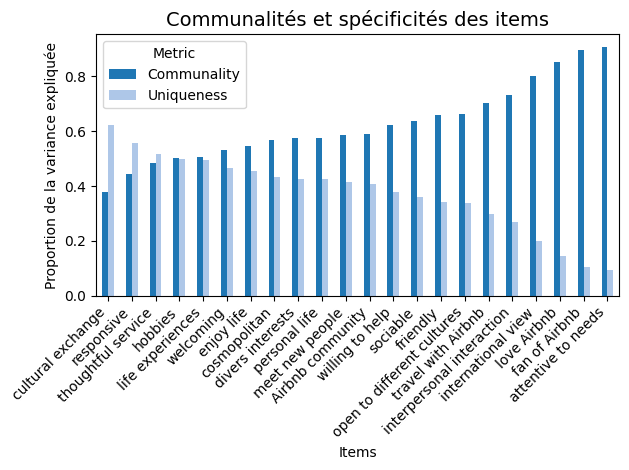

✅ [SAVE] barplot saved to ..\output_fa_all_20260430\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.782001231660038


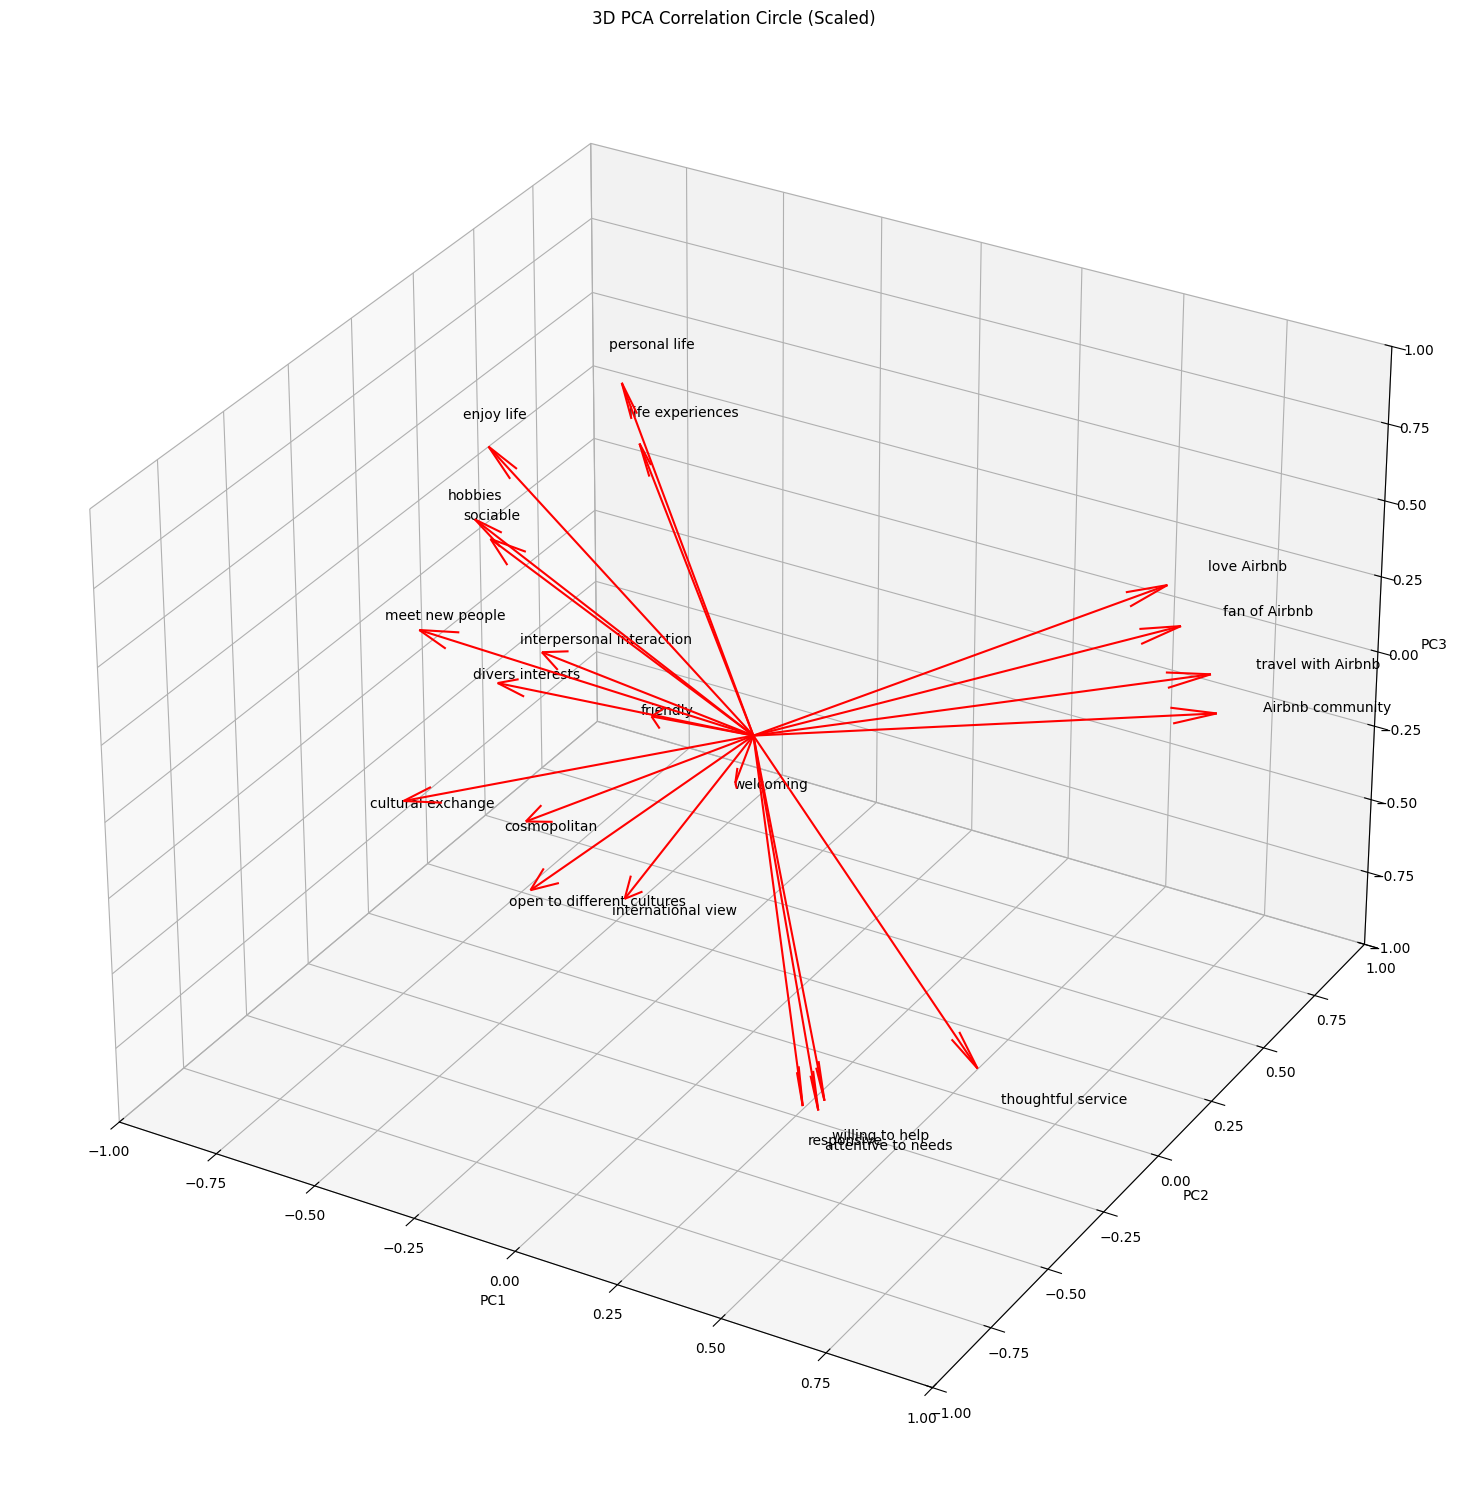

✅ [SAVE] PCA 3D saved to ..\output_fa_all_20260430\pca_3d.jpg!



In [15]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_20260430")
OUTPUT_FOLDER_DATA=Path("../data_processed")


df_zsc=df_zsc.copy()
listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

# 2026-04-26

[INFO] all output saved to '..\output_fa_all_20260426'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:63085 rows!

[INFO] kmo_model score (> 0.7) :0.8753547002171318

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


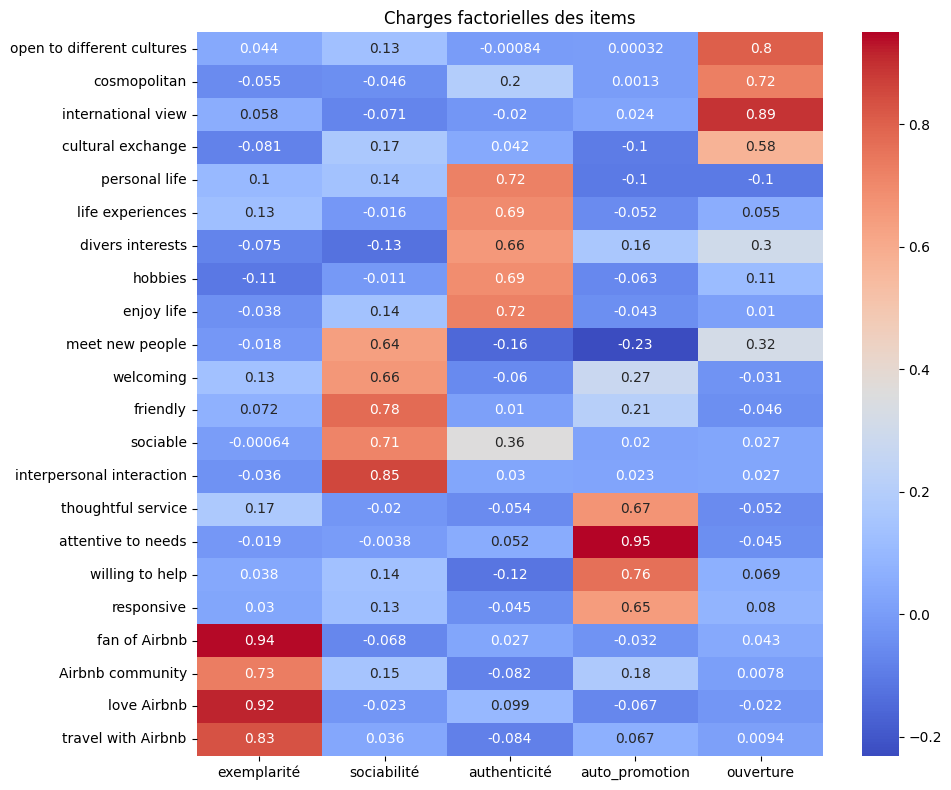

✅ [SAVE] heatmap of items saved to ..\output_fa_all_20260426\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260426\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,gamma,sigma,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.802611,0.130618,0.8026,-,-,-,-,0.663206,0.336794
cosmopolitan,0.724080,0.196402,0.7241,-,-,-,-,0.567967,0.432033
international view,0.890143,0.071136,0.8901,-,-,-,-,0.801756,0.198244
cultural exchange,0.575155,0.166342,0.5752,-,-,-,-,0.376675,0.623325
personal life,0.723293,0.139949,-,0.7233,-,-,-,0.574894,0.425106
life experiences,0.694555,0.127700,-,0.6946,-,-,-,0.504694,0.495306
divers interests,0.658203,0.303246,-,0.6582,-,-,-,0.574083,0.425917
hobbies,0.687668,0.112546,-,0.6877,-,-,-,0.501230,0.498770
enjoy life,0.722141,0.139111,-,0.7221,-,-,-,0.544256,0.455744
meet new people,0.638234,0.316629,-,-,0.6382,-,-,0.586083,0.413917


[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all_20260426\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260426\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(63085, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.052861,0.726418
authenticité,-0.142240,0.572374
sociabilité,0.490147,0.449752
auto_promotion,0.993477,-0.057141
exemplarité,0.501839,0.018273


✅[SAVE] scores df saved to ..\output_fa_all_20260426\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_20260426\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


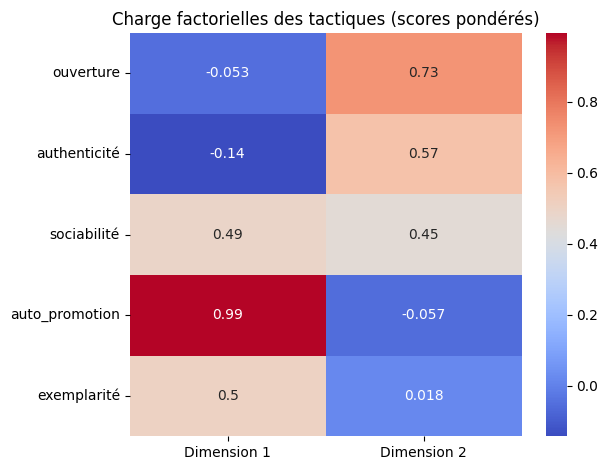

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all_20260426\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,ouverture_y,ouverture_y,authenticité_y,authenticité_y,sociabilité_y,sociabilité_y,auto_promotion_y,auto_promotion_y,exemplarité_y,exemplarité_y
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,0.161147,0.161147,-0.665889,-0.665889,0.980910,0.980910,1.339927,1.339927,0.203598,0.203598
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0.930145,0.930145,0.438044,0.438044,-1.296640,-1.296640,-0.974180,-0.974180,-0.723171,-0.723171
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,1.023326,1.023326,1.203827,1.203827,-0.668133,-0.668133,-0.568512,-0.568512,1.350431,1.350431
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,-0.125047,-0.125047,1.364940,1.364940,-0.258796,-0.258796,-0.936774,-0.936774,-0.637748,-0.637748
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,0.158115,0.158115,-0.610320,-0.610320,0.902967,0.902967,1.719308,1.719308,0.633420,0.633420


[INFO] scores shape (len(data), 1/2*n_factors) :(63085, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 63085, 63085, 63085
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.856336
1,authenticité,0.852067
2,sociabilité,0.876415
3,auto_promotion,0.875476
4,exemplarité,0.920562


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_20260426\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

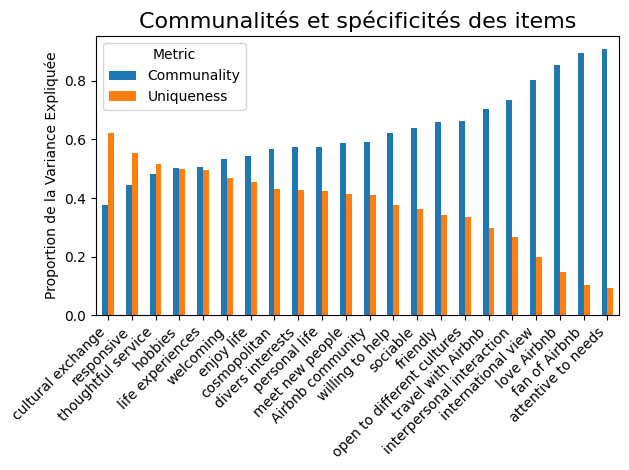

✅ [SAVE] barplot saved to ..\output_fa_all_20260426\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.782001231660038


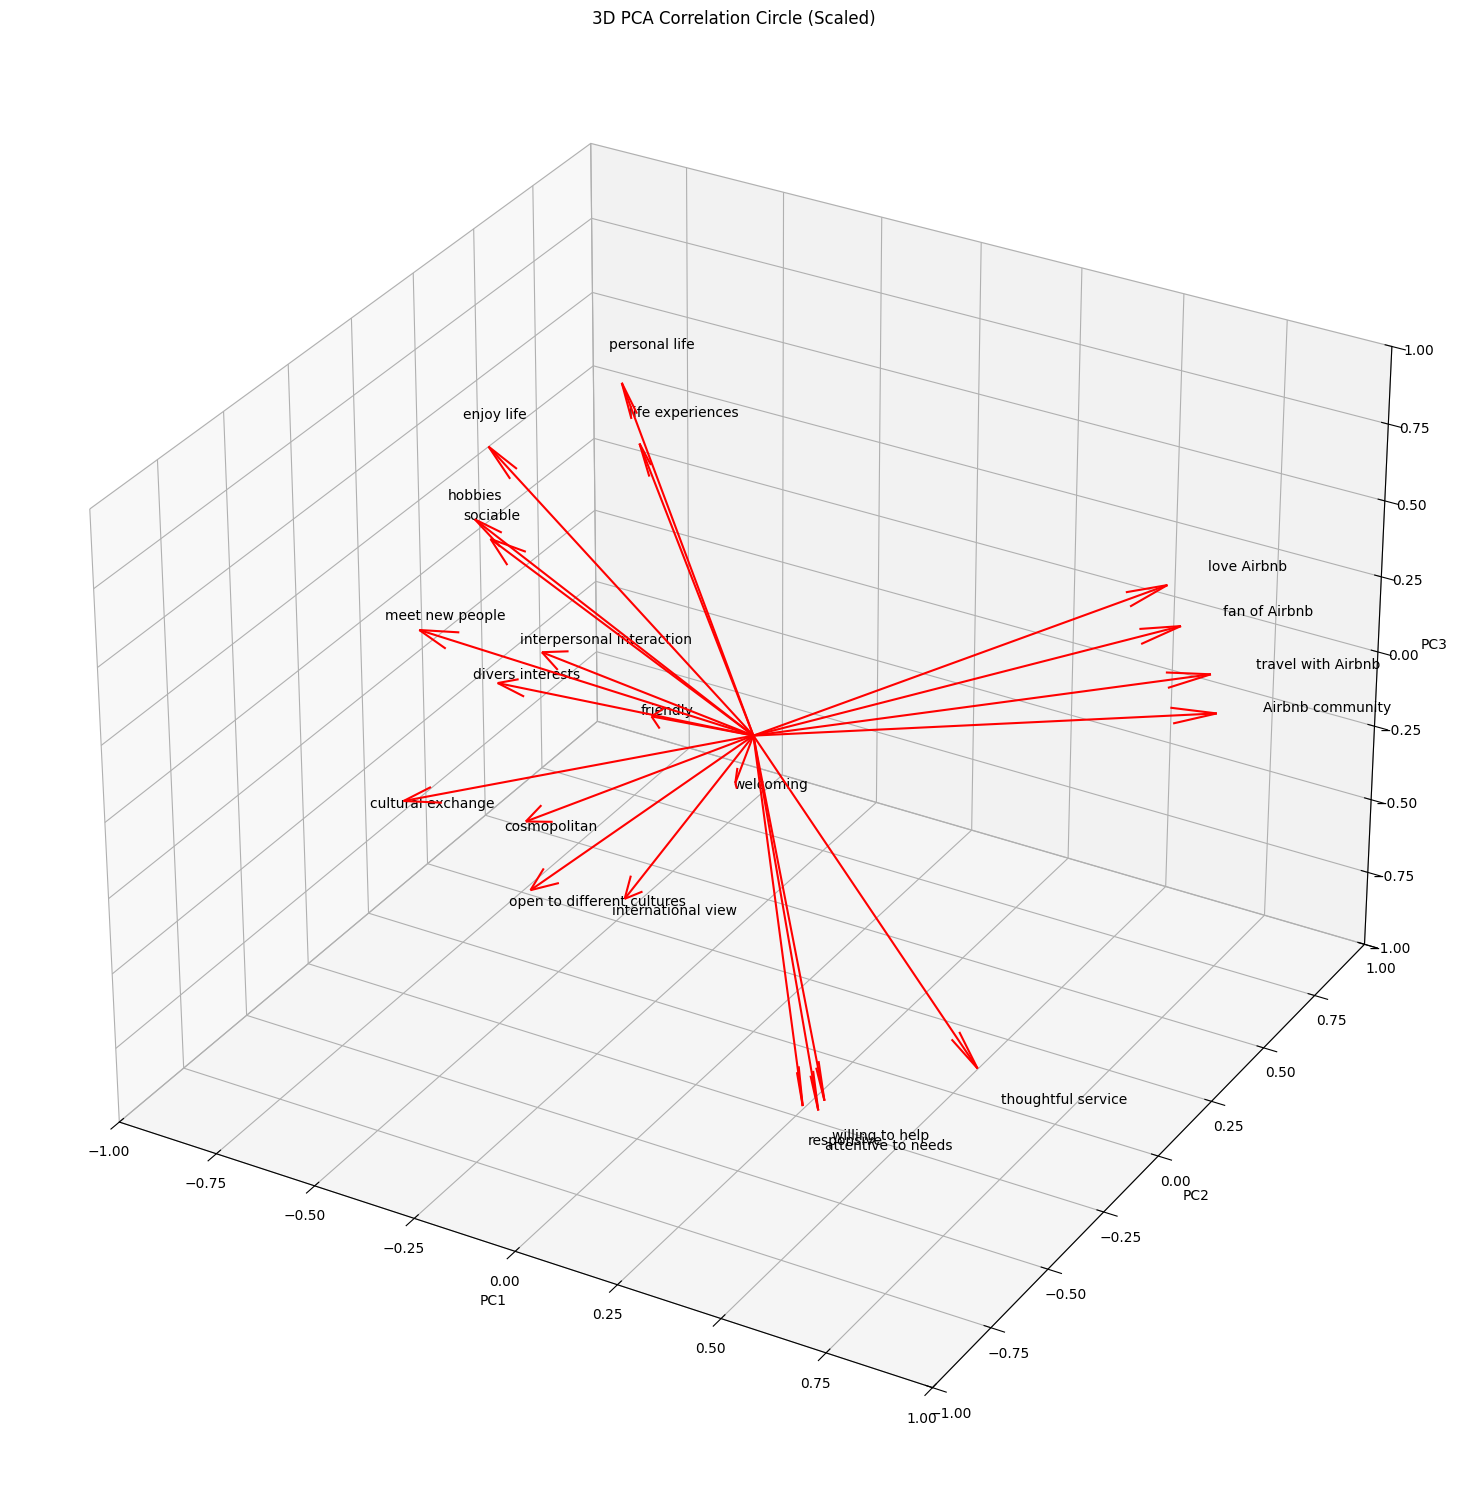

✅ [SAVE] PCA 3D saved to ..\output_fa_all_20260426\pca_3d.jpg!



In [5]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_20260426")
OUTPUT_FOLDER_DATA=Path("../data_processed")


df_zsc=df_zsc.copy()
listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## 2026-04-06

[INFO] all output saved to '..\output_fa_all_3'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 266852 rows; df_items:63085 rows!

[INFO] kmo_model score (> 0.7) :0.8753547002171318

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


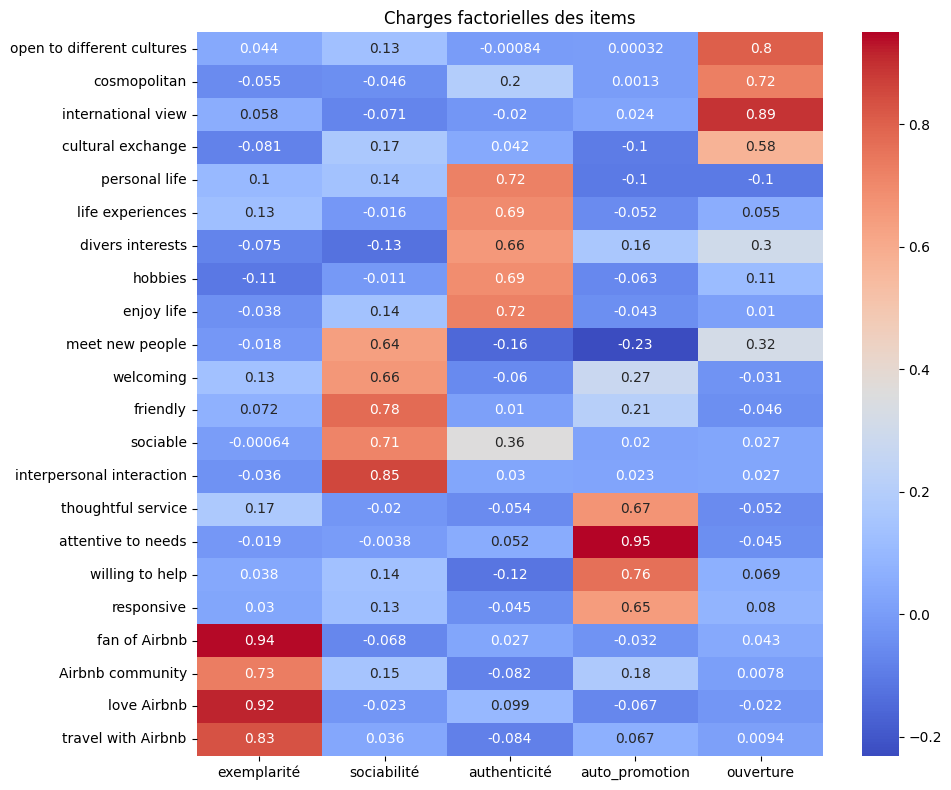

✅ [SAVE] heatmap of items saved to ..\output_fa_all_3\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_3\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,gamma,sigma,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.802611,0.130618,0.8026,-,-,-,-,0.663206,0.336794
cosmopolitan,0.724080,0.196402,0.7241,-,-,-,-,0.567967,0.432033
international view,0.890143,0.071136,0.8901,-,-,-,-,0.801756,0.198244
cultural exchange,0.575155,0.166342,0.5752,-,-,-,-,0.376675,0.623325
personal life,0.723293,0.139949,-,0.7233,-,-,-,0.574894,0.425106
life experiences,0.694555,0.127700,-,0.6946,-,-,-,0.504694,0.495306
divers interests,0.658203,0.303246,-,0.6582,-,-,-,0.574083,0.425917
hobbies,0.687668,0.112546,-,0.6877,-,-,-,0.501230,0.498770
enjoy life,0.722141,0.139111,-,0.7221,-,-,-,0.544256,0.455744
meet new people,0.638234,0.316629,-,-,0.6382,-,-,0.586083,0.413917


[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all_3\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_3\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(63085, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.052861,0.726418
authenticité,-0.142240,0.572374
sociabilité,0.490147,0.449752
auto_promotion,0.993477,-0.057141
exemplarité,0.501839,0.018273


✅[SAVE] scores df saved to ..\output_fa_all_3\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all_3\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


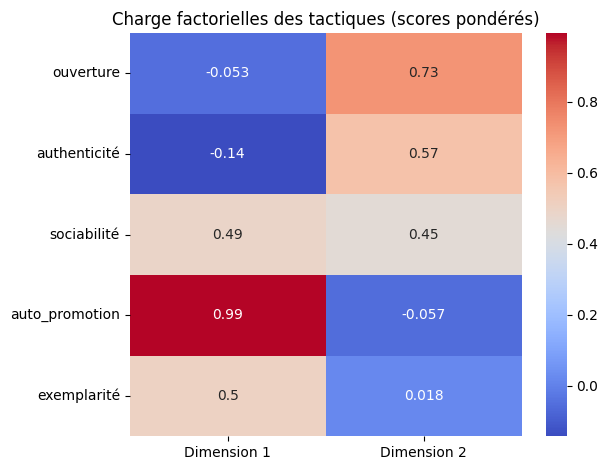

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all_3\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,in_paris,has_text,lang_fr,lang_en,langue,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714.0,https://www.airbnb.com/rooms/157714,2.023061e+13,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377.0,...,0,1,0,1,NaN,0.161147,-0.665889,0.980910,1.339927,0.203598
1,13913.0,https://www.airbnb.com/rooms/13913,2.023061e+13,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730.0,...,0,1,0,1,NaN,0.930145,0.438044,-1.296640,-0.974180,-0.723171
2,15400.0,https://www.airbnb.com/rooms/15400,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302.0,...,0,1,0,1,NaN,1.023326,1.203827,-0.668133,-0.568512,1.350431
3,306333.0,https://www.airbnb.com/rooms/306333,2.023061e+13,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870.0,...,0,1,0,1,NaN,-0.125047,1.364940,-0.258796,-0.936774,-0.637748
4,159736.0,https://www.airbnb.com/rooms/159736,2.023061e+13,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056.0,...,0,1,0,1,NaN,0.158115,-0.610320,0.902967,1.719308,0.633420


[INFO] scores shape (len(data), 1/2*n_factors) :(63085, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 63085, 63085, 63085
len(DF)==len(listings_tactics):266852,266852

✅ [SAVE] 266852 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2312_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.856336
1,authenticité,0.852067
2,sociabilité,0.876415
3,auto_promotion,0.875476
4,exemplarité,0.920562


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all_3\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6253863663812775
[INFO] mean UNIQ : 0.37461363361872235

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

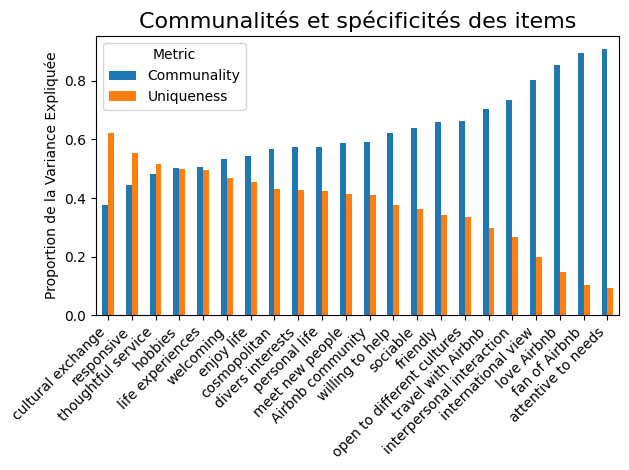

✅ [SAVE] barplot saved to ..\output_fa_all_3\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.782001231660038


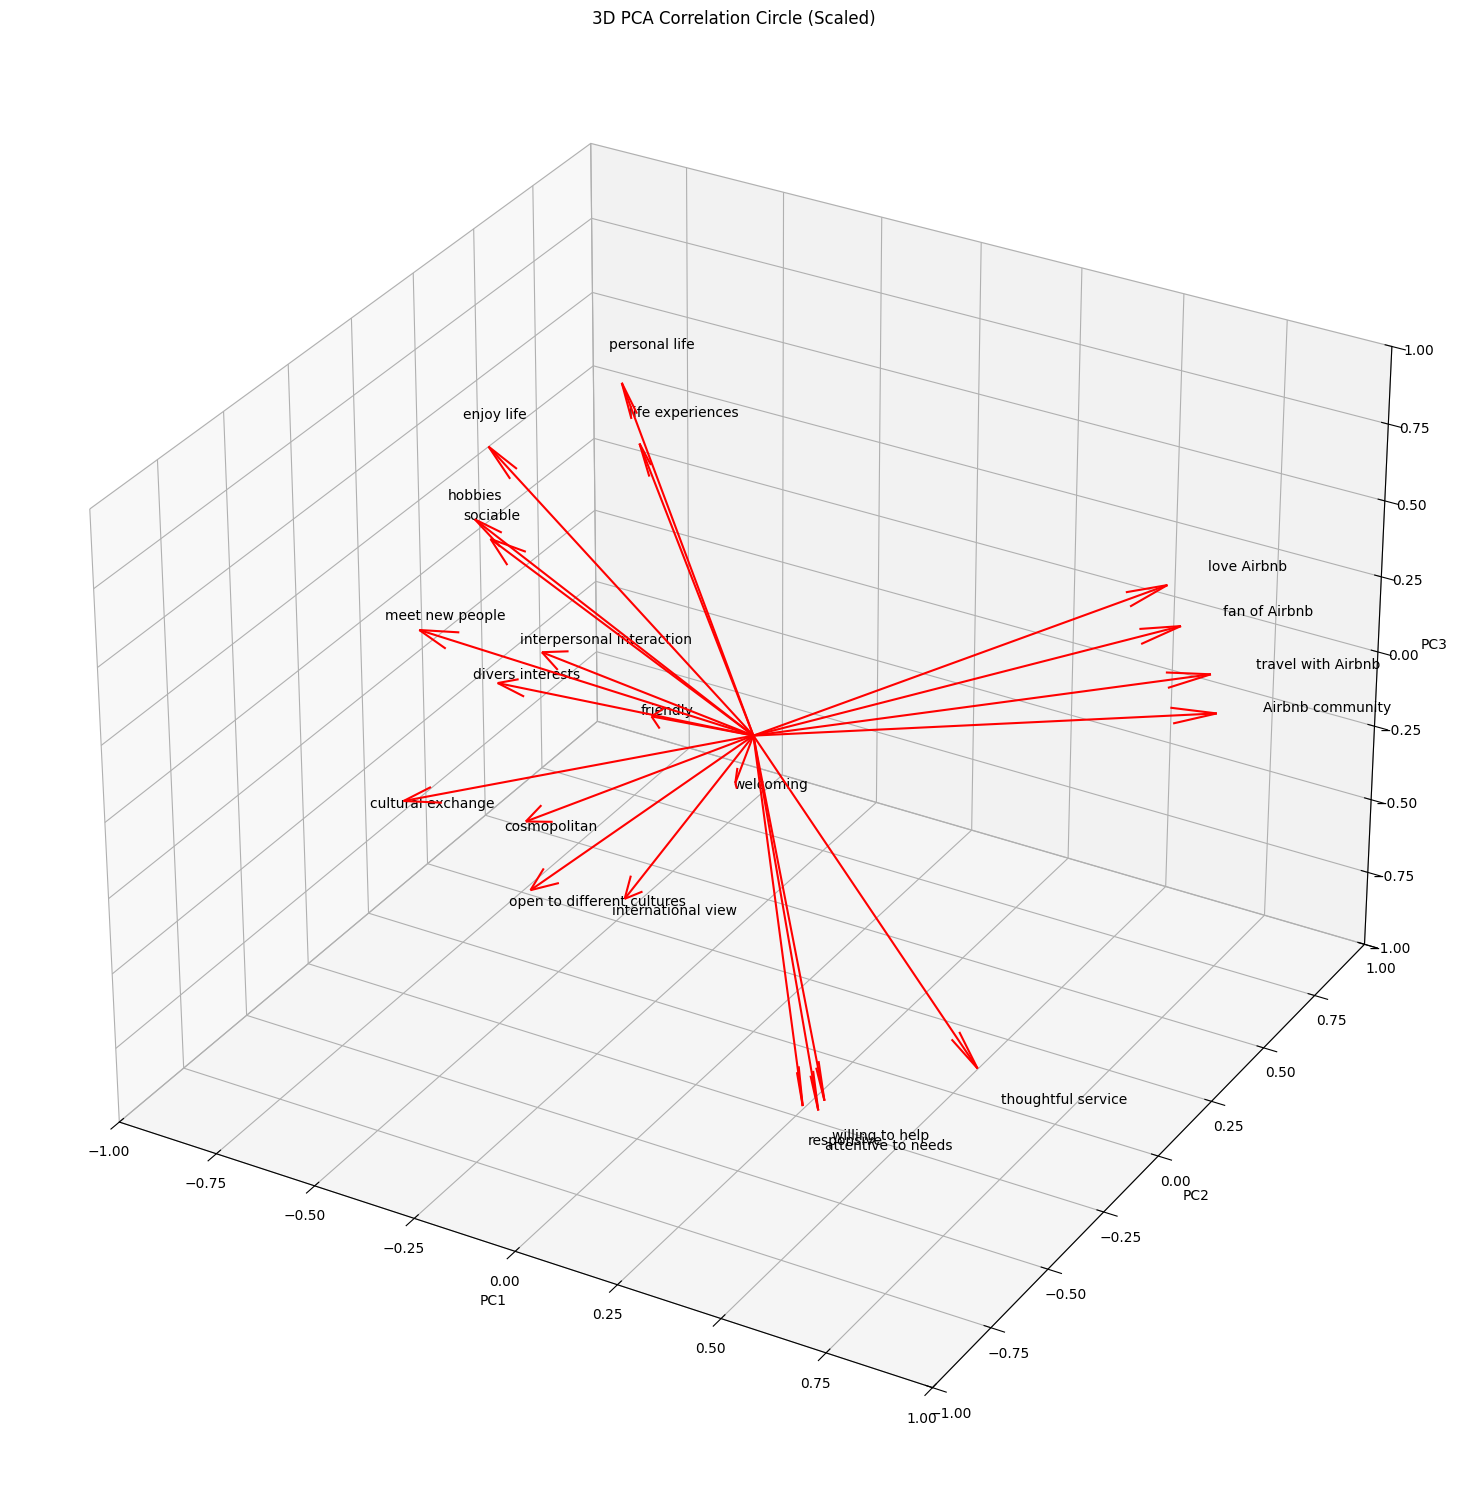

✅ [SAVE] PCA 3D saved to ..\output_fa_all_3\pca_3d.jpg!



In [28]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all_3")
OUTPUT_FOLDER_DATA=Path("../data_processed")


df_zsc=df_all.copy()
listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2312_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## 2026-03-21

[INFO] all output saved to '..\output_fa_all'!
df with fa scores saved to '..\data_processed' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 187851 rows; df_items:47897 rows!



d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[INFO] kmo_model score (> 0.7) :0.8753926287668162

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


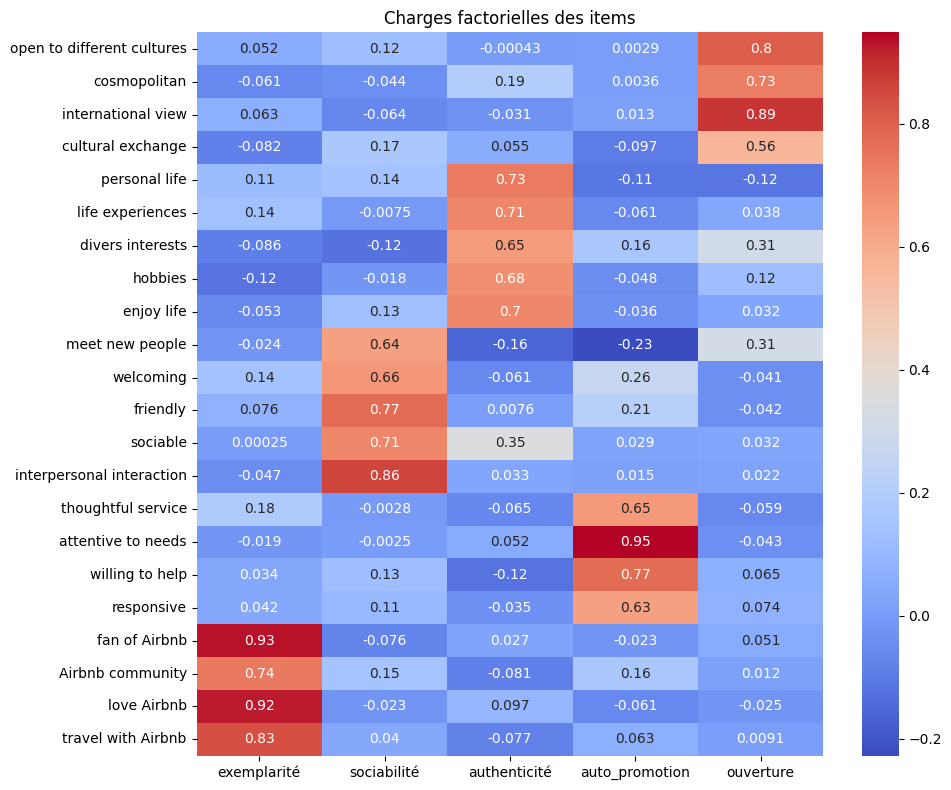

✅ [SAVE] heatmap of items saved to ..\output_fa_all\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,gamma,sigma,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.804298,0.124529,0.8043,-,-,-,-,0.665084,0.334916
cosmopolitan,0.731584,0.192292,0.7316,-,-,-,-,0.577813,0.422187
international view,0.887575,0.064182,0.8876,-,-,-,-,0.796986,0.203014
cultural exchange,0.562750,0.171479,0.5628,-,-,-,-,0.365324,0.634676
personal life,0.733908,0.141749,-,0.7339,-,-,-,0.597412,0.402588
life experiences,0.705555,0.138370,-,0.7056,-,-,-,0.522087,0.477913
divers interests,0.647982,0.309659,-,0.648,-,-,-,0.565344,0.434656
hobbies,0.684862,0.122941,-,0.6849,-,-,-,0.501071,0.498929
enjoy life,0.704564,0.130415,-,0.7046,-,-,-,0.518632,0.481368
meet new people,0.635647,0.314998,-,-,0.6356,-,-,0.580638,0.419362


[INFO] mean COMM (> 0.6):0.6235967652727176
[INFO] mean UNIQ : 0.3764032347272824

[WARNING] 3/22 low communality items (< 0.5):
cultural exchange;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_all\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(47897, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.063905,0.706891
authenticité,-0.138188,0.570419
sociabilité,0.494276,0.452539
auto_promotion,0.991483,-0.057213
exemplarité,0.510797,0.001664


✅[SAVE] scores df saved to ..\output_fa_all\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_all\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


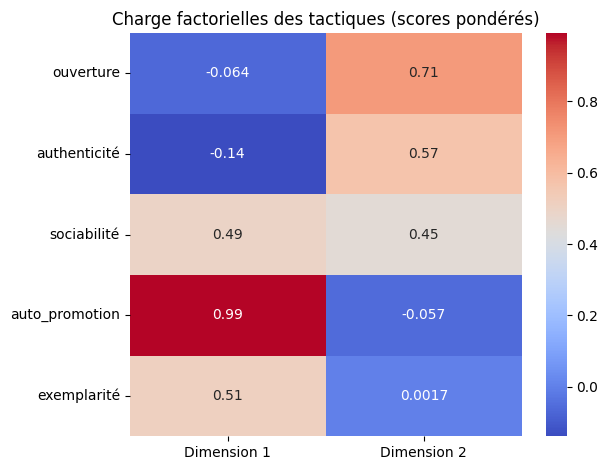

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_all\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,Airbnb community,love Airbnb,travel with Airbnb,is_paris,in_2024,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,157714,https://www.airbnb.com/rooms/157714,20230608145305,2023-06-09,city scrape,Townhouse in Hammersmith · ★4.71 · 1 bedroom ·...,"Large, light and spacious loft bedroom with a ...",The neighbourhood is extremely convenient for ...,https://a0.muscache.com/pictures/4129744/10db5...,757377,...,0.875308,0.044266,0.261850,0,0,0.163545,-0.676712,0.986720,1.352565,0.196903
1,13913,https://www.airbnb.com/rooms/13913,20230608145305,2023-06-09,city scrape,Rental unit in Islington · ★4.80 · 1 bedroom ·...,My bright double bedroom with a large window h...,Finsbury Park is a friendly melting pot commun...,https://a0.muscache.com/pictures/miso/Hosting-...,54730,...,0.001167,0.002715,0.000665,0,0,0.972676,0.380712,-1.326076,-0.971294,-0.740246
2,15400,https://www.airbnb.com/rooms/15400,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.80 · 1 bedroom · 1 ...,Lots of windows and light. St Luke's Gardens ...,It is Chelsea.,https://a0.muscache.com/pictures/428392/462d26...,60302,...,0.826011,0.653901,0.381752,0,0,1.044898,1.190367,-0.679518,-0.597984,1.322457
3,306333,https://www.airbnb.com/rooms/306333,20230608145305,2023-06-09,city scrape,Rental unit in London · ★4.32 · 2 bedrooms · 3...,Welcome to my lovely 2-bedroom flat in Hoxton!...,"In Shoreditch, empty walls are future murals. ...",https://a0.muscache.com/pictures/32c818d1-7762...,1573870,...,0.026131,0.005764,0.002526,0,0,-0.090556,1.360775,-0.270853,-0.949191,-0.652790
4,159736,https://www.airbnb.com/rooms/159736,20230608145305,2023-06-09,city scrape,Rental unit in Lambeth · ★4.72 · 1 bedroom · 1...,Calm sunny double room with a queen size bed a...,We love that in Loughborough Junction we live ...,https://a0.muscache.com/pictures/1067303/d2300...,766056,...,0.809953,0.106412,0.768863,0,0,0.177260,-0.626426,0.909219,1.720586,0.632008


[INFO] scores shape (len(data), 1/2*n_factors) :(47897, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 47897, 47897, 47897
len(DF)==len(listings_tactics):187851,187851

✅ [SAVE] 187851 listings with tactics scores by 'weighted' way saved to ..\data_processed\listings_tactics-paris_london-2306_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.854966
1,authenticité,0.850205
2,sociabilité,0.874126
3,auto_promotion,0.871835
4,exemplarité,0.923832


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_all\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6235967652727176
[INFO] mean UNIQ : 0.3764032347272824



<Figure size 1000x600 with 0 Axes>

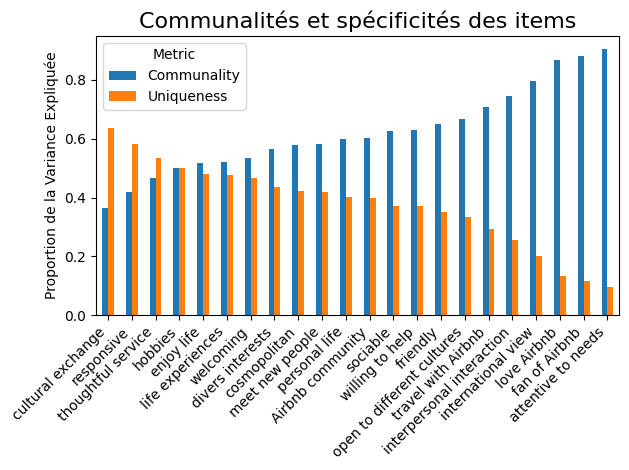

✅ [SAVE] barplot saved to ..\output_fa_all\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7824773113962931


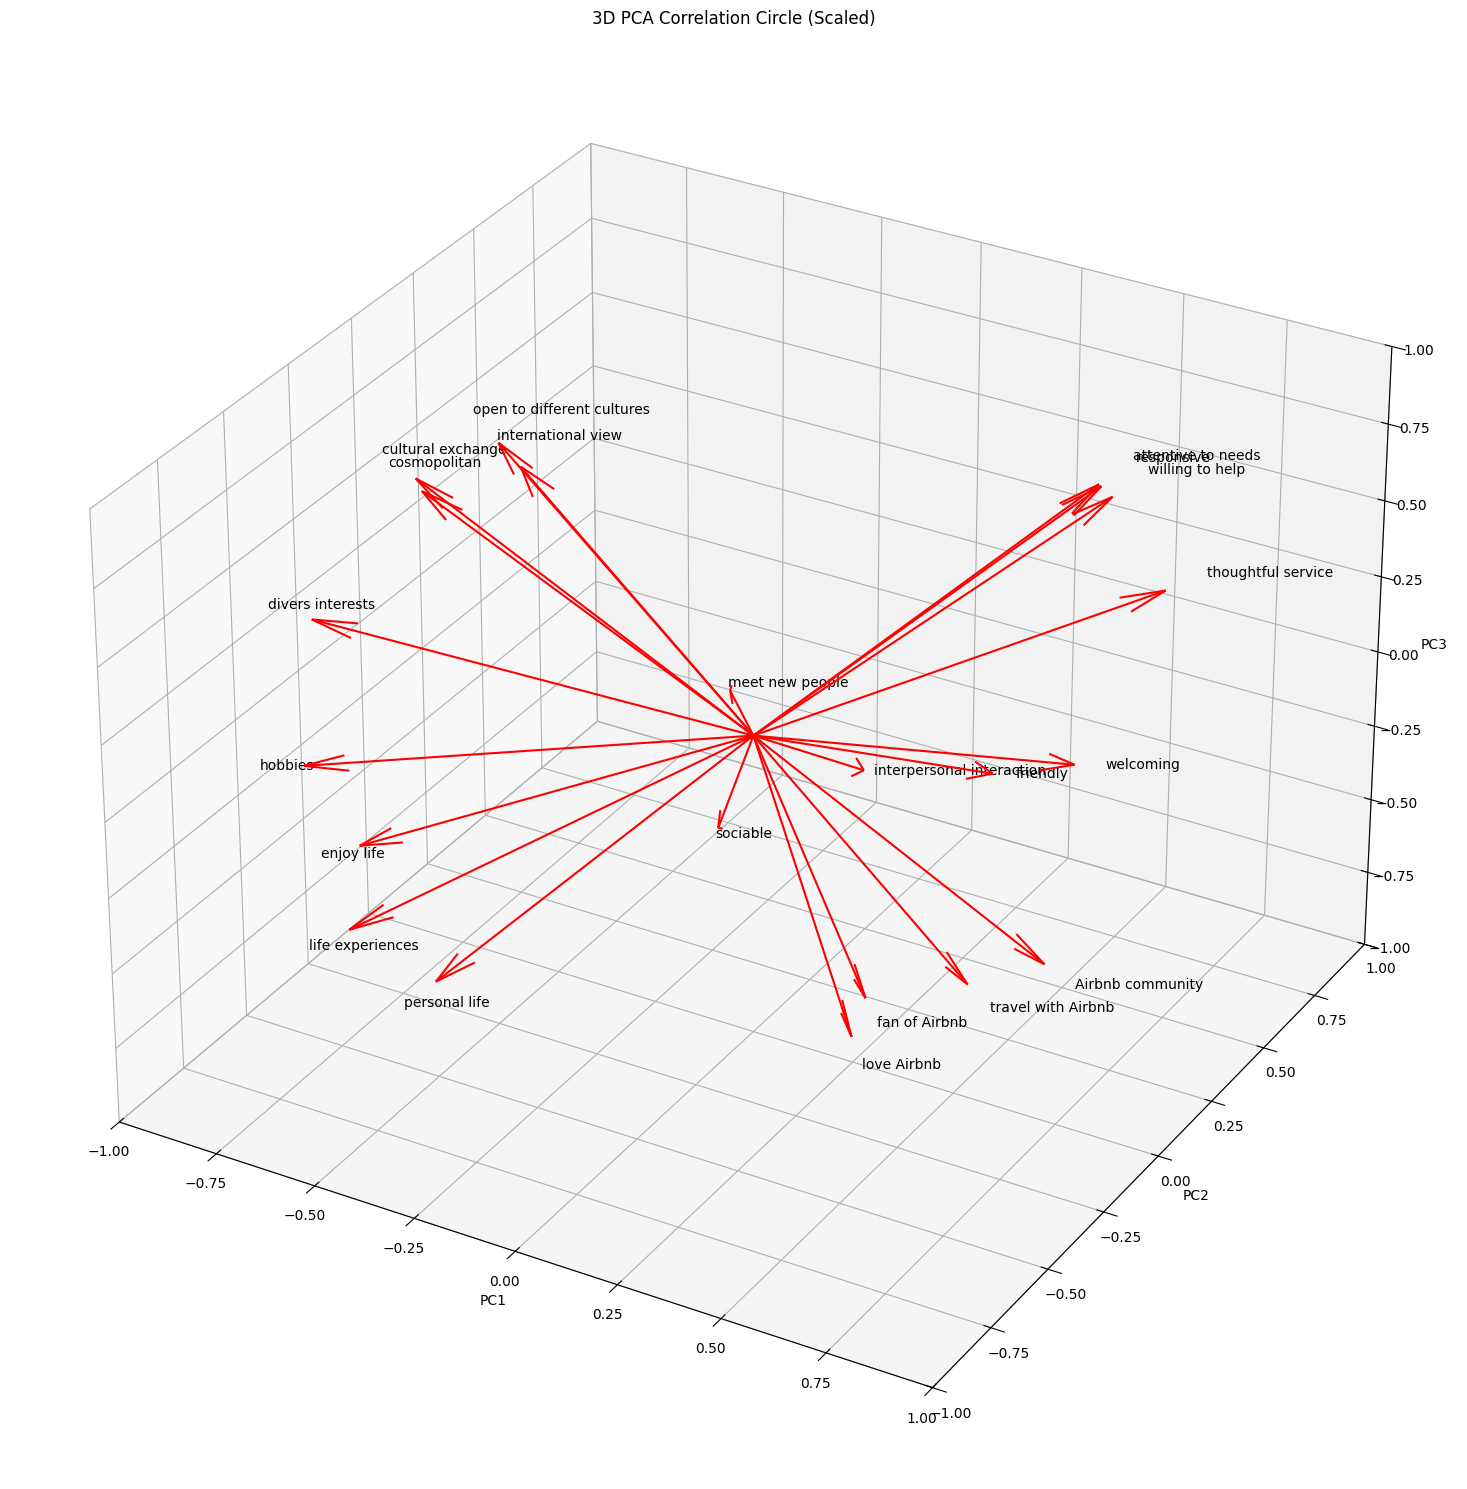

✅ [SAVE] PCA 3D saved to ..\output_fa_all\pca_3d.jpg!



In [ ]:
## 21/03/26

importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa_all")
OUTPUT_FOLDER_DATA=Path("../data_processed")

listings_tactics=run_fa(df_zsc=df_zsc, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER_DATA,filename="listings_tactics-paris_london-2306_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","authenticité","auto_promotion","ouverture"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## fa: paris_2024


(62738, 107)
[INFO] all output saved to '..\output_fa-paris_2024'!
df with fa scores saved to '..\output_fa-paris_2024' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 62738 rows; df_items:15570 rows!

[INFO] kmo_model score (> 0.7) :0.8766107914187657

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


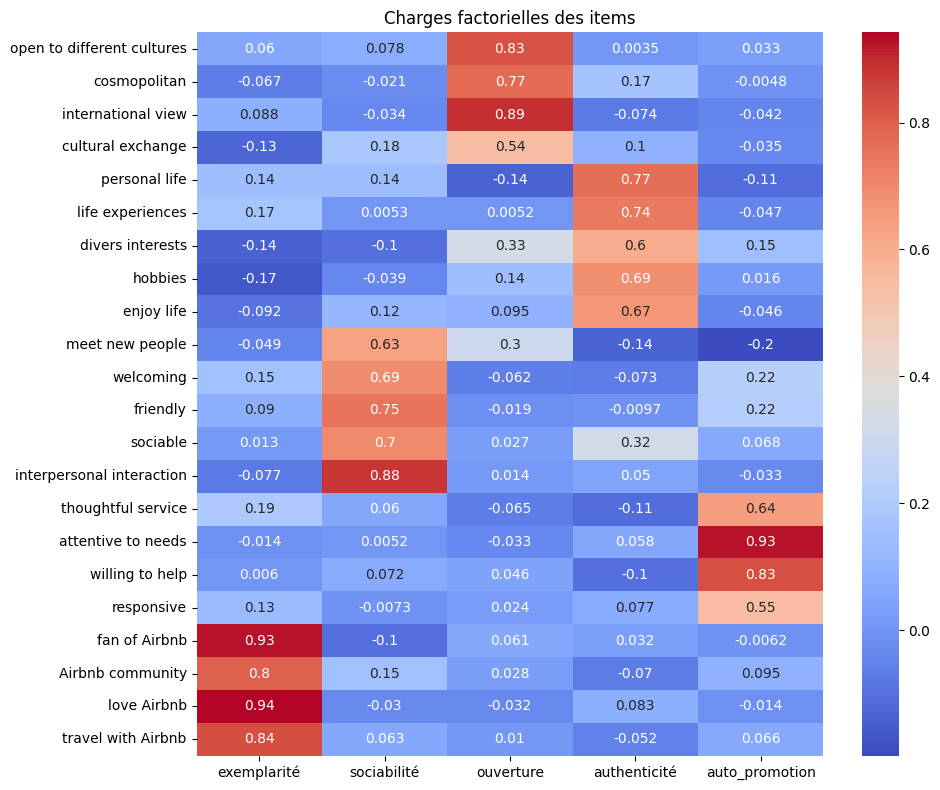

✅ [SAVE] heatmap of items saved to ..\output_fa-paris_2024\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2024\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,gamma,sigma,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.827804,0.078222,0.8278,-,-,-,-,0.696021,0.303979
cosmopolitan,0.773317,0.166429,0.7733,-,-,-,-,0.630669,0.369331
international view,0.891588,0.087980,0.8916,-,-,-,-,0.811079,0.188921
cultural exchange,0.544773,0.177011,0.5448,-,-,-,-,0.356388,0.643612
personal life,0.765598,0.144659,-,0.7656,-,-,-,0.657700,0.342300
life experiences,0.741609,0.168919,-,0.7416,-,-,-,0.580746,0.419254
divers interests,0.602511,0.331011,-,0.6025,-,-,-,0.525215,0.474785
hobbies,0.686967,0.171039,-,0.687,-,-,-,0.523420,0.476580
enjoy life,0.665064,0.116145,-,0.6651,-,-,-,0.475368,0.524632
meet new people,0.633582,0.304320,-,-,0.6336,-,-,0.554867,0.445133


[INFO] mean COMM (> 0.6):0.6312659999863206
[INFO] mean UNIQ : 0.3687340000136793

[WARNING] 4/22 low communality items (< 0.5):
cultural exchange;enjoy life;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa-paris_2024\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2024\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(15570, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.133550,0.662580
authenticité,-0.082673,0.533570
sociabilité,0.477171,0.472538
auto_promotion,0.994171,-0.034890
exemplarité,0.570134,-0.090004


✅[SAVE] scores df saved to ..\output_fa-paris_2024\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2024\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


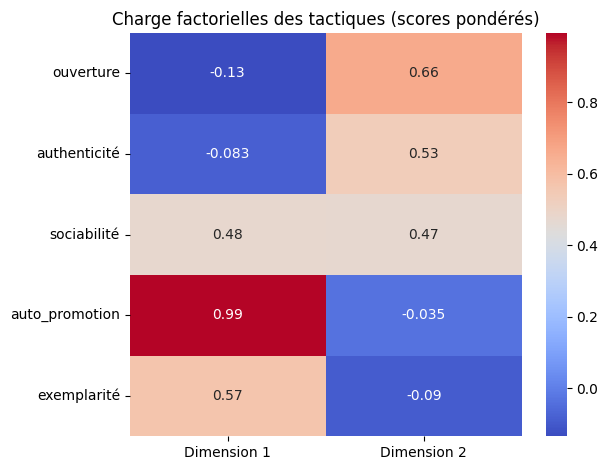

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa-paris_2024\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.643927,-1.255179,0.352712,0.789458,-0.596828
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.478371,-0.338809,0.848154,1.743024,0.389532
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.117414,-1.202431,-2.045390,-1.195575,-0.720234
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.869602,0.854419,0.498955,-1.342024,-0.699535


[INFO] scores shape (len(data), 1/2*n_factors) :(15570, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 15570, 15570, 15570
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] 62738 listings with tactics scores by 'weighted' way saved to ..\output_fa-paris_2024\listings_tactics-paris_2406.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.860530
1,authenticité,0.846247
2,sociabilité,0.870938
3,auto_promotion,0.861229
4,exemplarité,0.940113


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa-paris_2024\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6312659999863206
[INFO] mean UNIQ : 0.3687340000136793

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

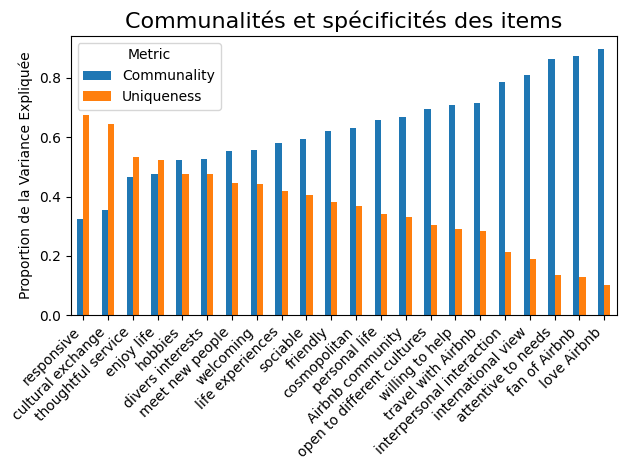

✅ [SAVE] barplot saved to ..\output_fa-paris_2024\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7816195095197302


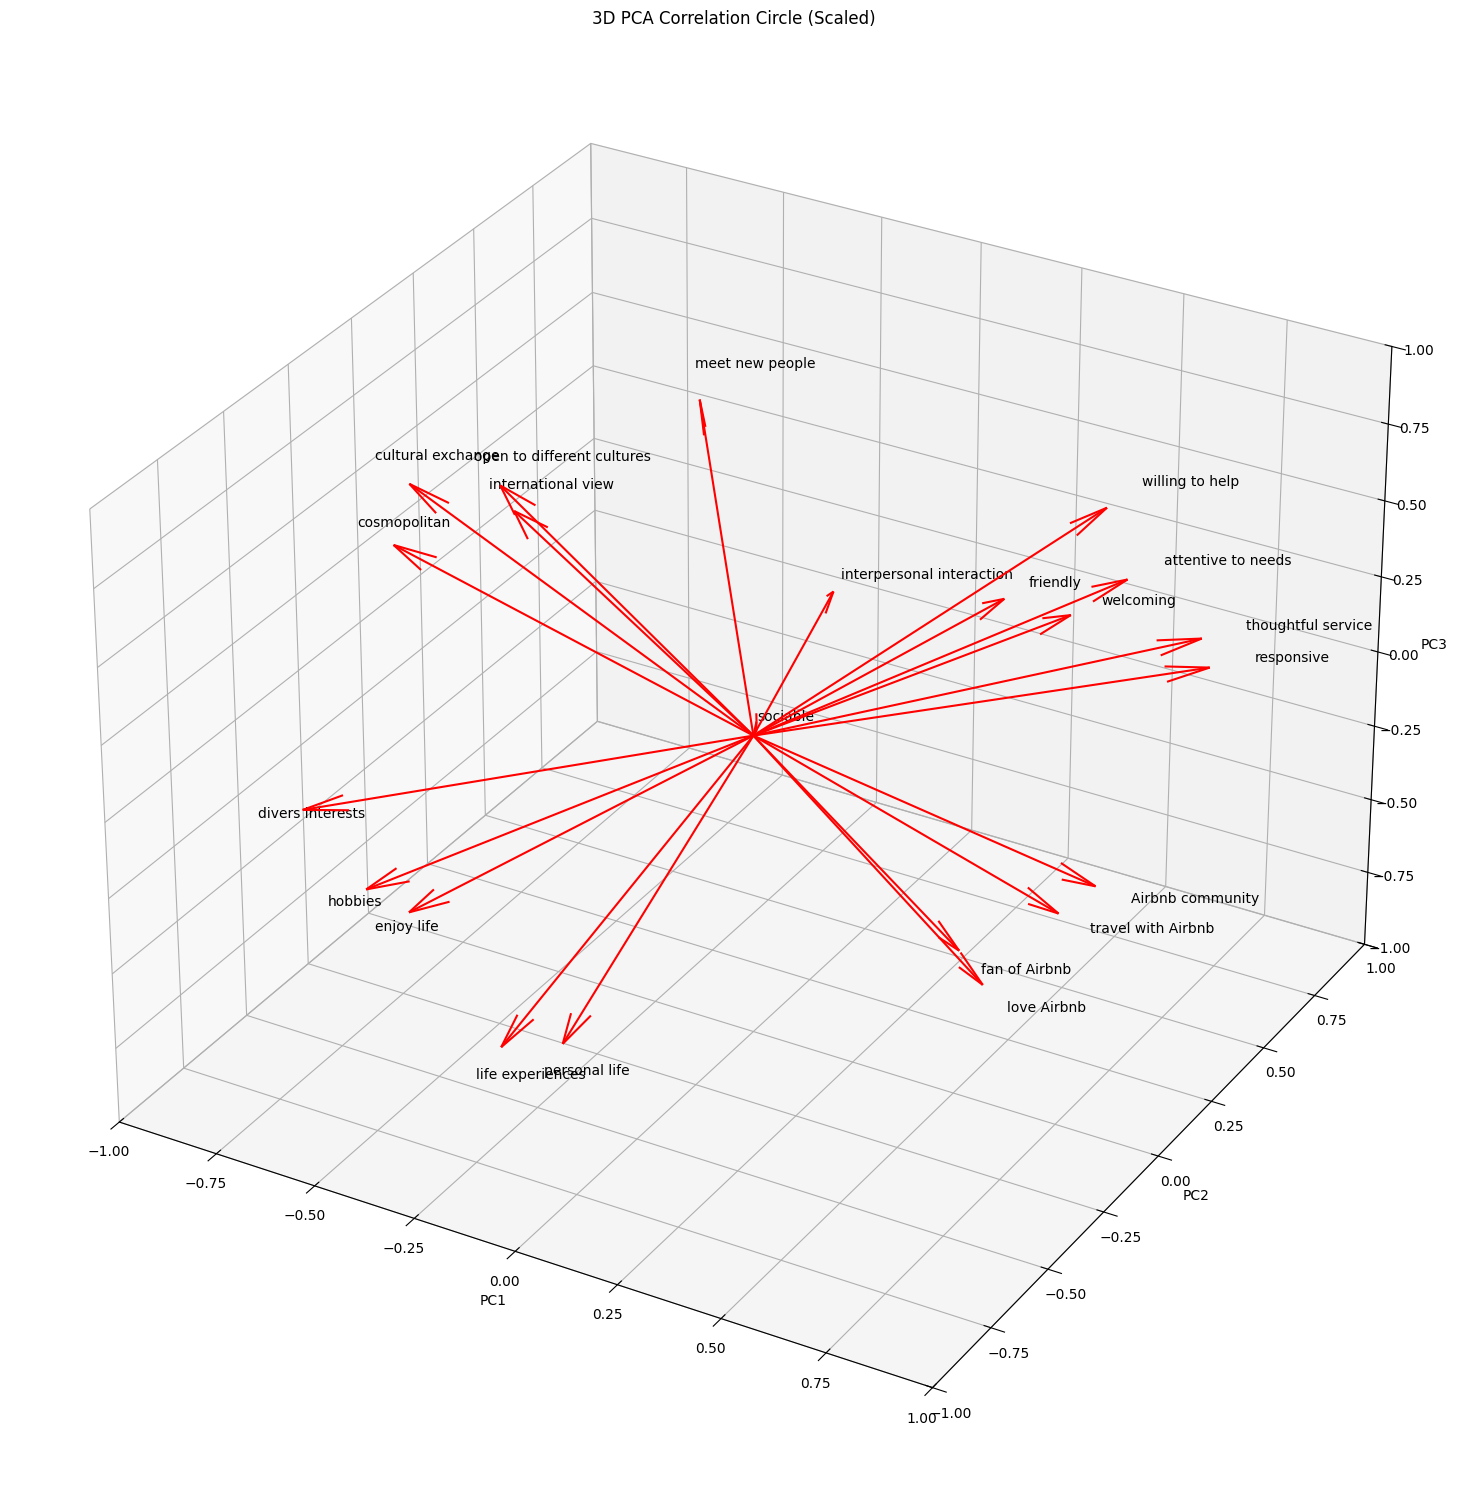

✅ [SAVE] PCA 3D saved to ..\output_fa-paris_2024\pca_3d.jpg!



In [6]:
## 02/04/26
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa-paris_2024")
OUTPUT_FOLDER_DATA=Path("../data_processed")
df_zsc_paris_2024=pd.read_csv("../data_processed\paris_2406\listings_zsc_paris_2406.csv")
print(df_zsc_paris_2024.shape)

listings_tactics=run_fa(df_zsc=df_zsc_paris_2024, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER,# **
    filename="listings_tactics-paris_2406.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","ouverture","authenticité","auto_promotion"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

## fa: paris_2023

C:\Users\yeliu\AppData\Local\Temp\ipykernel_30716\2140341038.py:6: DtypeWarning: Columns (59,60) have mixed types. Specify dtype option on import or set low_memory=False.
  df_zsc_paris_2023=pd.read_csv("../data_processed\paris_2306\listings_zsc_paris_2306.csv")
d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


(32901, 108)
[INFO] all output saved to '..\output_fa-paris_2023'!
df with fa scores saved to '..\output_fa-paris_2023' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!

============================RUN FA=================================
[info] df_zsc: 62738 rows; df_items:15570 rows!

[INFO] kmo_model score (> 0.7) :0.8766107914187657

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


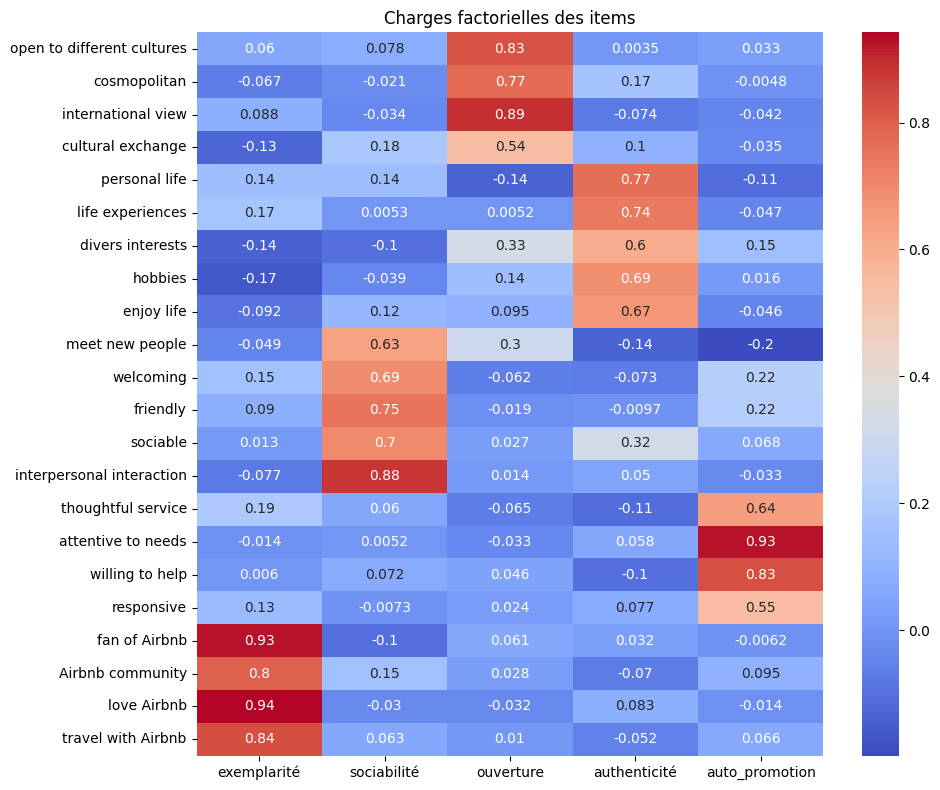

✅ [SAVE] heatmap of items saved to ..\output_fa-paris_2023\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2023\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:172: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  
d:\Edu\SelfPre

,gamma,sigma,ouverture,authenticité,sociabilité,auto_promotion,exemplarité,communalité,spécificité
open to different cultures,0.827804,0.078222,0.8278,-,-,-,-,0.696021,0.303979
cosmopolitan,0.773317,0.166429,0.7733,-,-,-,-,0.630669,0.369331
international view,0.891588,0.087980,0.8916,-,-,-,-,0.811079,0.188921
cultural exchange,0.544773,0.177011,0.5448,-,-,-,-,0.356388,0.643612
personal life,0.765598,0.144659,-,0.7656,-,-,-,0.657700,0.342300
life experiences,0.741609,0.168919,-,0.7416,-,-,-,0.580746,0.419254
divers interests,0.602511,0.331011,-,0.6025,-,-,-,0.525215,0.474785
hobbies,0.686967,0.171039,-,0.687,-,-,-,0.523420,0.476580
enjoy life,0.665064,0.116145,-,0.6651,-,-,-,0.475368,0.524632
meet new people,0.633582,0.304320,-,-,0.6336,-,-,0.554867,0.445133


[INFO] mean COMM (> 0.6):0.6312659999863206
[INFO] mean UNIQ : 0.3687340000136793

[WARNING] 4/22 low communality items (< 0.5):
cultural exchange;enjoy life;thoughtful service;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa-paris_2023\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2023\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(15570, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,Dimension 1,Dimension 2
ouverture,-0.133550,0.662580
authenticité,-0.082673,0.533570
sociabilité,0.477171,0.472538
auto_promotion,0.994171,-0.034890
exemplarité,0.570134,-0.090004


✅[SAVE] scores df saved to ..\output_fa-paris_2023\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa-paris_2023\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


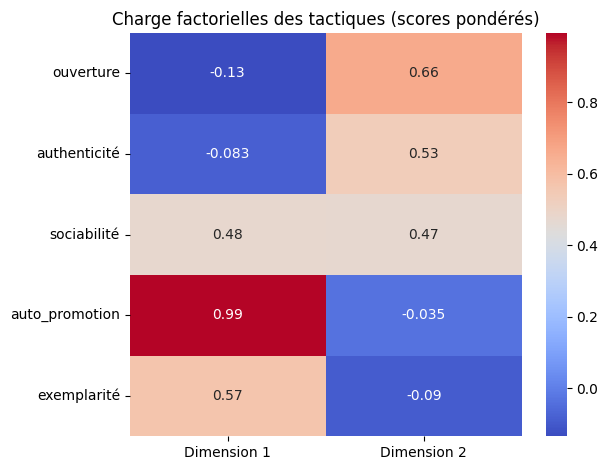

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa-paris_2023\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.643927,-1.255179,0.352712,0.789458,-0.596828
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.478371,-0.338809,0.848154,1.743024,0.389532
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.117414,-1.202431,-2.045390,-1.195575,-0.720234
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.869602,0.854419,0.498955,-1.342024,-0.699535


[INFO] scores shape (len(data), 1/2*n_factors) :(15570, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 15570, 15570, 15570
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] 62738 listings with tactics scores by 'weighted' way saved to ..\output_fa-paris_2023\listings_tactics-paris_2306.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.860530
1,authenticité,0.846247
2,sociabilité,0.870938
3,auto_promotion,0.861229
4,exemplarité,0.940113


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa-paris_2023\cronbachs_alpha.csv!


-----------------------------barplot comm&uniq-------------------------------
[info] good communality (h²) : > 0.3; specificity=1-communality
[INFO] mean COMM (> 0.6):0.6312659999863206
[INFO] mean UNIQ : 0.3687340000136793

[info] good item:gamma > 0.5 + sigma < 0.3


<Figure size 1000x600 with 0 Axes>

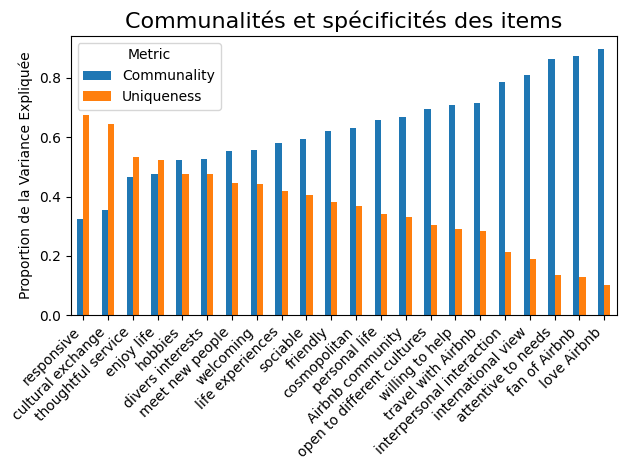

✅ [SAVE] barplot saved to ..\output_fa-paris_2023\comm_uniq_barplot.jpg!

# -----------------------------3D PCA-------------------------------
[INFO] Explained variance ratios 3D (>0.6): 0.7816195095197302


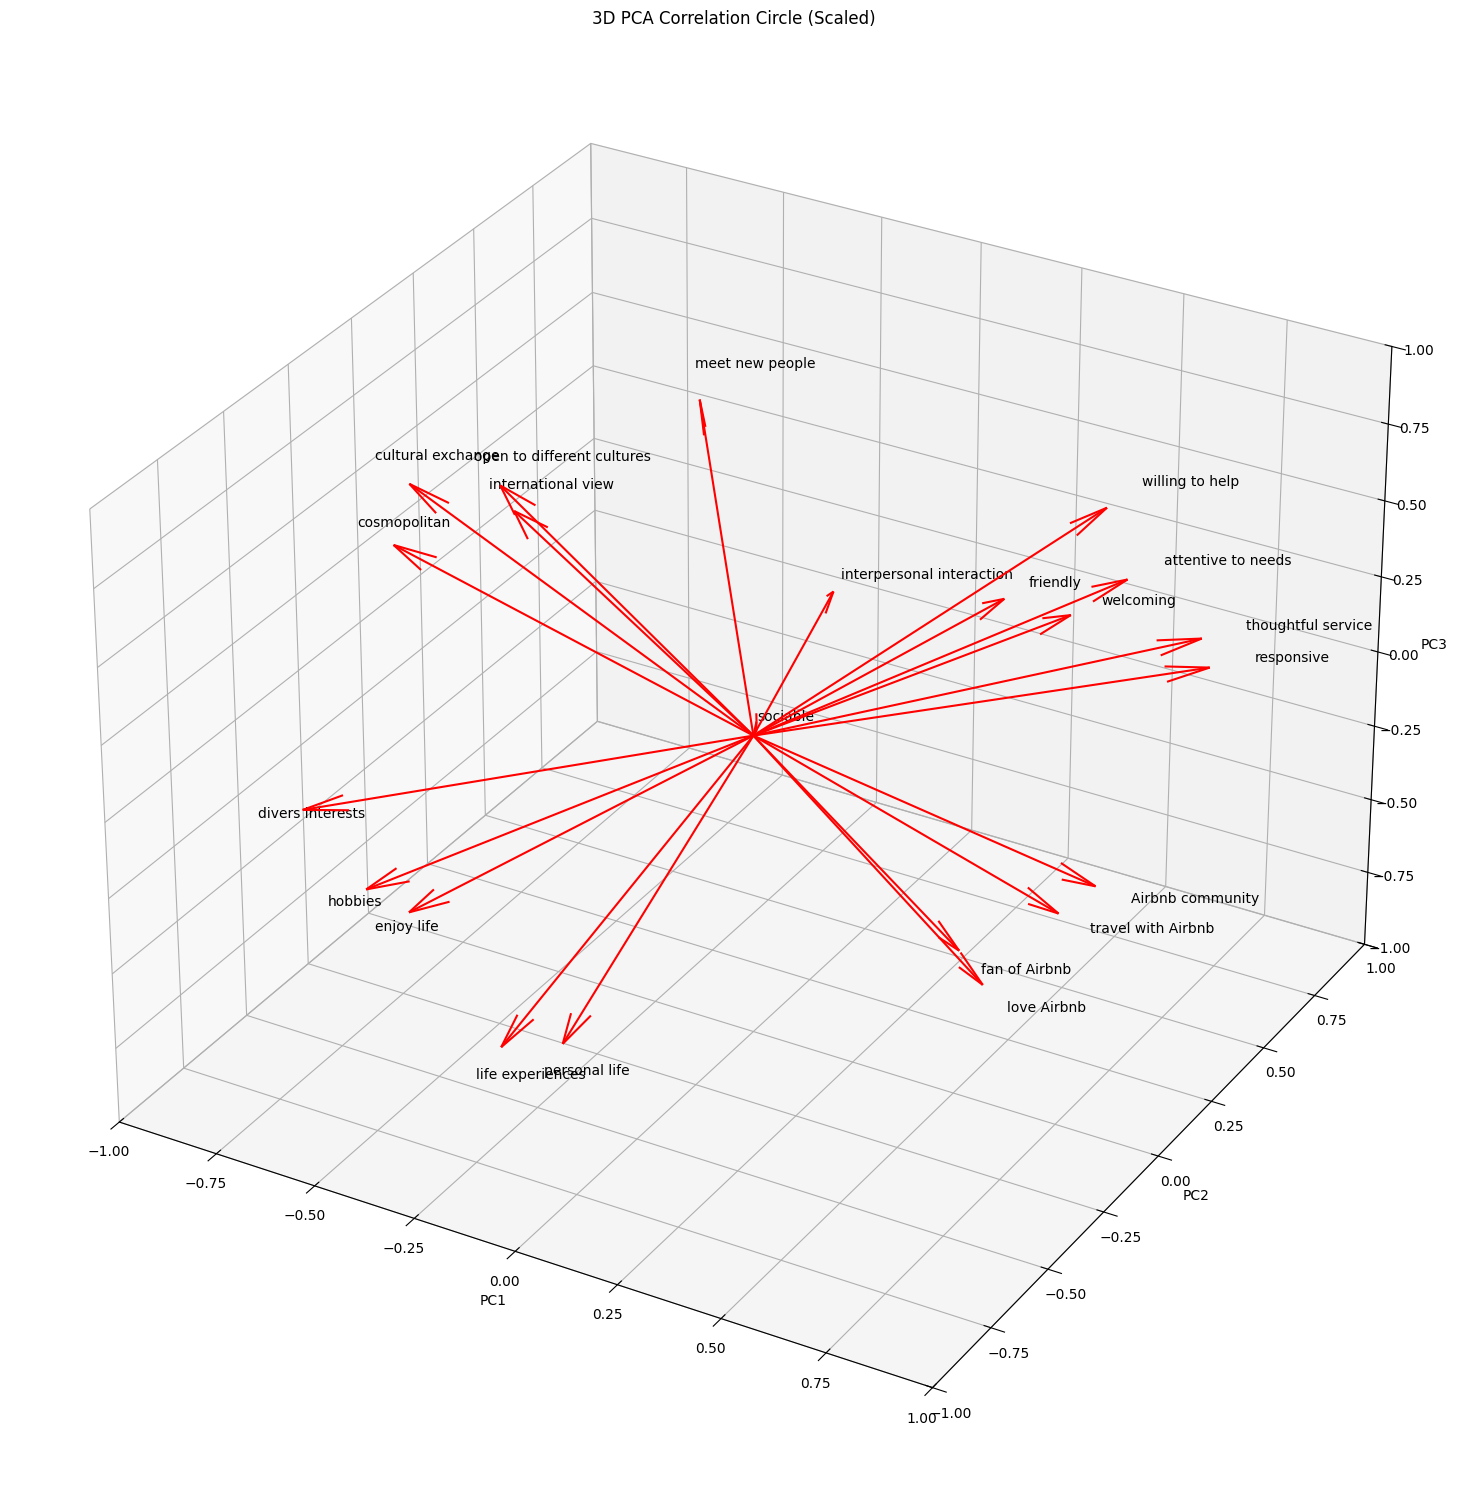

✅ [SAVE] PCA 3D saved to ..\output_fa-paris_2023\pca_3d.jpg!



In [ ]:
importlib.reload(fa)
from utils.fa import run_fa

OUTPUT_FOLDER=Path("../output_fa/output_fa-paris_2023")
OUTPUT_FOLDER_DATA=Path("../data_processed")
df_zsc_paris_2023=pd.read_csv("../data_processed\paris_2306\listings_zsc_paris_2306.csv")
print(df_zsc_paris_2023.shape)

listings_tactics=run_fa(df_zsc=df_zsc_paris_2024, items=LABELS_EN, 
    output_folder=OUTPUT_FOLDER,
    output_folder_data=OUTPUT_FOLDER,# **
    filename="listings_tactics-paris_2306.csv",
    
    n_factors=5, rotation="oblimin",
    fa_names=["exemplarité","sociabilité","ouverture","authenticité","auto_promotion"],#check order!!
    dict_factor_items=DICT_FACTOR_ITEMS,
    get_items_heatmap=True,
    get_items_table=True, low_comm_t=0.5,
    get_factor_scores_by='weighted',
    run_fa_on_scores="weighted",
    get_scores_heatmap=True,
    get_cronbachs_a=True,
    get_barplot=True, get_pca3d=True, 
    ndigits=4)

# test

d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:38: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df_items)


[INFO] df_items : 62738 rows!
[INFO] all output saved to '..\output_fa_paris'!
df with fa scores saved to '..\data_processed_paris' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26659

[INFO] kmo_model score (> 0.7) :0.8708486940515002

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


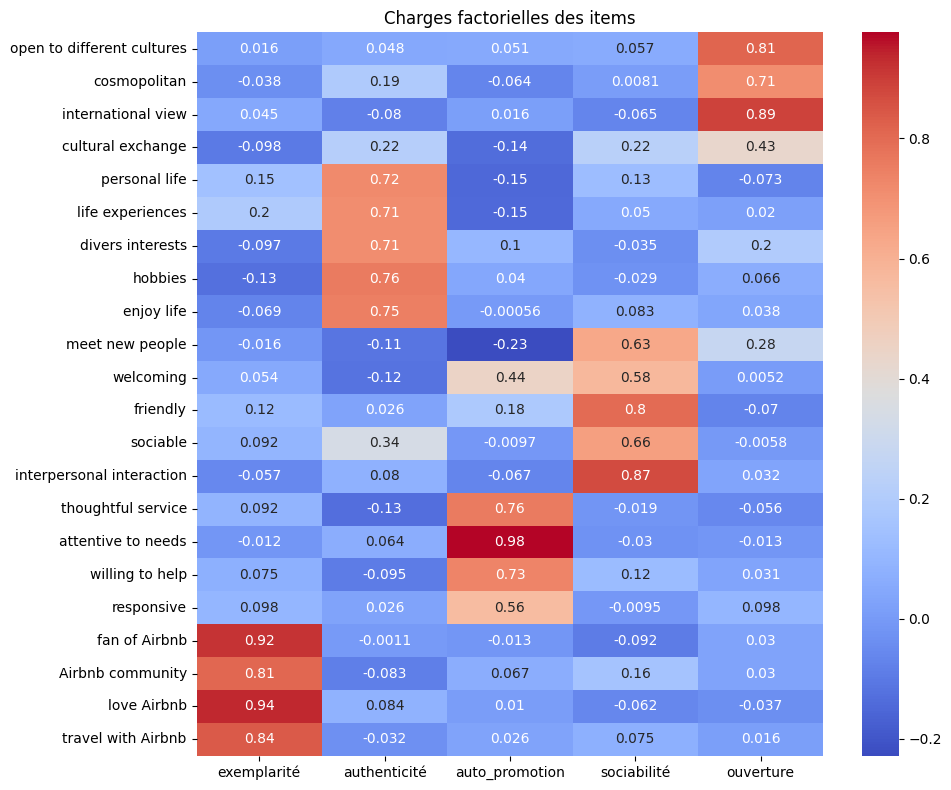

✅ [SAVE] heatmap of items saved to ..\output_fa_paris\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6337813802147857
[INFO] mean UNIQ : 0.3662186197852144

[WARNING] 2/22 low communality items (< 0.5):
cultural exchange;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_paris\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26659, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,0.500502,-0.155740
authenticité,0.762084,-0.237112
sociabilité,0.649953,0.420401
auto_promotion,-0.162250,0.773717
exemplarité,0.145026,0.580141


✅[SAVE] scores df saved to ..\output_fa_paris\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


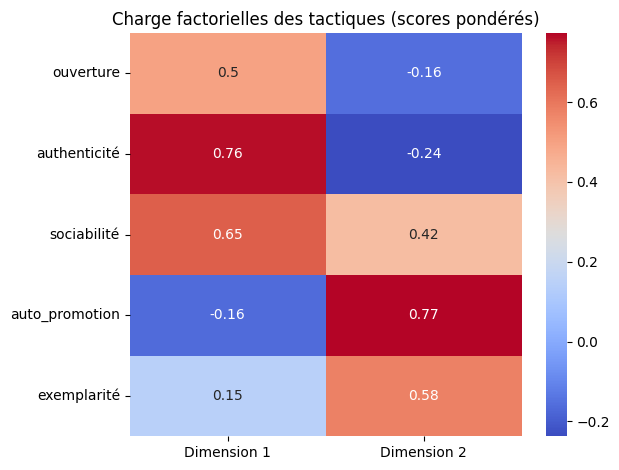

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_paris\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.937983,-0.718933,0.456366,0.429782,-0.656082
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.661481,0.129416,1.020174,1.323667,0.403382
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.092785,-0.678477,-1.769704,-1.527649,-0.761794
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.979259,1.226686,0.657466,-1.618696,-0.695859


[INFO] scores shape (len(data), 1/2*n_factors) :(26659, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26659, 26659, 26659
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_paris\listings_paris2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.843758
1,authenticité,0.878117
2,sociabilité,0.858820
3,auto_promotion,0.862768
4,exemplarité,0.934563


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_paris\cronbachs_alpha.csv!



In [ ]:
## 31/01/26
importlib.reload(fa)
from utils.fa import run_fa

INPUT_FOLDER_DATA=Path("../data_processed_paris")
path_df_items=INPUT_FOLDER_DATA/"listings_paris2406_bge_items.csv"

OUTPUT_FOLDER=Path("../output_fa_paris")
OUTPUT_FOLDER_DATA=Path("../data_processed_paris")


run_fa(path_df_items=path_df_items, items=LABELS_EN, 
       output_folder=OUTPUT_FOLDER,
        output_folder_data=OUTPUT_FOLDER_DATA,
        n_factors=5, rotation="oblimin",
        fa_names=["exemplarité","authenticité", "auto_promotion","sociabilité","ouverture"],#check order!!
        dict_factor_items=DICT_FACTOR_ITEMS,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4)



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:38: DtypeWarning: Columns (77,79) have mixed types. Specify dtype option on import or set low_memory=False.
  df=pd.read_csv(path_df_items)


[INFO] df_items : 62738 rows!
[INFO] all output saved to '..\output_fa_paris'!
df with fa scores saved to '..\data_processed_paris' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26659

[INFO] kmo_model score (> 0.7) :0.8708486940515002

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


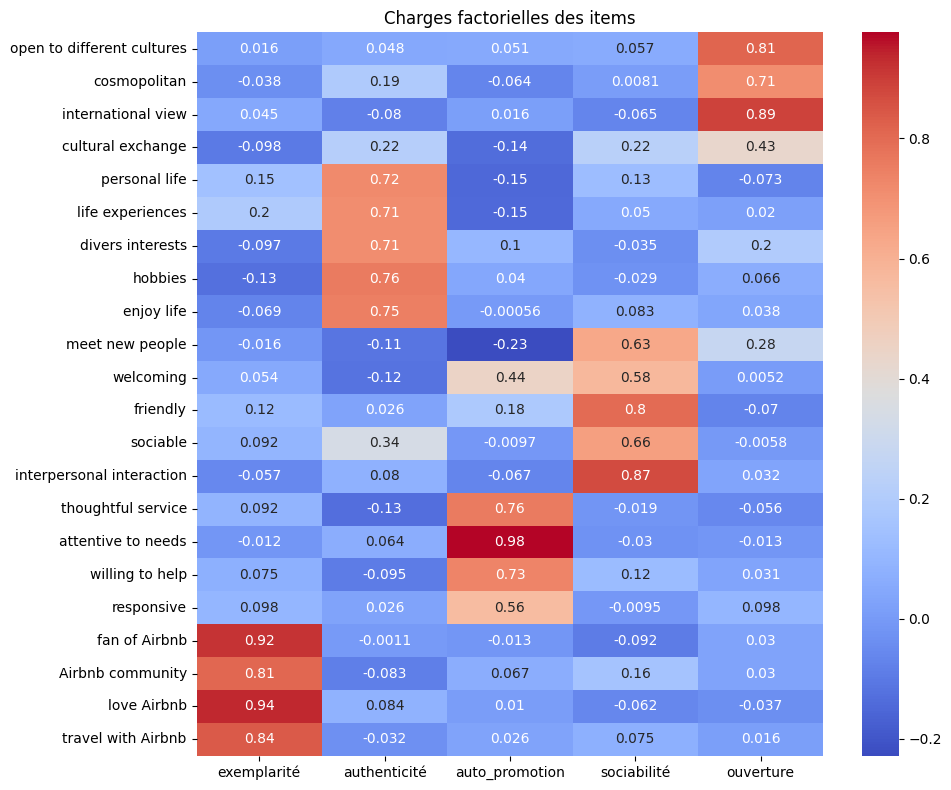

✅ [SAVE] heatmap of items saved to ..\output_fa_paris\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6337813802147857
[INFO] mean UNIQ : 0.3662186197852144

[WARNING] 2/22 low communality items (< 0.5):
cultural exchange;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_paris\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26659, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,0.500502,-0.155740
authenticité,0.762084,-0.237112
sociabilité,0.649953,0.420401
auto_promotion,-0.162250,0.773717
exemplarité,0.145026,0.580141


✅[SAVE] scores df saved to ..\output_fa_paris\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_paris\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


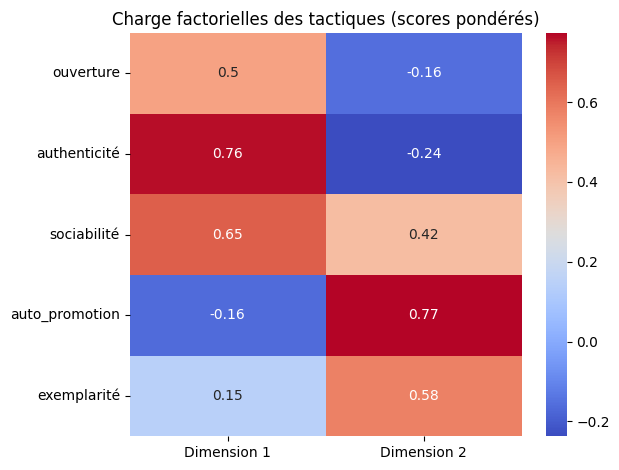

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_paris\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,3109,https://www.airbnb.com/rooms/3109,20240610195007,2024-06-12,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,80301,https://www.airbnb.com/rooms/80301,20240610195007,2024-06-13,city scrape,toits de Paris,"On the top,sharing my space,you have your bedr...","SAFE neighborhood,late bus and subway,velibe(b...",https://a0.muscache.com/pictures/742354/2e66b9...,433758,...,0.414743,0.020158,0.004774,0.002003,0.003969,0.937983,-0.718933,0.456366,0.429782,-0.656082
2,5396,https://www.airbnb.com/rooms/5396,20240610195007,2024-06-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,0.973139,0.285223,0.747109,0.138229,0.311270,0.661481,0.129416,1.020174,1.323667,0.403382
3,7397,https://www.airbnb.com/rooms/7397,20240610195007,2024-06-13,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,0.379953,0.000320,0.000885,0.000308,0.001216,-1.092785,-0.678477,-1.769704,-1.527649,-0.761794
4,80327,https://www.airbnb.com/rooms/80327,20240610195007,2024-06-12,city scrape,PETIT APPARTEMENT PARIS 18,NaN,NaN,https://a0.muscache.com/pictures/67eca081-2478...,228508,...,0.332744,0.007621,0.024031,0.009003,0.022716,0.979259,1.226686,0.657466,-1.618696,-0.695859


[INFO] scores shape (len(data), 1/2*n_factors) :(26659, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26659, 26659, 26659
len(DF)==len(listings_tactics):62738,62738

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_paris\listings_paris2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.843758
1,authenticité,0.878117
2,sociabilité,0.858820
3,auto_promotion,0.862768
4,exemplarité,0.934563


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_paris\cronbachs_alpha.csv!



In [ ]:
# importlib.reload(fa)
# from utils.fa import run_fa

# INPUT_FOLDER_DATA=Path("../data_processed_paris")
# path_df_items=INPUT_FOLDER_DATA/"listings_paris2406_bge_items.csv"

# OUTPUT_FOLDER=Path("../output_fa_paris")
# OUTPUT_FOLDER_DATA=Path("../data_processed_paris")


# run_fa(path_df_items=path_df_items, items=LABELS_EN, 
#        output_folder=OUTPUT_FOLDER,
#         output_folder_data=OUTPUT_FOLDER_DATA,
#         n_factors=5, rotation="oblimin",
#         fa_names=["exemplarité","authenticité", "auto_promotion","sociabilité","ouverture"],#check order!!
#         dict_factor_items=DICT_FACTOR_ITEMS,
#         get_items_heatmap=True,
#         get_items_table=True, low_comm_t=0.5,
#         get_factor_scores_by='weighted',
#         run_fa_on_scores="weighted",
#         get_scores_heatmap=True,
#         get_cronbachs_a=True,
#         get_barplot=False, get_pca3d=False, 
#         ndigits=4)

[INFO] df_items : 49856 rows!
[INFO] all output saved to '..\output_fa_london'!
df with fa scores saved to '..\data_processed_london' !
[CHECK] INITIALISE DF, or MERGE fa scores will go WRONG!!!
============================RUN FA=================================
[INFO] len scores in df notna:26046

[INFO] kmo_model score (> 0.7) :0.8731309199725604

[INFO] oblimin allows cross-loadings!

---------------------------heatmap of items-------------------------------
[INFO] good loadings > 0.5
Rename loadings df with fa_names in proper order !


d:\miniconda3\envs\airbnb_env\lib\site-packages\factor_analyzer\utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(
d:\miniconda3\envs\airbnb_env\lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


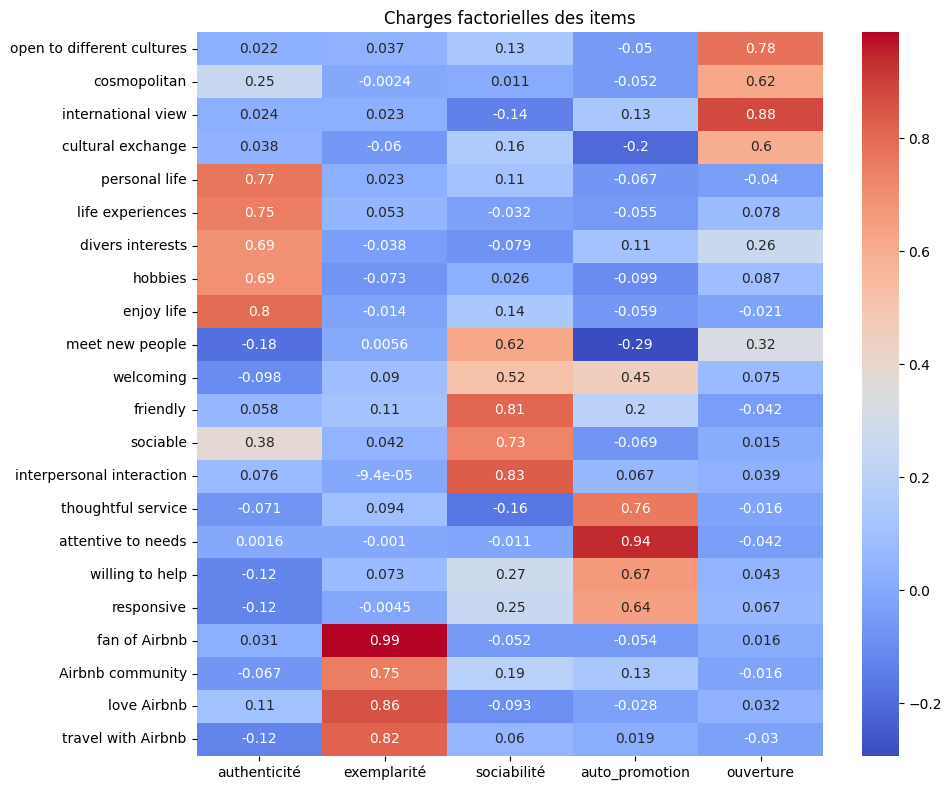

✅ [SAVE] heatmap of items saved to ..\output_fa_london\heatmap_fa_items.jpeg!

----------------------------organise input FA_ITEMS_DICT as latex table-----------------------------


,Tactique,items
0,ouverture,"open to different cultures, cosmopolitan, inte..."
1,authenticité,"personal life, life experiences, divers intere..."
2,sociabilité,"meet new people, welcoming, friendly, sociable..."
3,auto_promotion,"thoughtful service, attentive to needs, willin..."
4,exemplarité,"fan of Airbnb, Airbnb community, love Airbnb, ..."


☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\fa_items_table.tex!

# ------------------------------------tab items fa------------------------------------
[INFO] mean COMM (> 0.6):0.6384694618159338
[INFO] mean UNIQ : 0.36153053818406616

[WARNING] 4/22 low communality items (< 0.5):
cosmopolitan;cultural exchange;welcoming;responsive

✅ [SAVE] items fa CSV saved to ..\output_fa_london\items_fa.csv!

☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\items_fa.tex!

[CHECK] remember to RENAME factors by heatmap of zsc data!!!
=======================================get fa scores(tactics)=======================================
WEIGHTED ORDER:['ouverture', 'authenticité', 'sociabilité', 'auto_promotion', 'exemplarité']
[INFO] shape df scores = 5*len(get_factor_scores_by):(26046, 5)
---------------------------------run fa on scores(must do)--------------------------------------


d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fa.loc[:, factor_cols] = '-'
d:\Edu\SelfPresentation_Multimodal_airbnb\utils\fa.py:157: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '-' has dtype incompatible with float64, please 

,Dimension 1,Dimension 2
ouverture,-0.015294,0.620661
authenticité,-0.323603,0.677448
sociabilité,0.412188,0.582296
auto_promotion,0.848336,-0.102735
exemplarité,0.496891,0.209042


✅[SAVE] scores df saved to ..\output_fa_london\scores_fa.csv!
☑️[SAVE] Table saved as LaTeX to ..\output_fa_london\latex\scores_weighted_fa.tex!



d:\Edu\SelfPresentation_Multimodal_airbnb\utils\io.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(wrap_cell)


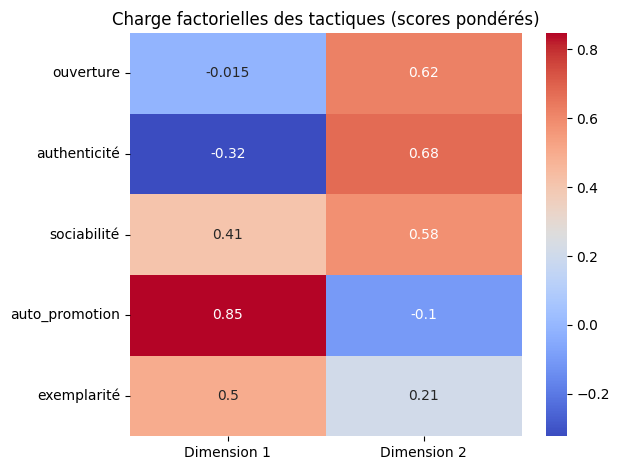

✅ [SAVE] heatmap of pondérés scores saved to ..\output_fa_london\heatmap_fa_scores_weighted.jpg!

----------------------------merge data to listings(keeping nan)---------------------------------


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,responsive,fan of Airbnb,Airbnb community,love Airbnb,travel with Airbnb,ouverture,authenticité,sociabilité,auto_promotion,exemplarité
0,1126718007114818431,https://www.airbnb.com/rooms/1126718007114818431,20240614004129,2024-06-14,city scrape,Cozy house in Northolt,Located 1 minute away from a bus stop and 10 m...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,380326752,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,702589406864297985,https://www.airbnb.com/rooms/702589406864297985,20240614004129,2024-06-15,city scrape,Up in the sky in London!,"One bedroom with double bed, desk and with th...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,77760754,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,904867371314200140,https://www.airbnb.com/rooms/904867371314200140,20240614004129,2024-06-14,city scrape,"Free Parking: Luxury, Comfy, Near Airport, Net...",Delight in elegance near Heathrow. Sink into t...,Located near Heathrow Airport and West Drayton...,https://a0.muscache.com/pictures/miso/Hosting-...,517837625,...,0.596389,0.166201,0.805479,0.173218,0.350394,-0.829890,-0.555946,-0.646149,0.815285,0.232179
3,809481748064671711,https://www.airbnb.com/rooms/809481748064671711,20240614004129,2024-06-15,city scrape,4 min walk from the station 1 bedroom apartment,This indipendent apartment has a style. Well ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,30949469,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5570655,https://www.airbnb.com/rooms/5570655,20240614004129,2024-06-15,city scrape,Fulham Garden Flat,Well decorated sunny garden flat in Fulham Par...,"Lovely, safe and quiet residential area with s...",https://a0.muscache.com/pictures/263d22a3-748e...,28880140,...,0.351617,0.002314,0.019909,0.007475,0.001919,0.021314,1.374000,-0.496466,-1.298396,-0.663074


[INFO] scores shape (len(data), 1/2*n_factors) :(26046, 5)
len(df_dropna) should == len(df_scores)==len(df_tactics): 26046, 26046, 26046
len(DF)==len(listings_tactics):49856,49856

✅ [SAVE] listings with tactics scores by 'weighted'way saved to ..\data_processed_london\listings_london2406_bge_scores.csv!!

###====================================CHECK=======================================###
---------------------------cronbach's alpha-------------------------------
[INFO] good alpha > 0.7

Cronbach's alpha checks internal consistency, whether items mesure a lantent construct !



,tactique,cronbach_alpha
0,ouverture,0.848751
1,authenticité,0.894501
2,sociabilité,0.865854
3,auto_promotion,0.873659
4,exemplarité,0.910428


✅ [SAVE] cronbach's alpha on items saved to ..\output_fa_london\cronbachs_alpha.csv!



In [6]:
importlib.reload(fa)
from utils.fa import run_fa
path_df_items="../data_processed_london/listings_london2406_bge_items.csv"

OUTPUT_FOLDER=Path("../output_fa_london")
OUTPUT_FOLDER_DATA=Path("../data_processed_london")


run_fa(path_df_items=path_df_items, items=LABELS_EN, 
       output_folder=OUTPUT_FOLDER,
        output_folder_data=OUTPUT_FOLDER_DATA,
        n_factors=5, rotation="oblimin", 
        fa_names=["authenticité", "exemplarité", "sociabilité","auto_promotion","ouverture"],
        dict_factor_items=DICT_FACTOR_ITEMS,
        get_items_heatmap=True,
        get_items_table=True, low_comm_t=0.5,
        get_factor_scores_by='weighted',
        run_fa_on_scores="weighted",
        get_scores_heatmap=True,
        get_cronbachs_a=True,
        get_barplot=False, get_pca3d=False, 
        ndigits=4)